In [2]:
# ============================================================
# 5-FOLD VIDEO DATA PIPELINE
# LEAKAGE-SAFE + STRATIFIED VERSION
#
# VIOLENCE DETECTION DATASET
#
# Expected dataset structure:
#
# violence-detection-dataset/
# ├── Violence/
# │   ├── cam1/
# │   └── cam2/
# └── NonViolence/
#     ├── cam1/
#     └── cam2/
#
# Output:
#   violence-detectionFrames/train_fold_1.csv
#   violence-detectionFrames/val_fold_1.csv
#   ...
#
# CSV columns:
#   frame
#   class
#   video_id
#   video_path
#   camera
#
# Classes:
#   Violence
#   NonViolence
# ============================================================


# ============================================================
# Imports
# ============================================================

import cv2
import shutil
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold


# ============================================================
# Paths and Parameters
# ============================================================

dataset_root = Path("violence-detection-dataset")
frames_root = Path("violence-detectionFrames")

extracted_frames_root = frames_root / "extracted_frames"

classes = ["Violence", "NonViolence"]
camera_folders = ["cam1", "cam2"]

K = 5
RANDOM_STATE = 42

VIDEO_EXTENSIONS = {
    ".mp4",
    ".avi",
    ".mov",
    ".mkv",
    ".wmv",
    ".flv",
    ".mpeg",
    ".mpg",
    ".m4v",
    ".webm",
}

CLEAR_EXTRACTED_FRAMES = False
SKIP_EXISTING_FRAMES = True

SAVE_FRAME_EXTENSION = ".jpg"
JPEG_QUALITY = 95


# ============================================================
# Create folders
# ============================================================

frames_root.mkdir(exist_ok=True, parents=True)

if CLEAR_EXTRACTED_FRAMES and extracted_frames_root.exists():
    print(f"Removing old extracted frames: {extracted_frames_root}")
    shutil.rmtree(extracted_frames_root)

extracted_frames_root.mkdir(exist_ok=True, parents=True)


# ============================================================
# Utility functions
# ============================================================

def safe_name(name):
    name = str(name)

    bad_chars = ['/', '\\', ':', '*', '?', '"', '<', '>', '|', " "]

    for ch in bad_chars:
        name = name.replace(ch, "_")

    while "__" in name:
        name = name.replace("__", "_")

    return name.strip("_")


def make_video_id(class_name, camera_name, video_path):
    """
    Example:
        class_name  = Violence
        camera_name = cam1
        video       = abc.mp4

    video_id:
        cam1__abc

    This prevents duplicate IDs between cam1 and cam2.
    """

    video_stem = safe_name(video_path.stem)
    camera_name = safe_name(camera_name)

    return f"{camera_name}__{video_stem}"


def extract_frame_index(frame_path):
    stem = Path(str(frame_path)).stem

    if "_frame" in stem:
        try:
            return int(stem.split("_frame")[-1])
        except Exception:
            pass

    digits = "".join([c for c in stem if c.isdigit()])

    if digits:
        return int(digits)

    return -1


def sort_frame_files(frame_files):
    return sorted(frame_files, key=lambda x: extract_frame_index(x))


def extract_frames(video_path, save_dir):
    save_dir.mkdir(parents=True, exist_ok=True)

    existing_frames = list(save_dir.glob(f"*{SAVE_FRAME_EXTENSION}"))

    if SKIP_EXISTING_FRAMES and len(existing_frames) > 0:
        return len(existing_frames)

    if len(existing_frames) > 0:
        for f in existing_frames:
            f.unlink()

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        print(f"Warning: could not open video: {video_path}")
        return 0

    frame_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_filename = (
            save_dir /
            f"{safe_name(video_path.stem)}_frame{frame_count:06d}{SAVE_FRAME_EXTENSION}"
        )

        if SAVE_FRAME_EXTENSION.lower() in [".jpg", ".jpeg"]:
            cv2.imwrite(
                str(frame_filename),
                frame,
                [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY]
            )
        else:
            cv2.imwrite(str(frame_filename), frame)

        frame_count += 1

    cap.release()

    return frame_count


# ============================================================
# Step 1: Collect all videos from Violence/cam1, Violence/cam2,
#         NonViolence/cam1, NonViolence/cam2
# ============================================================

all_items = []
used_ids = set()

print("=" * 100)
print("COLLECTING VIDEOS")
print("=" * 100)

for class_name in classes:
    class_folder = dataset_root / class_name

    if not class_folder.exists():
        raise ValueError(f"Class folder not found: {class_folder}")

    print(f"\nClass: {class_name}")

    for camera_name in camera_folders:
        camera_folder = class_folder / camera_name

        if not camera_folder.exists():
            raise ValueError(f"Camera folder not found: {camera_folder}")

        video_files = []

        for p in camera_folder.rglob("*"):
            if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS:
                video_files.append(p)

        video_files = sorted(video_files)

        print(f"  {camera_name}: {len(video_files)} videos")

        for video_path in video_files:
            video_id = make_video_id(
                class_name=class_name,
                camera_name=camera_name,
                video_path=video_path
            )

            unique_key = f"{class_name}::{video_id}"

            if unique_key in used_ids:
                raise RuntimeError(
                    f"Duplicate video_id detected:\n"
                    f"Class    : {class_name}\n"
                    f"Camera   : {camera_name}\n"
                    f"Video ID : {video_id}\n"
                    f"Path     : {video_path}\n"
                    f"Rename one of the duplicate videos."
                )

            used_ids.add(unique_key)

            frame_dir = extracted_frames_root / class_name / video_id

            all_items.append({
                "video_path": video_path,
                "class": class_name,
                "camera": camera_name,
                "video_id": video_id,
                "frame_dir": frame_dir,
            })

print("\nTotal videos found:", len(all_items))

if len(all_items) == 0:
    raise RuntimeError("No videos found. Check dataset_root, class folders, and cam folders.")

labels = [item["class"] for item in all_items]

print("\nClass distribution:")
print(pd.Series(labels).value_counts())

print("\nCamera distribution:")
items_df = pd.DataFrame(all_items)
print(items_df.groupby(["class", "camera"]).size())


# ============================================================
# Step 2: Extract frames from all videos
# ============================================================

print("\n" + "=" * 100)
print("EXTRACTING FRAMES")
print("=" * 100)

frame_summary_rows = []

for item in tqdm(all_items, desc="Extracting frames"):
    video_path = item["video_path"]
    frame_dir = item["frame_dir"]

    n_frames = extract_frames(
        video_path=video_path,
        save_dir=frame_dir
    )

    frame_summary_rows.append({
        "class": item["class"],
        "camera": item["camera"],
        "video_id": item["video_id"],
        "video_path": str(video_path),
        "frame_dir": str(frame_dir),
        "num_frames": n_frames,
    })

frame_summary_df = pd.DataFrame(frame_summary_rows)

frame_summary_csv = frames_root / "all_videos_frame_extraction_summary.csv"
frame_summary_df.to_csv(frame_summary_csv, index=False)

print("\nFrame extraction summary saved:")
print(frame_summary_csv)

print("\nFrame count statistics:")
print(frame_summary_df["num_frames"].describe())

empty_videos = frame_summary_df[frame_summary_df["num_frames"] == 0]

if len(empty_videos) > 0:
    print("\nWarning: some videos have 0 extracted frames:")
    print(empty_videos[["class", "camera", "video_id", "video_path"]].head(20))


# ============================================================
# Step 3: Stratified K-Fold splitting
# ============================================================

class_counts = pd.Series(labels).value_counts()

if class_counts.min() < K:
    raise ValueError(
        f"Not enough videos per class for {K}-fold split.\n"
        f"Class counts:\n{class_counts}"
    )

skf = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# Step 4: CSV creation
# ============================================================

def create_csv_leak_safe(item_list, csv_path):
    rows = []

    for item in item_list:
        frame_dir = item["frame_dir"]

        frame_files = sort_frame_files(
            list(frame_dir.glob(f"*{SAVE_FRAME_EXTENSION}"))
        )

        for frame_file in frame_files:
            rows.append({
                "frame": str(frame_file),
                "class": item["class"],
                "video_id": item["video_id"],
                "video_path": str(item["video_path"]),
                "camera": item["camera"],
            })

    df = pd.DataFrame(
        rows,
        columns=[
            "frame",
            "class",
            "video_id",
            "video_path",
            "camera",
        ]
    )

    df.to_csv(csv_path, index=False)

    return df


fold_summary_rows = []

print("\n" + "=" * 100)
print("CREATING STRATIFIED 5-FOLD CSV FILES")
print("=" * 100)

for fold_idx, (train_indices, val_indices) in enumerate(
    skf.split(all_items, labels),
    1
):
    print("\n" + "-" * 100)
    print(f"Processing Fold {fold_idx}")
    print("-" * 100)

    train_items = [all_items[i] for i in train_indices]
    val_items = [all_items[i] for i in val_indices]

    train_labels = [item["class"] for item in train_items]
    val_labels = [item["class"] for item in val_items]

    train_video_ids = set([
        f"{item['class']}::{item['video_id']}"
        for item in train_items
    ])

    val_video_ids = set([
        f"{item['class']}::{item['video_id']}"
        for item in val_items
    ])

    overlap = train_video_ids.intersection(val_video_ids)

    print(f"Train videos: {len(train_video_ids)}")
    print(f"Val videos  : {len(val_video_ids)}")
    print(f"Overlap     : {len(overlap)}")

    if len(overlap) > 0:
        raise RuntimeError(f"Leakage detected in Fold {fold_idx}: {overlap}")

    print("\nTrain class distribution:")
    print(pd.Series(train_labels).value_counts())

    print("\nVal class distribution:")
    print(pd.Series(val_labels).value_counts())

    print("\nTrain camera distribution:")
    print(pd.DataFrame(train_items).groupby(["class", "camera"]).size())

    print("\nVal camera distribution:")
    print(pd.DataFrame(val_items).groupby(["class", "camera"]).size())

    train_csv = frames_root / f"train_fold_{fold_idx}.csv"
    val_csv = frames_root / f"val_fold_{fold_idx}.csv"

    train_df = create_csv_leak_safe(train_items, train_csv)
    val_df = create_csv_leak_safe(val_items, val_csv)

    train_video_count_by_class = pd.Series(train_labels).value_counts().to_dict()
    val_video_count_by_class = pd.Series(val_labels).value_counts().to_dict()

    train_frame_count_by_class = train_df["class"].value_counts().to_dict()
    val_frame_count_by_class = val_df["class"].value_counts().to_dict()

    train_camera_count = pd.DataFrame(train_items).groupby(["class", "camera"]).size().to_dict()
    val_camera_count = pd.DataFrame(val_items).groupby(["class", "camera"]).size().to_dict()

    fold_summary_rows.append({
        "fold": fold_idx,

        "train_videos": len(train_items),
        "val_videos": len(val_items),
        "overlap": len(overlap),

        "train_rows_frames": len(train_df),
        "val_rows_frames": len(val_df),

        "train_Violence_videos": train_video_count_by_class.get("Violence", 0),
        "train_NonViolence_videos": train_video_count_by_class.get("NonViolence", 0),
        "val_Violence_videos": val_video_count_by_class.get("Violence", 0),
        "val_NonViolence_videos": val_video_count_by_class.get("NonViolence", 0),

        "train_Violence_frames": train_frame_count_by_class.get("Violence", 0),
        "train_NonViolence_frames": train_frame_count_by_class.get("NonViolence", 0),
        "val_Violence_frames": val_frame_count_by_class.get("Violence", 0),
        "val_NonViolence_frames": val_frame_count_by_class.get("NonViolence", 0),

        "train_Violence_cam1_videos": train_camera_count.get(("Violence", "cam1"), 0),
        "train_Violence_cam2_videos": train_camera_count.get(("Violence", "cam2"), 0),
        "train_NonViolence_cam1_videos": train_camera_count.get(("NonViolence", "cam1"), 0),
        "train_NonViolence_cam2_videos": train_camera_count.get(("NonViolence", "cam2"), 0),

        "val_Violence_cam1_videos": val_camera_count.get(("Violence", "cam1"), 0),
        "val_Violence_cam2_videos": val_camera_count.get(("Violence", "cam2"), 0),
        "val_NonViolence_cam1_videos": val_camera_count.get(("NonViolence", "cam1"), 0),
        "val_NonViolence_cam2_videos": val_camera_count.get(("NonViolence", "cam2"), 0),

        "train_csv": str(train_csv),
        "val_csv": str(val_csv),
    })

    print(f"\nFold {fold_idx} CSVs saved:")
    print(f"Train CSV: {train_csv} | Rows: {len(train_df)}")
    print(f"Val CSV  : {val_csv} | Rows: {len(val_df)}")


# ============================================================
# Step 5: Save global summaries
# ============================================================

fold_summary_df = pd.DataFrame(fold_summary_rows)

fold_summary_csv = frames_root / "fold_summary.csv"
fold_summary_df.to_csv(fold_summary_csv, index=False)

video_list_df = pd.DataFrame([
    {
        "class": item["class"],
        "camera": item["camera"],
        "video_id": item["video_id"],
        "video_path": str(item["video_path"]),
        "frame_dir": str(item["frame_dir"]),
    }
    for item in all_items
])

video_list_csv = frames_root / "all_videos_list.csv"
video_list_df.to_csv(video_list_csv, index=False)


# ============================================================
# Final print
# ============================================================

print("\n" + "=" * 100)
print("STRATIFIED 5-FOLD PIPELINE COMPLETE")
print("=" * 100)

print("Dataset root:", dataset_root)
print("Frames root :", frames_root)

print("\nTotal videos:", len(all_items))

print("\nClass distribution:")
print(pd.Series(labels).value_counts())

print("\nCamera distribution:")
print(items_df.groupby(["class", "camera"]).size())

print("\nSaved files:")
print("Video list CSV        :", video_list_csv)
print("Frame summary CSV     :", frame_summary_csv)
print("Fold summary CSV      :", fold_summary_csv)

for fold_idx in range(1, K + 1):
    print(f"Train fold {fold_idx} CSV:", frames_root / f"train_fold_{fold_idx}.csv")
    print(f"Val fold {fold_idx} CSV  :", frames_root / f"val_fold_{fold_idx}.csv")

print("=" * 100)

COLLECTING VIDEOS

Class: Violence
  cam1: 115 videos
  cam2: 115 videos

Class: NonViolence
  cam1: 60 videos
  cam2: 60 videos

Total videos found: 350

Class distribution:
Violence       230
NonViolence    120
Name: count, dtype: int64

Camera distribution:
class        camera
NonViolence  cam1       60
             cam2       60
Violence     cam1      115
             cam2      115
dtype: int64

EXTRACTING FRAMES


Extracting frames: 100%|█████████████████████████████████████████████████████████████| 350/350 [33:09<00:00,  5.68s/it]



Frame extraction summary saved:
violence-detectionFrames\all_videos_frame_extraction_summary.csv

Frame count statistics:
count    350.000000
mean     168.968571
std       57.315261
min       74.000000
25%      128.000000
50%      159.000000
75%      192.000000
max      434.000000
Name: num_frames, dtype: float64

CREATING STRATIFIED 5-FOLD CSV FILES

----------------------------------------------------------------------------------------------------
Processing Fold 1
----------------------------------------------------------------------------------------------------
Train videos: 280
Val videos  : 70
Overlap     : 0

Train class distribution:
Violence       184
NonViolence     96
Name: count, dtype: int64

Val class distribution:
Violence       46
NonViolence    24
Name: count, dtype: int64

Train camera distribution:
class        camera
NonViolence  cam1      50
             cam2      46
Violence     cam1      92
             cam2      92
dtype: int64

Val camera distribution:
class

In [3]:
# ============================================================
# CLEAN SINGLE-MODE PROPOSED KEYFRAME EXTRACTION PIPELINE
# VIOLENCE-DETECTION DATASET
#
# Final available modes:
#   1) PROPOSED_FUSED
#   2) PROPOSED_SPATIAL_ONLY
#   3) PROPOSED_TEMPORAL_ONLY
#
# Designed for this frame structure:
#
# violence-detectionFrames/
# Input CSV columns:
#   frame or frame_path
#   class
#   video_id or video_name
#
# Output:
#   violence-detectionNumpy/{SELECTED_MODE}/fold_i/{split}/{class}/{video_id}.npy
#
# Saved NPY shape:
#   [T_selected, 224, 224, 3]
#
# Classes:
#   Violence
#   NonViolence
#
# Notes:
#   - This is NOT uniform stride.
#   - Proposed modes use train-only Otsu threshold.
#   - Score cache is used for faster reruns.
#   - Saved frames are BGR because OpenCV is used.
# ============================================================


# ============================================================
# Imports
# ============================================================

import os
import cv2
import json
import time
import shutil
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm
from skimage.filters import threshold_otsu
from concurrent.futures import ThreadPoolExecutor, as_completed


# ============================================================
# Basic setup
# ============================================================

try:
    cv2.setNumThreads(1)
except Exception:
    pass


# ============================================================
# User settings
# ============================================================

FRAMES_ROOT = Path("violence-detectionFrames")
EXTRACTED_FRAMES_ROOT = FRAMES_ROOT / "extracted_frames"

NPY_ROOT = Path("violence-detectionNumpy")
KEYFRAME_ROOT = Path("violence-detectionKeyFrames")
SCORE_CACHE_ROOT = Path("violence-detectionScoreCache")

CLASSES = ["Violence", "NonViolence"]
RUN_FOLDS = [1, 2, 3, 4, 5]


# ============================================================
# Select exactly one proposed mode
# ============================================================

SELECTED_MODE = "PROPOSED_FUSED"

# SELECTED_MODE = "PROPOSED_FUSED"
# SELECTED_MODE = "PROPOSED_SPATIAL_ONLY"
# SELECTED_MODE = "PROPOSED_TEMPORAL_ONLY"


# ============================================================
# Scoring settings
# ============================================================

SCORE_IMG_SIZE = 224
SCORE_SIGNATURE = f"violence_detection_score_sz{SCORE_IMG_SIZE}_v1"
EPS = 1e-8


# ============================================================
# Clean-run settings
# ============================================================

USE_SCORE_CACHE = True
REBUILD_SCORE_CACHE = True
CLEAR_SCORE_CACHE = True

CLEAR_OUTPUT = True
SKIP_EXISTING_NPY = False


# ============================================================
# Speed settings
# ============================================================

MAX_SCORE_WORKERS = min(8, max(1, (os.cpu_count() or 4) - 1))


# ============================================================
# NPY saving settings
# ============================================================

SAVE_NPY_ARRAYS = True
SAVE_KEYFRAME_IMAGES = False

RESIZE_BEFORE_SAVING_NPY = True
NPY_SAVE_SIZE = 224
SAVE_FRAMES_AS_UINT8 = True

KEEP_FIRST_LAST_IN_PROPOSED = True


# ============================================================
# Mode definitions
# ============================================================

PROPOSED_FUSED = "PROPOSED_FUSED"
PROPOSED_SPATIAL_ONLY = "PROPOSED_SPATIAL_ONLY"
PROPOSED_TEMPORAL_ONLY = "PROPOSED_TEMPORAL_ONLY"

PROPOSED_MODES = [
    PROPOSED_FUSED,
    PROPOSED_SPATIAL_ONLY,
    PROPOSED_TEMPORAL_ONLY,
]

if SELECTED_MODE not in PROPOSED_MODES:
    raise ValueError(
        f"Invalid SELECTED_MODE: {SELECTED_MODE}\n"
        f"Available proposed modes: {PROPOSED_MODES}"
    )

OUTPUT_MODE = SELECTED_MODE


# ============================================================
# Create folders
# ============================================================

NPY_ROOT.mkdir(parents=True, exist_ok=True)
KEYFRAME_ROOT.mkdir(parents=True, exist_ok=True)
SCORE_CACHE_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# Clean old output/cache
# ============================================================

mode_npy_root = NPY_ROOT / OUTPUT_MODE
mode_key_root = KEYFRAME_ROOT / OUTPUT_MODE
score_cache_dir = SCORE_CACHE_ROOT / SCORE_SIGNATURE

if CLEAR_OUTPUT:
    if mode_npy_root.exists():
        print(f"Removing old NPY output: {mode_npy_root}")
        shutil.rmtree(mode_npy_root)

    if mode_key_root.exists():
        print(f"Removing old keyframe output: {mode_key_root}")
        shutil.rmtree(mode_key_root)

if CLEAR_SCORE_CACHE:
    if score_cache_dir.exists():
        print(f"Removing old score cache: {score_cache_dir}")
        shutil.rmtree(score_cache_dir)

mode_npy_root.mkdir(parents=True, exist_ok=True)
mode_key_root.mkdir(parents=True, exist_ok=True)


# ============================================================
# Print config
# ============================================================

print("=" * 110)
print("SINGLE-MODE PROPOSED KEYFRAME EXTRACTION - VIOLENCE-DETECTION")
print("=" * 110)

print("Selected mode         :", SELECTED_MODE)
print("Output mode           :", OUTPUT_MODE)

print("\nPaths:")
print("Frames root           :", FRAMES_ROOT)
print("Extracted frames root :", EXTRACTED_FRAMES_ROOT)
print("NPY root              :", NPY_ROOT)
print("Output folder         :", NPY_ROOT / OUTPUT_MODE)
print("Score cache root      :", SCORE_CACHE_ROOT)

print("\nScoring:")
print("Score image size      :", SCORE_IMG_SIZE)
print("Score signature       :", SCORE_SIGNATURE)

print("\nClean run:")
print("Clear output          :", CLEAR_OUTPUT)
print("Clear score cache     :", CLEAR_SCORE_CACHE)
print("Rebuild score cache   :", REBUILD_SCORE_CACHE)
print("Skip existing NPY     :", SKIP_EXISTING_NPY)

print("\nSpeed:")
print("Workers               :", MAX_SCORE_WORKERS)

print("\nSaving:")
print("NPY save size         :", NPY_SAVE_SIZE)
print("Save as uint8         :", SAVE_FRAMES_AS_UINT8)
print("Keep first/last       :", KEEP_FIRST_LAST_IN_PROPOSED)

print("=" * 110)


# ============================================================
# Utility functions
# ============================================================

def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def safe_name(name):
    name = str(name)
    bad_chars = ['/', '\\', ':', '*', '?', '"', '<', '>', '|']

    for ch in bad_chars:
        name = name.replace(ch, "_")

    return name


def get_frame_col(df):
    if "frame" in df.columns:
        return "frame"

    if "frame_path" in df.columns:
        return "frame_path"

    raise ValueError("CSV must contain 'frame' or 'frame_path' column.")


def get_video_col(df):
    if "video_id" in df.columns:
        return "video_id"

    if "video_name" in df.columns:
        return "video_name"

    return None


def extract_frame_index(path):
    stem = Path(str(path)).stem

    if "_frame" in stem:
        try:
            return int(stem.split("_frame")[-1])
        except Exception:
            pass

    digits = "".join([c for c in stem if c.isdigit()])

    if digits:
        return int(digits)

    return -1


def sort_frame_paths(frame_paths):
    return sorted(frame_paths, key=lambda x: extract_frame_index(x))


def resolve_frame_path(path, cls=None, video_id=None):
    """
    Handles these cases:

    1) CSV contains full path:
       violence-detectionFrames/extracted_frames/Violence/cam1__1/xxx.jpg

    2) CSV contains relative path:
       extracted_frames/Violence/cam1__1/xxx.jpg

    3) CSV contains only filename:
       xxx.jpg

       Then this function rebuilds:
       violence-detectionFrames/extracted_frames/{class}/{video_id}/xxx.jpg
    """

    raw_path = Path(str(path))

    if raw_path.exists():
        return raw_path

    alt1 = FRAMES_ROOT / raw_path

    if alt1.exists():
        return alt1

    if cls is not None and video_id is not None:
        alt2 = EXTRACTED_FRAMES_ROOT / str(cls) / str(video_id) / raw_path.name

        if alt2.exists():
            return alt2

    return raw_path


def make_class_aware_video_set(df):
    frame_col = get_frame_col(df)
    video_col = get_video_col(df)

    df = df.copy()

    if video_col is None:
        df["video_id_auto"] = df[frame_col].apply(lambda x: Path(str(x)).parent.name)
        video_col = "video_id_auto"

    ids = set()
    temp = df[["class", video_col]].drop_duplicates()

    for _, row in temp.iterrows():
        ids.add(f"{row['class']}::{row[video_col]}")

    return ids


def prepare_video_groups(df):
    frame_col = get_frame_col(df)
    video_col = get_video_col(df)

    df = df.copy()

    if video_col is None:
        df["video_id_auto"] = df[frame_col].apply(lambda x: Path(str(x)).parent.name)
        video_col = "video_id_auto"

    groups = []

    for cls in CLASSES:
        cls_df = df[df["class"] == cls].copy()

        for video_id, group in cls_df.groupby(video_col):
            video_id = str(video_id)

            frame_paths = group[frame_col].tolist()
            frame_paths = sort_frame_paths(frame_paths)

            if len(frame_paths) == 0:
                continue

            groups.append({
                "class": cls,
                "video_id": video_id,
                "safe_video_id": safe_name(video_id),
                "frame_paths": frame_paths,
            })

    return groups


def get_selected_extreme_info(stats_df):
    empty = {
        "min_selected_frames": np.nan,
        "max_selected_frames": np.nan,
        "avg_selected_frames": np.nan,
        "min_selected_video_id": "",
        "max_selected_video_id": "",
        "min_selected_class": "",
        "max_selected_class": "",
        "min_selected_split": "",
        "max_selected_split": "",
        "min_selected_fold": np.nan,
        "max_selected_fold": np.nan,
    }

    if stats_df is None or len(stats_df) == 0:
        return empty

    if "selected_frames" not in stats_df.columns:
        return empty

    min_idx = stats_df["selected_frames"].idxmin()
    max_idx = stats_df["selected_frames"].idxmax()

    min_row = stats_df.loc[min_idx]
    max_row = stats_df.loc[max_idx]

    return {
        "min_selected_frames": int(min_row["selected_frames"]),
        "max_selected_frames": int(max_row["selected_frames"]),
        "avg_selected_frames": float(stats_df["selected_frames"].mean()),

        "min_selected_video_id": str(min_row.get("video_id", "")),
        "max_selected_video_id": str(max_row.get("video_id", "")),

        "min_selected_class": str(min_row.get("class", "")),
        "max_selected_class": str(max_row.get("class", "")),

        "min_selected_split": str(min_row.get("split", "")),
        "max_selected_split": str(max_row.get("split", "")),

        "min_selected_fold": int(min_row.get("fold", -1)) if "fold" in min_row else np.nan,
        "max_selected_fold": int(max_row.get("fold", -1)) if "fold" in max_row else np.nan,
    }


def get_npy_shape_safe(path):
    try:
        arr = np.load(path, mmap_mode="r")
        return tuple(arr.shape), str(arr.dtype)
    except Exception:
        return (), ""


# ============================================================
# Score functions
# ============================================================

def minmax_normalize(arr):
    arr = np.asarray(arr, dtype=np.float32)

    if len(arr) == 0:
        return arr

    mn = float(np.min(arr))
    mx = float(np.max(arr))

    if mx - mn < EPS:
        return np.zeros_like(arr, dtype=np.float32)

    return (arr - mn) / (mx - mn + EPS)


def compute_spatial_components(gray):
    contrast = np.std(gray)

    edges = cv2.Canny(gray, 100, 200)
    edge_strength = edges.mean() / 255.0

    lap = cv2.Laplacian(gray, cv2.CV_64F)
    clarity = lap.var()

    return contrast, edge_strength, clarity


def temporal_motion_score(prev_gray, curr_gray):
    return np.mean(
        np.abs(
            curr_gray.astype(np.float32) - prev_gray.astype(np.float32)
        )
    )


def adaptive_fusion_score(spatial_scores, temporal_scores):
    spatial_scores = np.asarray(spatial_scores, dtype=np.float32)
    temporal_scores = np.asarray(temporal_scores, dtype=np.float32)

    ws = spatial_scores / (spatial_scores + temporal_scores + EPS)
    wt = temporal_scores / (spatial_scores + temporal_scores + EPS)

    fused = ws * spatial_scores + wt * temporal_scores

    return fused.astype(np.float32)


def compute_scores_for_video(item):
    frame_paths = sort_frame_paths(item["frame_paths"])
    cls = item["class"]
    video_id = item["video_id"]

    contrasts = []
    edges = []
    clarities = []
    motions = []

    prev_gray = None
    missing_count = 0

    for idx, fp in enumerate(frame_paths):
        src = resolve_frame_path(
            path=fp,
            cls=cls,
            video_id=video_id
        )

        gray = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE)

        if gray is None:
            contrasts.append(0.0)
            edges.append(0.0)
            clarities.append(0.0)
            motions.append(0.0)
            missing_count += 1
            continue

        gray = cv2.resize(
            gray,
            (SCORE_IMG_SIZE, SCORE_IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        c, e, cl = compute_spatial_components(gray)

        contrasts.append(c)
        edges.append(e)
        clarities.append(cl)

        if idx == 0 or prev_gray is None:
            motions.append(0.0)
        else:
            motions.append(temporal_motion_score(prev_gray, gray))

        prev_gray = gray

    contrasts = np.asarray(contrasts, dtype=np.float32)
    edges = np.asarray(edges, dtype=np.float32)
    clarities = np.asarray(clarities, dtype=np.float32)
    motions = np.asarray(motions, dtype=np.float32)

    contrast_norm = minmax_normalize(contrasts)
    edge_norm = minmax_normalize(edges)
    clarity_norm = minmax_normalize(clarities)

    spatial_score = (contrast_norm + edge_norm + clarity_norm) / 3.0
    temporal_score = minmax_normalize(motions)
    fused_score = adaptive_fusion_score(spatial_score, temporal_score)

    return {
        "contrast": contrasts,
        "edge": edges,
        "clarity": clarities,
        "raw_motion": motions,
        "spatial_score": spatial_score.astype(np.float32),
        "temporal_score": temporal_score.astype(np.float32),
        "fused_score": fused_score.astype(np.float32),
        "missing_count": int(missing_count),
    }


def get_score_vector(score_dict, mode):
    if mode == PROPOSED_FUSED:
        return score_dict["fused_score"]

    if mode == PROPOSED_SPATIAL_ONLY:
        return score_dict["spatial_score"]

    if mode == PROPOSED_TEMPORAL_ONLY:
        return score_dict["temporal_score"]

    raise ValueError(f"Unknown proposed mode: {mode}")


# ============================================================
# Score cache
# ============================================================

def collect_unique_video_groups():
    unique = {}

    for fold_idx in RUN_FOLDS:
        for split_name in ["train", "val"]:
            csv_path = FRAMES_ROOT / f"{split_name}_fold_{fold_idx}.csv"

            if not csv_path.exists():
                continue

            df = pd.read_csv(csv_path)
            groups = prepare_video_groups(df)

            for item in groups:
                key = f"{item['class']}::{item['video_id']}"
                unique[key] = item

    return list(unique.values())


def get_score_cache_path(item):
    return (
        SCORE_CACHE_ROOT /
        SCORE_SIGNATURE /
        item["class"] /
        f"{item['safe_video_id']}.npz"
    )


def save_score_cache(item, score_dict):
    path = get_score_cache_path(item)
    path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        path,
        total_frames=np.array([len(item["frame_paths"])], dtype=np.int64),
        missing_count=np.array([score_dict["missing_count"]], dtype=np.int64),

        contrast=score_dict["contrast"],
        edge=score_dict["edge"],
        clarity=score_dict["clarity"],
        raw_motion=score_dict["raw_motion"],

        spatial_score=score_dict["spatial_score"],
        temporal_score=score_dict["temporal_score"],
        fused_score=score_dict["fused_score"],
    )

    return path


def load_score_cache(item):
    path = get_score_cache_path(item)

    if not path.exists():
        raise FileNotFoundError(f"Score cache not found: {path}")

    data = np.load(path)

    cached_total = int(data["total_frames"][0])
    current_total = len(item["frame_paths"])

    if cached_total != current_total:
        raise RuntimeError(
            f"Score cache mismatch for {item['video_id']}: "
            f"cache={cached_total}, current={current_total}"
        )

    if "missing_count" in data:
        missing_count = int(data["missing_count"][0])
    else:
        missing_count = 0

    return {
        "contrast": data["contrast"].astype(np.float32),
        "edge": data["edge"].astype(np.float32),
        "clarity": data["clarity"].astype(np.float32),
        "raw_motion": data["raw_motion"].astype(np.float32),

        "spatial_score": data["spatial_score"].astype(np.float32),
        "temporal_score": data["temporal_score"].astype(np.float32),
        "fused_score": data["fused_score"].astype(np.float32),

        "missing_count": missing_count,
    }


def compute_or_load_score_cache(item):
    path = get_score_cache_path(item)

    if USE_SCORE_CACHE and path.exists() and not REBUILD_SCORE_CACHE:
        try:
            score_dict = load_score_cache(item)

            return {
                "status": "cached",
                "class": item["class"],
                "video_id": item["video_id"],
                "total_frames": len(item["frame_paths"]),
                "missing_count": score_dict.get("missing_count", 0),
                "cache_path": str(path),
                "error": "",
            }

        except Exception:
            pass

    try:
        score_dict = compute_scores_for_video(item)
        save_score_cache(item, score_dict)

        return {
            "status": "computed",
            "class": item["class"],
            "video_id": item["video_id"],
            "total_frames": len(item["frame_paths"]),
            "missing_count": score_dict.get("missing_count", 0),
            "cache_path": str(path),
            "error": "",
        }

    except Exception as e:
        return {
            "status": "failed",
            "class": item["class"],
            "video_id": item["video_id"],
            "total_frames": len(item["frame_paths"]),
            "missing_count": -1,
            "cache_path": str(path),
            "error": str(e),
        }


def ensure_score_cache():
    print("\n" + "=" * 110)
    print("GLOBAL SCORE CACHE")
    print("=" * 110)

    unique_groups = collect_unique_video_groups()

    print(f"Unique videos : {len(unique_groups):,}")
    print(f"Workers       : {MAX_SCORE_WORKERS}")
    print(f"Signature     : {SCORE_SIGNATURE}")

    rows = []
    start = time.perf_counter()

    with ThreadPoolExecutor(max_workers=MAX_SCORE_WORKERS) as executor:
        futures = [
            executor.submit(compute_or_load_score_cache, item)
            for item in unique_groups
        ]

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Score cache"
        ):
            rows.append(future.result())

    elapsed = time.perf_counter() - start

    df = pd.DataFrame(rows)

    out_dir = SCORE_CACHE_ROOT / SCORE_SIGNATURE
    out_dir.mkdir(parents=True, exist_ok=True)

    summary_path = out_dir / "score_cache_summary.csv"
    df.to_csv(summary_path, index=False)

    print("\nScore cache status:")
    print(df["status"].value_counts(dropna=False))

    if "missing_count" in df.columns:
        print("\nMissing frame count in scoring:")
        print(df["missing_count"].describe())

        total_missing = int(df["missing_count"].clip(lower=0).sum())
        print("Total missing frames while scoring:", total_missing)

        if total_missing > 0:
            print("\nExamples with missing frames:")
            print(df[df["missing_count"] > 0].head(10))

    print("Score cache time:", format_seconds(elapsed))
    print("Saved:", summary_path)

    if (df["status"] == "failed").any():
        print(df[df["status"] == "failed"].head(10))
        raise RuntimeError("Some videos failed during score cache computation.")

    print("=" * 110)

    return df


# ============================================================
# Proposed selection
# ============================================================

def select_proposed_indices(scores, threshold):
    total = len(scores)

    if total <= 0:
        return np.array([], dtype=np.int64)

    selected = np.where(scores >= threshold)[0].astype(np.int64)

    if KEEP_FIRST_LAST_IN_PROPOSED:
        selected = np.concatenate([
            np.array([0], dtype=np.int64),
            selected,
            np.array([total - 1], dtype=np.int64),
        ])

    selected = selected[(selected >= 0) & (selected < total)]
    selected = np.sort(np.unique(selected))

    return selected.astype(np.int64)


def get_selected_indices_for_mode(item, mode, threshold):
    score_dict = load_score_cache(item)
    scores = get_score_vector(score_dict, mode)

    selected_indices = select_proposed_indices(
        scores=scores,
        threshold=threshold
    )

    return selected_indices


# ============================================================
# NPY saving
# ============================================================

def read_selected_frames(item, selected_indices):
    cls = item["class"]
    video_id = item["video_id"]
    frame_paths = item["frame_paths"]

    images = []
    frame_indices = []
    frame_paths_original = []
    frame_paths_resolved = []

    missing_count = 0

    for idx in selected_indices:
        src_original = frame_paths[int(idx)]

        src = resolve_frame_path(
            path=src_original,
            cls=cls,
            video_id=video_id
        )

        img = cv2.imread(str(src), cv2.IMREAD_COLOR)

        if img is None:
            missing_count += 1
            continue

        if RESIZE_BEFORE_SAVING_NPY:
            img = cv2.resize(
                img,
                (NPY_SAVE_SIZE, NPY_SAVE_SIZE),
                interpolation=cv2.INTER_AREA
            )

        if SAVE_FRAMES_AS_UINT8:
            img = img.astype(np.uint8)
        else:
            img = img.astype(np.float32) / 255.0

        images.append(img)
        frame_indices.append(extract_frame_index(src_original))
        frame_paths_original.append(str(src_original))
        frame_paths_resolved.append(str(src))

    if len(images) > 0:
        arr = np.stack(images, axis=0)
    else:
        if SAVE_FRAMES_AS_UINT8:
            arr = np.empty((0, NPY_SAVE_SIZE, NPY_SAVE_SIZE, 3), dtype=np.uint8)
        else:
            arr = np.empty((0, NPY_SAVE_SIZE, NPY_SAVE_SIZE, 3), dtype=np.float32)

    return arr, frame_indices, frame_paths_original, frame_paths_resolved, missing_count


def save_npy_for_item(item, output_mode, fold_idx, split_name, selected_indices):
    cls = item["class"]
    safe_video_id = item["safe_video_id"]
    frame_paths = item["frame_paths"]

    out_dir = NPY_ROOT / output_mode / f"fold_{fold_idx}" / split_name / cls
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"{safe_video_id}.npy"

    if SKIP_EXISTING_NPY and out_path.exists():
        shape, dtype = get_npy_shape_safe(out_path)

        frame_indices = [
            extract_frame_index(frame_paths[int(idx)])
            for idx in selected_indices
        ]

        frame_paths_original = [
            str(frame_paths[int(idx)])
            for idx in selected_indices
        ]

        frame_paths_resolved = [
            str(resolve_frame_path(frame_paths[int(idx)], cls=cls, video_id=item["video_id"]))
            for idx in selected_indices
        ]

        return {
            "path": out_path,
            "status": "skipped_existing",
            "saved_frames": int(shape[0]) if len(shape) > 0 else 0,
            "saved_height": int(shape[1]) if len(shape) >= 3 else -1,
            "saved_width": int(shape[2]) if len(shape) >= 3 else -1,
            "frame_indices": frame_indices,
            "frame_paths_original": frame_paths_original,
            "frame_paths_resolved": frame_paths_resolved,
            "missing_count": 0,
        }

    (
        arr,
        frame_indices,
        frame_paths_original,
        frame_paths_resolved,
        missing_count
    ) = read_selected_frames(
        item=item,
        selected_indices=selected_indices
    )

    np.save(out_path, arr)

    return {
        "path": out_path,
        "status": "saved",
        "saved_frames": int(arr.shape[0]),
        "saved_height": int(arr.shape[1]) if arr.ndim == 4 else -1,
        "saved_width": int(arr.shape[2]) if arr.ndim == 4 else -1,
        "frame_indices": frame_indices,
        "frame_paths_original": frame_paths_original,
        "frame_paths_resolved": frame_paths_resolved,
        "missing_count": int(missing_count),
    }


# ============================================================
# Threshold
# ============================================================

def compute_train_threshold(train_groups, mode):
    scores_all = []

    for item in tqdm(train_groups, desc=f"Threshold {mode}"):
        score_dict = load_score_cache(item)
        scores = get_score_vector(score_dict, mode)
        scores_all.extend(scores.tolist())

    scores_all = np.asarray(scores_all, dtype=np.float32)

    if len(scores_all) == 0:
        raise RuntimeError(f"No train scores found for mode: {mode}")

    if np.max(scores_all) - np.min(scores_all) < EPS:
        return 0.0

    return float(threshold_otsu(scores_all))


# ============================================================
# Fold processing
# ============================================================

def process_fold(mode, output_mode, fold_idx):
    fold_start = time.perf_counter()

    train_csv = FRAMES_ROOT / f"train_fold_{fold_idx}.csv"
    val_csv = FRAMES_ROOT / f"val_fold_{fold_idx}.csv"

    if not train_csv.exists() or not val_csv.exists():
        print(f"Missing CSV for fold {fold_idx}. Skipped.")
        return None, None

    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(val_csv)

    train_ids = make_class_aware_video_set(train_df)
    val_ids = make_class_aware_video_set(val_df)

    overlap = train_ids.intersection(val_ids)

    if len(overlap) > 0:
        raise RuntimeError(f"Leakage detected in fold {fold_idx}: {overlap}")

    prep_start = time.perf_counter()

    split_groups = {
        "train": prepare_video_groups(train_df),
        "val": prepare_video_groups(val_df),
    }

    prep_time = time.perf_counter() - prep_start

    phase1_start = time.perf_counter()
    threshold = compute_train_threshold(split_groups["train"], mode)
    phase1_time = time.perf_counter() - phase1_start

    phase2_start = time.perf_counter()

    stats_rows = []
    selected_rows = []

    counters = {
        "total_frames": 0,
        "total_selected": 0,
        "total_saved_frames": 0,
        "total_missing_selected_frames": 0,
        "saved": 0,
        "skipped_existing": 0,
    }

    split_frames = {"train": 0, "val": 0}
    split_selected = {"train": 0, "val": 0}
    split_saved_frames = {"train": 0, "val": 0}
    split_videos = {"train": 0, "val": 0}

    class_frames = {
        "train": {cls: 0 for cls in CLASSES},
        "val": {cls: 0 for cls in CLASSES},
    }

    class_selected = {
        "train": {cls: 0 for cls in CLASSES},
        "val": {cls: 0 for cls in CLASSES},
    }

    class_saved_frames = {
        "train": {cls: 0 for cls in CLASSES},
        "val": {cls: 0 for cls in CLASSES},
    }

    class_videos = {
        "train": {cls: 0 for cls in CLASSES},
        "val": {cls: 0 for cls in CLASSES},
    }

    for split_name, groups in split_groups.items():
        for item in tqdm(groups, desc=f"{output_mode}/fold_{fold_idx}/{split_name}"):

            cls = item["class"]
            video_id = item["video_id"]
            safe_video_id = item["safe_video_id"]
            frame_paths = item["frame_paths"]

            total_frames = len(frame_paths)

            if total_frames == 0:
                continue

            selected_indices = get_selected_indices_for_mode(
                item=item,
                mode=mode,
                threshold=threshold,
            )

            selected_indices = np.asarray(selected_indices, dtype=np.int64)
            selected_indices = selected_indices[
                (selected_indices >= 0) & (selected_indices < total_frames)
            ]
            selected_indices = np.sort(np.unique(selected_indices))

            selected_count = len(selected_indices)

            save_result = save_npy_for_item(
                item=item,
                output_mode=output_mode,
                fold_idx=fold_idx,
                split_name=split_name,
                selected_indices=selected_indices
            )

            status = save_result["status"]
            saved_frames = int(save_result["saved_frames"])
            missing_selected_frames = int(save_result["missing_count"])

            if status in counters:
                counters[status] += 1

            counters["total_frames"] += total_frames
            counters["total_selected"] += selected_count
            counters["total_saved_frames"] += saved_frames
            counters["total_missing_selected_frames"] += missing_selected_frames

            split_frames[split_name] += total_frames
            split_selected[split_name] += selected_count
            split_saved_frames[split_name] += saved_frames
            split_videos[split_name] += 1

            class_frames[split_name][cls] += total_frames
            class_selected[split_name][cls] += selected_count
            class_saved_frames[split_name][cls] += saved_frames
            class_videos[split_name][cls] += 1

            score_dict = load_score_cache(item)

            score_vector = get_score_vector(score_dict, mode)
            spatial_scores = score_dict["spatial_score"]
            temporal_scores = score_dict["temporal_score"]
            fused_scores = score_dict["fused_score"]

            score_mean = float(np.mean(score_vector))
            score_std = float(np.std(score_vector))
            score_min = float(np.min(score_vector))
            score_max = float(np.max(score_vector))

            percent_retained = selected_count / max(total_frames, 1)
            saved_percent = saved_frames / max(total_frames, 1)
            reduction_percent = (1.0 - percent_retained) * 100.0

            stats_rows.append({
                "mode": mode,
                "output_mode": output_mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "video_id": video_id,
                "safe_video_id": safe_video_id,

                "expected_frame_folder": str(EXTRACTED_FRAMES_ROOT / cls / video_id),

                "total_frames": total_frames,
                "selected_frames": selected_count,
                "saved_frames": saved_frames,
                "missing_selected_frames": missing_selected_frames,

                "percent_retained": percent_retained,
                "saved_percent": saved_percent,
                "reduction_percent": reduction_percent,

                "threshold": threshold,

                "score_img_size": SCORE_IMG_SIZE,
                "score_signature": SCORE_SIGNATURE,

                "score_mean": score_mean,
                "score_std": score_std,
                "score_min": score_min,
                "score_max": score_max,

                "score_missing_count": score_dict.get("missing_count", 0),

                "first_selected_position": int(selected_indices[0]) if selected_count > 0 else np.nan,
                "last_selected_position": int(selected_indices[-1]) if selected_count > 0 else np.nan,

                "first_selected_frame_index": extract_frame_index(frame_paths[selected_indices[0]]) if selected_count > 0 else np.nan,
                "last_selected_frame_index": extract_frame_index(frame_paths[selected_indices[-1]]) if selected_count > 0 else np.nan,

                "npy_path": str(save_result["path"]),
                "npy_status": save_result["status"],
                "npy_saved_frames": save_result["saved_frames"],
                "npy_saved_height": save_result["saved_height"],
                "npy_saved_width": save_result["saved_width"],
                "npy_save_size": NPY_SAVE_SIZE,
                "saved_as_uint8": SAVE_FRAMES_AS_UINT8,
            })

            for order, idx in enumerate(selected_indices):
                src_original = frame_paths[int(idx)]

                src_resolved = resolve_frame_path(
                    path=src_original,
                    cls=cls,
                    video_id=video_id
                )

                selected_rows.append({
                    "mode": mode,
                    "output_mode": output_mode,
                    "fold": fold_idx,
                    "split": split_name,
                    "class": cls,
                    "video_id": video_id,
                    "safe_video_id": safe_video_id,

                    "frame_path_original": str(src_original),
                    "frame_path_resolved": str(src_resolved),
                    "frame_index": extract_frame_index(src_original),
                    "selected_order": order,
                    "original_position": int(idx),

                    "total_frames": total_frames,
                    "selected_frames_in_video": selected_count,

                    "threshold": threshold,

                    "selected_score": float(score_vector[idx]),
                    "spatial_score": float(spatial_scores[idx]),
                    "temporal_score": float(temporal_scores[idx]),
                    "fused_score": float(fused_scores[idx]),
                })

    phase2_time = time.perf_counter() - phase2_start

    fold_out_dir = NPY_ROOT / output_mode / f"fold_{fold_idx}"
    fold_out_dir.mkdir(parents=True, exist_ok=True)

    stats_df = pd.DataFrame(stats_rows)
    selected_df = pd.DataFrame(selected_rows)

    video_stats_csv = fold_out_dir / "video_stats.csv"
    selected_frames_csv = fold_out_dir / "selected_frames.csv"

    stats_df.to_csv(video_stats_csv, index=False)
    selected_df.to_csv(selected_frames_csv, index=False)

    fold_time = time.perf_counter() - fold_start

    total_frames = counters["total_frames"]
    total_selected = counters["total_selected"]
    total_saved_frames = counters["total_saved_frames"]
    total_missing_selected_frames = counters["total_missing_selected_frames"]

    train_reduction = (
        1.0 - split_selected["train"] / max(split_frames["train"], 1)
    ) * 100.0

    val_reduction = (
        1.0 - split_selected["val"] / max(split_frames["val"], 1)
    ) * 100.0

    total_reduction = (
        1.0 - total_selected / max(total_frames, 1)
    ) * 100.0

    total_videos = split_videos["train"] + split_videos["val"]

    extreme = get_selected_extreme_info(stats_df)

    fold_summary = {
        "mode": mode,
        "output_mode": output_mode,
        "fold": fold_idx,

        "threshold": threshold,

        "score_img_size": SCORE_IMG_SIZE,
        "score_signature": SCORE_SIGNATURE,

        "train_videos": split_videos["train"],
        "val_videos": split_videos["val"],
        "total_videos": total_videos,

        "train_frames": split_frames["train"],
        "val_frames": split_frames["val"],
        "total_frames": total_frames,

        "train_selected": split_selected["train"],
        "val_selected": split_selected["val"],
        "total_selected": total_selected,

        "train_saved_frames": split_saved_frames["train"],
        "val_saved_frames": split_saved_frames["val"],
        "total_saved_frames": total_saved_frames,

        "total_missing_selected_frames": total_missing_selected_frames,

        "train_reduction_percent": train_reduction,
        "val_reduction_percent": val_reduction,
        "total_reduction_percent": total_reduction,

        "avg_frames_per_video": total_frames / max(total_videos, 1),
        "avg_selected_per_video": total_selected / max(total_videos, 1),
        "avg_saved_frames_per_video": total_saved_frames / max(total_videos, 1),

        "min_selected_frames_per_video": extreme["min_selected_frames"],
        "max_selected_frames_per_video": extreme["max_selected_frames"],
        "avg_selected_frames_per_video": extreme["avg_selected_frames"],

        "min_selected_video_id": extreme["min_selected_video_id"],
        "max_selected_video_id": extreme["max_selected_video_id"],
        "min_selected_video_class": extreme["min_selected_class"],
        "max_selected_video_class": extreme["max_selected_class"],
        "min_selected_video_split": extreme["min_selected_split"],
        "max_selected_video_split": extreme["max_selected_split"],

        "frames_root": str(FRAMES_ROOT),
        "extracted_frames_root": str(EXTRACTED_FRAMES_ROOT),
        "npy_root": str(NPY_ROOT),
        "npy_save_size": NPY_SAVE_SIZE,
        "saved_as_uint8": SAVE_FRAMES_AS_UINT8,

        "saved_count": counters["saved"],
        "skipped_existing_count": counters["skipped_existing"],

        "prep_time_sec": prep_time,
        "threshold_time_sec": phase1_time,
        "select_save_time_sec": phase2_time,
        "fold_total_time_sec": fold_time,

        "prep_time_hms": format_seconds(prep_time),
        "threshold_time_hms": format_seconds(phase1_time),
        "select_save_time_hms": format_seconds(phase2_time),
        "fold_total_time_hms": format_seconds(fold_time),

        "fps_total": total_frames / max(fold_time, EPS),

        "video_stats_csv": str(video_stats_csv),
        "selected_frames_csv": str(selected_frames_csv),
    }

    for split_name in ["train", "val"]:
        for cls in CLASSES:
            prefix = f"{split_name}_{cls}_"

            tf = class_frames[split_name][cls]
            sf = class_selected[split_name][cls]
            svf = class_saved_frames[split_name][cls]
            vc = class_videos[split_name][cls]

            fold_summary[f"{prefix}videos"] = vc
            fold_summary[f"{prefix}frames"] = tf
            fold_summary[f"{prefix}selected"] = sf
            fold_summary[f"{prefix}saved_frames"] = svf
            fold_summary[f"{prefix}reduction_percent"] = (
                1.0 - sf / max(tf, 1)
            ) * 100.0

    print("\n" + "-" * 110)
    print(f"FOLD {fold_idx} SUMMARY | MODE: {mode} | OUTPUT: {output_mode}")
    print("-" * 110)
    print(f"Train videos              : {split_videos['train']}")
    print(f"Val videos                : {split_videos['val']}")
    print(f"Total frames              : {total_frames:,}")
    print(f"Selected frames           : {total_selected:,}")
    print(f"Saved frames              : {total_saved_frames:,}")
    print(f"Missing selected frames   : {total_missing_selected_frames:,}")
    print(f"Reduction                 : {total_reduction:.2f}%")
    print(f"Avg selected/video        : {fold_summary['avg_selected_per_video']:.2f}")
    print(f"Threshold                 : {threshold}")
    print(f"Saved videos              : {counters['saved']}")
    print(f"Fold time                 : {format_seconds(fold_time)}")
    print(f"Video stats CSV           : {video_stats_csv}")
    print("-" * 110)

    return fold_summary, stats_df


# ============================================================
# Final verification
# ============================================================

def verify_npy_outputs(output_mode, max_examples=20):
    print("\n" + "=" * 110)
    print("NPY OUTPUT VERIFICATION")
    print("=" * 110)

    stats_path = NPY_ROOT / output_mode / "all_folds_video_stats.csv"

    if not stats_path.exists():
        print("Stats file not found:", stats_path)
        return

    stats_df = pd.read_csv(stats_path)

    print("Output mode       :", output_mode)
    print("Stats CSV         :", stats_path)

    print("\nSelected frames statistics:")
    print(stats_df["selected_frames"].describe())

    print("\nSaved frames statistics:")
    print(stats_df["saved_frames"].describe())

    if "missing_selected_frames" in stats_df.columns:
        total_missing = int(stats_df["missing_selected_frames"].sum())
        print("\nTotal missing selected frames:", total_missing)

        if total_missing > 0:
            print("\nVideos with missing selected frames:")
            print(
                stats_df[stats_df["missing_selected_frames"] > 0][
                    [
                        "fold",
                        "split",
                        "class",
                        "video_id",
                        "missing_selected_frames",
                        "expected_frame_folder",
                    ]
                ].head(20)
            )

    print("\nSelected frame count distribution:")
    print(stats_df["selected_frames"].value_counts().sort_index().head(50))

    npy_files = list((NPY_ROOT / output_mode).glob("fold_1/train/*/*.npy"))

    print("\nExample NPY shapes:")

    for p in npy_files[:max_examples]:
        arr = np.load(p, mmap_mode="r")
        print(p.name, arr.shape, arr.dtype)

    print("=" * 110)


# ============================================================
# Main run
# ============================================================

global_start = time.perf_counter()

score_cache_df = ensure_score_cache()

mode = SELECTED_MODE
output_mode = OUTPUT_MODE

print("\n" + "#" * 110)
print(f"STARTING PROPOSED MODE: {mode}")
print(f"OUTPUT MODE           : {output_mode}")
print("#" * 110)

mode_start = time.perf_counter()

fold_summaries = []
mode_video_stats = []

for fold_idx in RUN_FOLDS:
    fold_summary, stats_df = process_fold(
        mode=mode,
        output_mode=output_mode,
        fold_idx=fold_idx,
    )

    if fold_summary is not None:
        fold_summaries.append(fold_summary)

    if stats_df is not None and len(stats_df) > 0:
        mode_video_stats.append(stats_df)

mode_time = time.perf_counter() - mode_start

mode_summary_df = pd.DataFrame(fold_summaries)

mode_summary_csv = NPY_ROOT / output_mode / "all_folds_summary.csv"
mode_summary_df.to_csv(mode_summary_csv, index=False)

if len(mode_video_stats) > 0:
    mode_video_stats_df = pd.concat(mode_video_stats, ignore_index=True)
else:
    mode_video_stats_df = pd.DataFrame()

mode_video_stats_csv = NPY_ROOT / output_mode / "all_folds_video_stats.csv"
mode_video_stats_df.to_csv(mode_video_stats_csv, index=False)

if len(mode_summary_df) > 0:
    total_frames = int(mode_summary_df["total_frames"].sum())
    total_selected = int(mode_summary_df["total_selected"].sum())
    total_saved_frames = int(mode_summary_df["total_saved_frames"].sum())
    total_missing_selected_frames = int(mode_summary_df["total_missing_selected_frames"].sum())
    total_videos = int(mode_summary_df["total_videos"].sum())

    reduction = (
        1.0 - total_selected / max(total_frames, 1)
    ) * 100.0

    extreme = get_selected_extreme_info(mode_video_stats_df)

    avg_selected = float(mode_video_stats_df["selected_frames"].mean())
    avg_saved = float(mode_video_stats_df["saved_frames"].mean())

    min_selected = extreme["min_selected_frames"]
    max_selected = extreme["max_selected_frames"]

    mode_fps = total_frames / max(mode_time, EPS)

else:
    total_frames = 0
    total_selected = 0
    total_saved_frames = 0
    total_missing_selected_frames = 0
    total_videos = 0
    reduction = np.nan
    avg_selected = np.nan
    avg_saved = np.nan
    min_selected = np.nan
    max_selected = np.nan
    mode_fps = np.nan

global_time = time.perf_counter() - global_start

global_summary_df = pd.DataFrame([{
    "dataset": "violence-detection Dataset",
    "mode": mode,
    "output_mode": output_mode,
    "folds_completed": len(mode_summary_df),

    "total_videos_counted_across_folds": total_videos,
    "total_frames_counted_across_folds": total_frames,
    "total_selected_counted_across_folds": total_selected,
    "total_saved_frames_counted_across_folds": total_saved_frames,
    "total_missing_selected_frames": total_missing_selected_frames,

    "overall_reduction_percent": reduction,

    "mode_avg_selected_frames_per_video": avg_selected,
    "mode_avg_saved_frames_per_video": avg_saved,
    "mode_min_selected_frames_per_video": min_selected,
    "mode_max_selected_frames_per_video": max_selected,

    "score_img_size": SCORE_IMG_SIZE,
    "score_signature": SCORE_SIGNATURE,

    "frames_root": str(FRAMES_ROOT),
    "extracted_frames_root": str(EXTRACTED_FRAMES_ROOT),

    "npy_root": str(NPY_ROOT / output_mode),
    "summary_csv": str(mode_summary_csv),
    "all_video_stats_csv": str(mode_video_stats_csv),

    "mode_time_sec": mode_time,
    "mode_time_hms": format_seconds(mode_time),
    "mode_fps": mode_fps,

    "global_time_sec": global_time,
    "global_time_hms": format_seconds(global_time),
}])

global_summary_csv = NPY_ROOT / "global_proposed_modes_summary.csv"
global_summary_df.to_csv(global_summary_csv, index=False)


# ============================================================
# Save run config
# ============================================================

run_config = {
    "dataset": "violence-detection Dataset",
    "classes": CLASSES,

    "selected_mode": SELECTED_MODE,
    "output_mode": OUTPUT_MODE,
    "available_modes": PROPOSED_MODES,

    "frames_root": str(FRAMES_ROOT),
    "extracted_frames_root": str(EXTRACTED_FRAMES_ROOT),
    "npy_root": str(NPY_ROOT),
    "keyframe_root": str(KEYFRAME_ROOT),
    "score_cache_root": str(SCORE_CACHE_ROOT),

    "score_img_size": SCORE_IMG_SIZE,
    "score_signature": SCORE_SIGNATURE,

    "use_score_cache": USE_SCORE_CACHE,
    "rebuild_score_cache": REBUILD_SCORE_CACHE,
    "clear_score_cache": CLEAR_SCORE_CACHE,
    "max_score_workers": MAX_SCORE_WORKERS,

    "resize_before_saving_npy": RESIZE_BEFORE_SAVING_NPY,
    "npy_save_size": NPY_SAVE_SIZE,
    "save_frames_as_uint8": SAVE_FRAMES_AS_UINT8,

    "keep_first_last_in_proposed": KEEP_FIRST_LAST_IN_PROPOSED,

    "clear_output": CLEAR_OUTPUT,
    "skip_existing_npy": SKIP_EXISTING_NPY,

    "mode_time_sec": mode_time,
    "mode_time_hms": format_seconds(mode_time),
    "global_time_sec": global_time,
    "global_time_hms": format_seconds(global_time),
}

run_config_json = NPY_ROOT / output_mode / "single_mode_proposed_keyframe_run_config.json"

with open(run_config_json, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=4, ensure_ascii=False)


# ============================================================
# Final print
# ============================================================

print("\n" + "=" * 110)
print("SELECTED PROPOSED MODE COMPLETED")
print("=" * 110)

print(f"Dataset                 : violence-detection Dataset")
print(f"Mode                    : {mode}")
print(f"Output mode             : {output_mode}")

print(f"Total videos counted    : {total_videos:,}")
print(f"Total frames counted    : {total_frames:,}")
print(f"Total selected counted  : {total_selected:,}")
print(f"Total saved frames      : {total_saved_frames:,}")
print(f"Missing selected frames : {total_missing_selected_frames:,}")

print(f"Reduction               : {reduction:.2f}%")
print(f"Avg selected/video      : {avg_selected:.2f}")
print(f"Avg saved/video         : {avg_saved:.2f}")
print(f"Min selected/video      : {min_selected}")
print(f"Max selected/video      : {max_selected}")
print(f"Mode time               : {format_seconds(mode_time)}")
print(f"Global time             : {format_seconds(global_time)}")

print("\nSaved files:")
print("Mode summary CSV        :", mode_summary_csv)
print("Mode video stats CSV    :", mode_video_stats_csv)
print("Global summary CSV      :", global_summary_csv)
print("Run config JSON         :", run_config_json)

print("=" * 110)

verify_npy_outputs(output_mode, max_examples=20)

SINGLE-MODE PROPOSED KEYFRAME EXTRACTION - VIOLENCE-DETECTION
Selected mode         : PROPOSED_FUSED
Output mode           : PROPOSED_FUSED

Paths:
Frames root           : violence-detectionFrames
Extracted frames root : violence-detectionFrames\extracted_frames
NPY root              : violence-detectionNumpy
Output folder         : violence-detectionNumpy\PROPOSED_FUSED
Score cache root      : violence-detectionScoreCache

Scoring:
Score image size      : 224
Score signature       : violence_detection_score_sz224_v1

Clean run:
Clear output          : True
Clear score cache     : True
Rebuild score cache   : True
Skip existing NPY     : False

Speed:
Workers               : 8

Saving:
NPY save size         : 224
Save as uint8         : True
Keep first/last       : True

GLOBAL SCORE CACHE
Unique videos : 350
Workers       : 8
Signature     : violence_detection_score_sz224_v1


Score cache: 100%|███████████████████████████████████████████████████████████████████| 350/350 [03:01<00:00,  1.93it/s]



Score cache status:
status
computed    350
Name: count, dtype: int64

Missing frame count in scoring:
count    350.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: missing_count, dtype: float64
Total missing frames while scoring: 0
Score cache time: 00:03:01.05
Saved: violence-detectionScoreCache\violence_detection_score_sz224_v1\score_cache_summary.csv

##############################################################################################################
STARTING PROPOSED MODE: PROPOSED_FUSED
OUTPUT MODE           : PROPOSED_FUSED
##############################################################################################################


PROPOSED_FUSED/fold_1/val: 100%|███████████████████████████████████████████████████████| 70/70 [02:13<00:00,  1.91s/it]



--------------------------------------------------------------------------------------------------------------
FOLD 1 SUMMARY | MODE: PROPOSED_FUSED | OUTPUT: PROPOSED_FUSED
--------------------------------------------------------------------------------------------------------------
Train videos              : 280
Val videos                : 70
Total frames              : 59,139
Selected frames           : 31,053
Saved frames              : 31,053
Missing selected frames   : 0
Reduction                 : 47.49%
Avg selected/video        : 88.72
Threshold                 : 0.5210345983505249
Saved videos              : 350
Fold time                 : 00:12:06.50
Video stats CSV           : violence-detectionNumpy\PROPOSED_FUSED\fold_1\video_stats.csv
--------------------------------------------------------------------------------------------------------------


...


--------------------------------------------------------------------------------------------------------------
FOLD 3 SUMMARY | MODE: PROPOSED_FUSED | OUTPUT: PROPOSED_FUSED
--------------------------------------------------------------------------------------------------------------
Train videos              : 280
Val videos                : 70
Total frames              : 59,139
Selected frames           : 30,913
Saved frames              : 30,913
Missing selected frames   : 0
Reduction                 : 47.73%
Avg selected/video        : 88.32
Threshold                 : 0.5219616889953613
Saved videos              : 350
Fold time                 : 00:10:38.96
Video stats CSV           : violence-detectionNumpy\PROPOSED_FUSED\fold_3\video_stats.csv
--------------------------------------------------------------------------------------------------------------


PROPOSED_FUSED/fold_4/val: 100%|███████████████████████████████████████████████████████| 70/70 [02:03<00:00,  1.77s/it]



--------------------------------------------------------------------------------------------------------------
FOLD 4 SUMMARY | MODE: PROPOSED_FUSED | OUTPUT: PROPOSED_FUSED
--------------------------------------------------------------------------------------------------------------
Train videos              : 280
Val videos                : 70
Total frames              : 59,139
Selected frames           : 31,474
Saved frames              : 31,474
Missing selected frames   : 0
Reduction                 : 46.78%
Avg selected/video        : 89.93
Threshold                 : 0.5181930065155029
Saved videos              : 350
Fold time                 : 00:10:51.54
Video stats CSV           : violence-detectionNumpy\PROPOSED_FUSED\fold_4\video_stats.csv
--------------------------------------------------------------------------------------------------------------


PROPOSED_FUSED/fold_5/val: 100%|███████████████████████████████████████████████████████| 70/70 [02:07<00:00,  1.82s/it]



--------------------------------------------------------------------------------------------------------------
FOLD 5 SUMMARY | MODE: PROPOSED_FUSED | OUTPUT: PROPOSED_FUSED
--------------------------------------------------------------------------------------------------------------
Train videos              : 280
Val videos                : 70
Total frames              : 59,139
Selected frames           : 31,020
Saved frames              : 31,020
Missing selected frames   : 0
Reduction                 : 47.55%
Avg selected/video        : 88.63
Threshold                 : 0.521285355091095
Saved videos              : 350
Fold time                 : 00:10:44.26
Video stats CSV           : violence-detectionNumpy\PROPOSED_FUSED\fold_5\video_stats.csv
--------------------------------------------------------------------------------------------------------------

SELECTED PROPOSED MODE COMPLETED
Dataset                 : violence-detection Dataset
Mode                    : PROPOSED_FUSED


In [4]:
# ============================================================
# COMPLETE FAST FEATURE EXTRACTION PIPELINE
# PRETRAINED EFFICIENTNET-B0
# CROSS-VIDEO BATCHED VERSION
#
# VIOLENCE-DETECTION DATASET
#
# FINAL MODES:
#   1) PROPOSED_FUSED
#   2) PROPOSED_SPATIAL_ONLY
#   3) PROPOSED_TEMPORAL_ONLY
#
# Input:
#   violence-detectionNumpy/{SELECTED_MODE}/fold_i/{split}/{class}/{video_id}.npy
#
# Expected input NPY shape:
#   [T, 224, 224, 3]
#
# Output:
#   violence-detectionFeatures/{SELECTED_MODE}/fold_i/{split}/{class}/{video_id}.npy
#
# Each output feature file shape:
#   [T, 1280]
#
# Classes:
#   Violence
#   NonViolence
# ============================================================

import gc
import json
import time
import shutil
from contextlib import nullcontext

import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


# ============================================================
# User settings
# ============================================================

NPY_ROOT = Path("violence-detectionNumpy")
FEATURE_ROOT = Path("violence-detectionFeatures")
FEATURE_ROOT.mkdir(parents=True, exist_ok=True)

CLASSES = ["Violence", "NonViolence"]
RUN_FOLDS = [1, 2, 3, 4, 5]
SPLITS = ["train", "val"]


# ============================================================
# Select exactly one proposed mode
# ============================================================

SELECTED_MODE = "PROPOSED_FUSED"

# SELECTED_MODE = "PROPOSED_FUSED"
# SELECTED_MODE = "PROPOSED_SPATIAL_ONLY"
# SELECTED_MODE = "PROPOSED_TEMPORAL_ONLY"


# ============================================================
# Quick test option
# ============================================================

QUICK_TEST = False
QUICK_TEST_MAX_FILES_PER_CLASS = 10


# ============================================================
# Feature extraction settings
# ============================================================

BATCH_SIZE = 32

FEATURE_DIM = 1280
MODEL_INPUT_SIZE = 224

REQUIRE_224_INPUT = True
ASSUME_UINT8_INPUT = True

OUTPUT_FEATURE_DTYPE = np.float32


# ============================================================
# Clean-run settings
# ============================================================

CLEAR_SELECTED_FEATURE_OUTPUT = True

SKIP_EXISTING = False
OVERWRITE_EXISTING = True


# ============================================================
# Speed settings
# ============================================================

USE_AMP = True
USE_TF32 = True
USE_CHANNELS_LAST = True

EMPTY_CUDA_CACHE_EACH_FOLD = True


# ============================================================
# Mode validation
# ============================================================

AVAILABLE_MODES = [
    "PROPOSED_FUSED",
    "PROPOSED_SPATIAL_ONLY",
    "PROPOSED_TEMPORAL_ONLY",
]

if SELECTED_MODE not in AVAILABLE_MODES:
    raise ValueError(
        f"Invalid SELECTED_MODE: {SELECTED_MODE}\n"
        f"Available modes are: {AVAILABLE_MODES}"
    )


# ============================================================
# Device setup
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

    if USE_TF32:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


# ============================================================
# Clean selected feature output
# ============================================================

selected_feature_root = FEATURE_ROOT / SELECTED_MODE

if CLEAR_SELECTED_FEATURE_OUTPUT and selected_feature_root.exists():
    print(f"Removing old feature output: {selected_feature_root}")
    shutil.rmtree(selected_feature_root)

selected_feature_root.mkdir(parents=True, exist_ok=True)


# ============================================================
# Print config
# ============================================================

print("=" * 100)
print("FAST CROSS-VIDEO BATCHED FEATURE EXTRACTION - VIOLENCE-DETECTION")
print("=" * 100)

print("Selected mode              :", SELECTED_MODE)

print("\nPaths:")
print("NPY root                   :", NPY_ROOT)
print("Feature root               :", FEATURE_ROOT)
print("Selected feature root      :", selected_feature_root)

print("\nModel:")
print("Backbone                   : EfficientNet-B0")
print("Feature dim                :", FEATURE_DIM)
print("Input size                 :", MODEL_INPUT_SIZE)

print("\nExtraction:")
print("Batch size                 :", BATCH_SIZE)
print("Require 224 input          :", REQUIRE_224_INPUT)
print("Assume uint8 input         :", ASSUME_UINT8_INPUT)
print("Output dtype               :", OUTPUT_FEATURE_DTYPE)
print("Quick test                 :", QUICK_TEST)

print("\nClean run:")
print("Clear selected output      :", CLEAR_SELECTED_FEATURE_OUTPUT)
print("Skip existing              :", SKIP_EXISTING)
print("Overwrite existing         :", OVERWRITE_EXISTING)

print("\nSpeed:")
print("AMP                        :", USE_AMP)
print("TF32                       :", USE_TF32)
print("Channels last              :", USE_CHANNELS_LAST)
print("Empty CUDA cache each fold :", EMPTY_CUDA_CACHE_EACH_FOLD)

print("\nDevice:")
print("Device                     :", device)

if torch.cuda.is_available():
    print("GPU                        :", torch.cuda.get_device_name(0))

print("=" * 100)


# ============================================================
# Utility functions
# ============================================================

def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def class_to_label(cls):
    if cls == "Violence":
        return 1

    if cls == "NonViolence":
        return 0

    raise ValueError(f"Unknown class name: {cls}")


def safe_count_frames(np_file):
    try:
        arr = np.load(np_file, mmap_mode="r")

        if arr.ndim in [2, 4]:
            return int(arr.shape[0])

        return 0

    except Exception:
        return 0


def safe_shape_and_dtype(np_file):
    try:
        arr = np.load(np_file, mmap_mode="r")
        return tuple(arr.shape), str(arr.dtype)
    except Exception:
        return (), ""


def should_skip_file(out_file):
    if not out_file.exists():
        return False

    if OVERWRITE_EXISTING:
        return False

    if SKIP_EXISTING:
        return True

    return False


def load_video_array(np_file):
    arr = np.load(np_file, allow_pickle=False)

    if arr.ndim != 4:
        raise ValueError(
            f"Invalid input shape in {np_file}: {arr.shape}. "
            f"Expected [T, 224, 224, 3]."
        )

    if arr.shape[-1] != 3:
        raise ValueError(
            f"Expected 3 channels in {np_file}, got shape: {arr.shape}"
        )

    if REQUIRE_224_INPUT:
        h = int(arr.shape[1])
        w = int(arr.shape[2])

        if h != MODEL_INPUT_SIZE or w != MODEL_INPUT_SIZE:
            raise ValueError(
                f"Input frames are not {MODEL_INPUT_SIZE}x{MODEL_INPUT_SIZE} in {np_file}\n"
                f"Detected shape: {arr.shape}\n"
                f"Create keyframe NPY files with:\n"
                f"    RESIZE_BEFORE_SAVING_NPY = True\n"
                f"    NPY_SAVE_SIZE = 224\n"
            )

    if ASSUME_UINT8_INPUT and arr.dtype != np.uint8:
        raise ValueError(
            f"ASSUME_UINT8_INPUT=True but input dtype is {arr.dtype} in {np_file}\n"
            f"If your NPY files are float arrays, set ASSUME_UINT8_INPUT=False."
        )

    return np.ascontiguousarray(arr)


def autocast_context():
    if USE_AMP and torch.cuda.is_available():
        return torch.amp.autocast("cuda")

    return nullcontext()


# ============================================================
# EfficientNet-B0 feature extractor
# ============================================================

print("\nLoading pretrained EfficientNet-B0...")

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

model.classifier = nn.Identity()
model = model.to(device)

if torch.cuda.is_available() and USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

model.eval()

print("EfficientNet-B0 loaded successfully.")
print(f"Feature dimension: {FEATURE_DIM}")


# ============================================================
# ImageNet normalization
# ============================================================

imagenet_mean = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(1, 3, 1, 1).to(device)

imagenet_std = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(1, 3, 1, 1).to(device)


def prepare_batch_for_efficientnet(batch_np):
    """
    Input:
        [B, 224, 224, 3], BGR, uint8 [0,255]

    Output:
        [B, 3, 224, 224], RGB, ImageNet normalized
    """

    if batch_np.ndim != 4:
        raise ValueError(
            f"Expected batch shape [B, H, W, 3], got {batch_np.shape}"
        )

    if batch_np.shape[-1] != 3:
        raise ValueError(
            f"Expected 3 channels, got {batch_np.shape}"
        )

    if REQUIRE_224_INPUT:
        if batch_np.shape[1] != MODEL_INPUT_SIZE or batch_np.shape[2] != MODEL_INPUT_SIZE:
            raise ValueError(
                f"Expected {MODEL_INPUT_SIZE}x{MODEL_INPUT_SIZE}, got {batch_np.shape}"
            )

    # BGR -> RGB
    batch_np = batch_np[..., ::-1].copy()

    # uint8 [0,255] -> float32 [0,1]
    batch = torch.from_numpy(batch_np).to(torch.float32)
    batch = batch / 255.0

    # [B, H, W, 3] -> [B, 3, H, W]
    batch = batch.permute(0, 3, 1, 2).contiguous()

    batch = batch.to(device, non_blocking=True)

    if torch.cuda.is_available() and USE_CHANNELS_LAST:
        batch = batch.contiguous(memory_format=torch.channels_last)

    batch = (batch - imagenet_mean) / imagenet_std

    return batch


def extract_features_batch(batch_frames):
    batch_np = np.stack(batch_frames, axis=0)
    batch_tensor = prepare_batch_for_efficientnet(batch_np)

    with torch.inference_mode():
        with autocast_context():
            features = model(batch_tensor)

    features_np = (
        features
        .detach()
        .float()
        .cpu()
        .numpy()
        .astype(OUTPUT_FEATURE_DTYPE)
    )

    if features_np.ndim != 2 or features_np.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Expected features [B, {FEATURE_DIM}], got {features_np.shape}"
        )

    return features_np


# ============================================================
# Cross-video extraction for one group
# ============================================================

def process_group(mode, fold_idx, split_name, cls, np_files, output_dir):

    label = class_to_label(cls)

    rows = []

    counters = {
        "total_videos": 0,
        "done_videos": 0,
        "cached_videos": 0,
        "empty_videos": 0,
        "failed_videos": 0,
        "total_frames": 0,
    }

    batch_frames = []
    batch_targets = []

    active_states = []

    def save_completed_state(state):
        if state["saved"]:
            return

        if state["failed"]:
            return

        if state["filled"] != state["num_frames"]:
            return

        try:
            out_file = state["out_file"]
            out_file.parent.mkdir(parents=True, exist_ok=True)

            np.save(out_file, state["features"])

            counters["done_videos"] += 1
            counters["total_frames"] += state["num_frames"]

            rows.append({
                "mode": mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "label": label,
                "video_id": state["video_id"],

                "input_npy": str(state["input_npy"]),
                "output_feature_npy": str(out_file),

                "num_frames": state["num_frames"],
                "feature_dim": FEATURE_DIM,
                "status": "done",
                "feature_shape": str(state["features"].shape),
                "feature_dtype": str(state["features"].dtype),
                "input_shape": state["input_shape"],
                "input_dtype": state["input_dtype"],

                "error": ""
            })

            state["saved"] = True

        except Exception as e:
            state["failed"] = True
            counters["failed_videos"] += 1

            rows.append({
                "mode": mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "label": label,
                "video_id": state["video_id"],

                "input_npy": str(state["input_npy"]),
                "output_feature_npy": str(state["out_file"]),

                "num_frames": 0,
                "feature_dim": FEATURE_DIM,
                "status": "failed",
                "feature_shape": "",
                "feature_dtype": "",
                "input_shape": state["input_shape"],
                "input_dtype": state["input_dtype"],

                "error": str(e)
            })

    def flush_batch():
        nonlocal batch_frames, batch_targets

        if len(batch_frames) == 0:
            return

        try:
            features_np = extract_features_batch(batch_frames)

            if features_np.shape[0] != len(batch_targets):
                raise RuntimeError(
                    f"Batch feature mismatch: "
                    f"features={features_np.shape[0]}, targets={len(batch_targets)}"
                )

            touched_state_ids = set()

            for feat, target in zip(features_np, batch_targets):
                state = target["state"]
                frame_idx = target["frame_idx"]

                state["features"][frame_idx] = feat
                state["filled"] += 1

                touched_state_ids.add(id(state))

            for state in active_states:
                if id(state) in touched_state_ids:
                    save_completed_state(state)

        except Exception as e:
            for target in batch_targets:
                state = target["state"]

                if not state["failed"] and not state["saved"]:
                    state["failed"] = True
                    counters["failed_videos"] += 1

                    rows.append({
                        "mode": mode,
                        "fold": fold_idx,
                        "split": split_name,
                        "class": cls,
                        "label": label,
                        "video_id": state["video_id"],

                        "input_npy": str(state["input_npy"]),
                        "output_feature_npy": str(state["out_file"]),

                        "num_frames": 0,
                        "feature_dim": FEATURE_DIM,
                        "status": "failed",
                        "feature_shape": "",
                        "feature_dtype": "",
                        "input_shape": state.get("input_shape", ""),
                        "input_dtype": state.get("input_dtype", ""),

                        "error": str(e)
                    })

            print("\nError while extracting one batch:")
            print(e)

        batch_frames = []
        batch_targets = []

    for np_file in tqdm(
        np_files,
        desc=f"{mode}/fold_{fold_idx}/{split_name}/{cls}"
    ):

        counters["total_videos"] += 1

        video_id = np_file.stem
        out_file = output_dir / f"{video_id}.npy"

        if should_skip_file(out_file):

            existing_frames = safe_count_frames(out_file)
            existing_shape, existing_dtype = safe_shape_and_dtype(out_file)

            counters["cached_videos"] += 1
            counters["total_frames"] += existing_frames

            rows.append({
                "mode": mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "label": label,
                "video_id": video_id,

                "input_npy": str(np_file),
                "output_feature_npy": str(out_file),

                "num_frames": existing_frames,
                "feature_dim": FEATURE_DIM,
                "status": "cached",
                "feature_shape": str(existing_shape),
                "feature_dtype": existing_dtype,
                "input_shape": "",
                "input_dtype": "",

                "error": ""
            })

            continue

        try:
            frames_np = load_video_array(np_file)

            num_frames = int(frames_np.shape[0])

            input_shape = str(frames_np.shape)
            input_dtype = str(frames_np.dtype)

            if num_frames == 0:
                counters["empty_videos"] += 1

                rows.append({
                    "mode": mode,
                    "fold": fold_idx,
                    "split": split_name,
                    "class": cls,
                    "label": label,
                    "video_id": video_id,

                    "input_npy": str(np_file),
                    "output_feature_npy": str(out_file),

                    "num_frames": 0,
                    "feature_dim": FEATURE_DIM,
                    "status": "empty",
                    "feature_shape": "",
                    "feature_dtype": "",
                    "input_shape": input_shape,
                    "input_dtype": input_dtype,

                    "error": ""
                })

                continue

            state = {
                "video_id": video_id,
                "input_npy": np_file,
                "out_file": out_file,

                "num_frames": num_frames,
                "features": np.empty(
                    (num_frames, FEATURE_DIM),
                    dtype=OUTPUT_FEATURE_DTYPE
                ),

                "filled": 0,
                "saved": False,
                "failed": False,

                "input_shape": input_shape,
                "input_dtype": input_dtype,
            }

            active_states.append(state)

            for frame_idx in range(num_frames):
                batch_frames.append(frames_np[frame_idx])
                batch_targets.append({
                    "state": state,
                    "frame_idx": frame_idx
                })

                if len(batch_frames) >= BATCH_SIZE:
                    flush_batch()

        except Exception as e:
            counters["failed_videos"] += 1

            rows.append({
                "mode": mode,
                "fold": fold_idx,
                "split": split_name,
                "class": cls,
                "label": label,
                "video_id": video_id,

                "input_npy": str(np_file),
                "output_feature_npy": str(out_file),

                "num_frames": 0,
                "feature_dim": FEATURE_DIM,
                "status": "failed",
                "feature_shape": "",
                "feature_dtype": "",
                "input_shape": "",
                "input_dtype": "",

                "error": str(e)
            })

            print(f"\nError while loading file: {np_file}")
            print(e)

    flush_batch()

    for state in active_states:
        if not state["saved"] and not state["failed"]:
            if state["filled"] == state["num_frames"]:
                save_completed_state(state)
            else:
                counters["failed_videos"] += 1

                rows.append({
                    "mode": mode,
                    "fold": fold_idx,
                    "split": split_name,
                    "class": cls,
                    "label": label,
                    "video_id": state["video_id"],

                    "input_npy": str(state["input_npy"]),
                    "output_feature_npy": str(state["out_file"]),

                    "num_frames": 0,
                    "feature_dim": FEATURE_DIM,
                    "status": "failed",
                    "feature_shape": "",
                    "feature_dtype": "",
                    "input_shape": state["input_shape"],
                    "input_dtype": state["input_dtype"],

                    "error": (
                        f"Unfinished feature extraction: "
                        f"filled={state['filled']}, expected={state['num_frames']}"
                    )
                })

    return rows, counters


# ============================================================
# Main feature extraction loop
# ============================================================

global_start_time = time.perf_counter()
global_summary_rows = []

mode = SELECTED_MODE
mode_input_root = NPY_ROOT / mode

if not mode_input_root.exists():
    raise FileNotFoundError(
        f"Input NPY mode folder not found: {mode_input_root}\n"
        f"Run keyframe extraction first for mode: {mode}"
    )

print("\n" + "#" * 100)
print(f"STARTING FEATURE EXTRACTION MODE: {mode}")
print("#" * 100)

mode_start_time = time.perf_counter()
mode_summary_rows = []

for fold_idx in RUN_FOLDS:

    fold_start_time = time.perf_counter()

    if EMPTY_CUDA_CACHE_EACH_FOLD and torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()

    print("\n" + "=" * 100)
    print(f"MODE: {mode} | FOLD {fold_idx}")
    print("=" * 100)

    fold_total_videos = 0
    fold_done_videos = 0
    fold_cached_videos = 0
    fold_empty_videos = 0
    fold_failed_videos = 0
    fold_total_frames = 0

    fold_rows = []

    for split_name in SPLITS:
        for cls in CLASSES:

            input_dir = NPY_ROOT / mode / f"fold_{fold_idx}" / split_name / cls
            output_dir = FEATURE_ROOT / mode / f"fold_{fold_idx}" / split_name / cls

            output_dir.mkdir(parents=True, exist_ok=True)

            if not input_dir.exists():
                print(f"Warning: input directory not found: {input_dir}")
                continue

            np_files = sorted(input_dir.glob("*.npy"))

            if QUICK_TEST:
                np_files = np_files[:QUICK_TEST_MAX_FILES_PER_CLASS]

            print(
                f"\nProcessing: mode={mode}, fold={fold_idx}, "
                f"split={split_name}, class={cls}, files={len(np_files)}"
            )

            group_rows, group_counters = process_group(
                mode=mode,
                fold_idx=fold_idx,
                split_name=split_name,
                cls=cls,
                np_files=np_files,
                output_dir=output_dir
            )

            fold_rows.extend(group_rows)

            fold_total_videos += group_counters["total_videos"]
            fold_done_videos += group_counters["done_videos"]
            fold_cached_videos += group_counters["cached_videos"]
            fold_empty_videos += group_counters["empty_videos"]
            fold_failed_videos += group_counters["failed_videos"]
            fold_total_frames += group_counters["total_frames"]

    fold_time = time.perf_counter() - fold_start_time
    fold_fps = fold_total_frames / max(fold_time, 1e-8)

    fold_df = pd.DataFrame(fold_rows)

    fold_out_dir = FEATURE_ROOT / mode / f"fold_{fold_idx}"
    fold_out_dir.mkdir(parents=True, exist_ok=True)

    fold_details_csv = fold_out_dir / "feature_extraction_details.csv"
    fold_df.to_csv(fold_details_csv, index=False)

    fold_summary = {
        "mode": mode,
        "fold": fold_idx,

        "total_videos": fold_total_videos,
        "done_videos": fold_done_videos,
        "cached_videos": fold_cached_videos,
        "empty_videos": fold_empty_videos,
        "failed_videos": fold_failed_videos,

        "total_frames_features_extracted_or_cached": fold_total_frames,

        "feature_dim": FEATURE_DIM,
        "model_input_size": MODEL_INPUT_SIZE,
        "batch_size": BATCH_SIZE,
        "require_224_input": REQUIRE_224_INPUT,
        "assume_uint8_input": ASSUME_UINT8_INPUT,
        "quick_test": QUICK_TEST,

        "clear_selected_feature_output": CLEAR_SELECTED_FEATURE_OUTPUT,
        "skip_existing": SKIP_EXISTING,
        "overwrite_existing": OVERWRITE_EXISTING,

        "use_amp": USE_AMP,
        "use_tf32": USE_TF32,
        "use_channels_last": USE_CHANNELS_LAST,

        "fold_time_sec": fold_time,
        "fold_time_hms": format_seconds(fold_time),
        "fold_fps": fold_fps,

        "details_csv": str(fold_details_csv)
    }

    mode_summary_rows.append(fold_summary)

    print("\n" + "-" * 100)
    print(f"FOLD {fold_idx} FEATURE EXTRACTION SUMMARY | MODE: {mode}")
    print("-" * 100)
    print(f"Total videos          : {fold_total_videos}")
    print(f"Done videos           : {fold_done_videos}")
    print(f"Cached videos         : {fold_cached_videos}")
    print(f"Empty videos          : {fold_empty_videos}")
    print(f"Failed videos         : {fold_failed_videos}")
    print(f"Total frames/features : {fold_total_frames:,}")
    print(f"Feature dimension     : {FEATURE_DIM}")
    print(f"Model input size      : {MODEL_INPUT_SIZE}")
    print(f"Batch size            : {BATCH_SIZE}")
    print(f"AMP                   : {USE_AMP}")
    print(f"TF32                  : {USE_TF32}")
    print(f"Channels last         : {USE_CHANNELS_LAST}")
    print(f"Quick test            : {QUICK_TEST}")
    print(f"Fold time             : {format_seconds(fold_time)}")
    print(f"FPS                   : {fold_fps:.2f}")
    print(f"Details CSV           : {fold_details_csv}")
    print("-" * 100)


# ============================================================
# Save mode summary
# ============================================================

mode_time = time.perf_counter() - mode_start_time

mode_summary_df = pd.DataFrame(mode_summary_rows)

mode_summary_path = FEATURE_ROOT / mode / "all_folds_feature_summary.csv"
mode_summary_df.to_csv(mode_summary_path, index=False)

if len(mode_summary_df) > 0:
    mode_total_videos = int(mode_summary_df["total_videos"].sum())
    mode_done_videos = int(mode_summary_df["done_videos"].sum())
    mode_cached_videos = int(mode_summary_df["cached_videos"].sum())
    mode_empty_videos = int(mode_summary_df["empty_videos"].sum())
    mode_failed_videos = int(mode_summary_df["failed_videos"].sum())

    mode_total_frames = int(
        mode_summary_df["total_frames_features_extracted_or_cached"].sum()
    )

    mode_fps = mode_total_frames / max(mode_time, 1e-8)

else:
    mode_total_videos = 0
    mode_done_videos = 0
    mode_cached_videos = 0
    mode_empty_videos = 0
    mode_failed_videos = 0
    mode_total_frames = 0
    mode_fps = 0.0


global_summary_rows.append({
    "mode": mode,

    "total_videos": mode_total_videos,
    "done_videos": mode_done_videos,
    "cached_videos": mode_cached_videos,
    "empty_videos": mode_empty_videos,
    "failed_videos": mode_failed_videos,

    "total_frames_features_extracted_or_cached": mode_total_frames,

    "feature_dim": FEATURE_DIM,
    "model_input_size": MODEL_INPUT_SIZE,
    "batch_size": BATCH_SIZE,
    "require_224_input": REQUIRE_224_INPUT,
    "assume_uint8_input": ASSUME_UINT8_INPUT,
    "quick_test": QUICK_TEST,

    "clear_selected_feature_output": CLEAR_SELECTED_FEATURE_OUTPUT,
    "skip_existing": SKIP_EXISTING,
    "overwrite_existing": OVERWRITE_EXISTING,

    "use_amp": USE_AMP,
    "use_tf32": USE_TF32,
    "use_channels_last": USE_CHANNELS_LAST,

    "mode_time_sec": mode_time,
    "mode_time_hms": format_seconds(mode_time),
    "mode_fps": mode_fps,

    "summary_csv": str(mode_summary_path)
})


print("\n" + "#" * 100)
print(f"MODE COMPLETED: {mode}")
print("#" * 100)
print(f"Total videos          : {mode_total_videos}")
print(f"Done videos           : {mode_done_videos}")
print(f"Cached videos         : {mode_cached_videos}")
print(f"Empty videos          : {mode_empty_videos}")
print(f"Failed videos         : {mode_failed_videos}")
print(f"Total frames/features : {mode_total_frames:,}")
print(f"Feature dim           : {FEATURE_DIM}")
print(f"Model input size      : {MODEL_INPUT_SIZE}")
print(f"Batch size            : {BATCH_SIZE}")
print(f"Mode time             : {format_seconds(mode_time)}")
print(f"Mode FPS              : {mode_fps:.2f}")
print(f"Summary CSV           : {mode_summary_path}")


# ============================================================
# Global summary
# ============================================================

global_time = time.perf_counter() - global_start_time

global_summary_df = pd.DataFrame(global_summary_rows)

global_summary_path = FEATURE_ROOT / "global_feature_extraction_summary.csv"
global_summary_df.to_csv(global_summary_path, index=False)


# ============================================================
# Save run config
# ============================================================

run_config = {
    "dataset": "violence-detection Dataset",

    "selected_mode": SELECTED_MODE,
    "available_modes": AVAILABLE_MODES,

    "classes": CLASSES,
    "run_folds": RUN_FOLDS,
    "splits": SPLITS,

    "npy_root": str(NPY_ROOT),
    "feature_root": str(FEATURE_ROOT),

    "feature_dim": FEATURE_DIM,
    "model_input_size": MODEL_INPUT_SIZE,
    "batch_size": BATCH_SIZE,

    "require_224_input": REQUIRE_224_INPUT,
    "assume_uint8_input": ASSUME_UINT8_INPUT,

    "quick_test": QUICK_TEST,
    "quick_test_max_files_per_class": QUICK_TEST_MAX_FILES_PER_CLASS,

    "clear_selected_feature_output": CLEAR_SELECTED_FEATURE_OUTPUT,
    "skip_existing": SKIP_EXISTING,
    "overwrite_existing": OVERWRITE_EXISTING,

    "use_amp": USE_AMP,
    "use_tf32": USE_TF32,
    "use_channels_last": USE_CHANNELS_LAST,
    "empty_cuda_cache_each_fold": EMPTY_CUDA_CACHE_EACH_FOLD,

    "output_feature_dtype": str(OUTPUT_FEATURE_DTYPE),

    "mode_time_sec": mode_time,
    "mode_time_hms": format_seconds(mode_time),

    "global_time_sec": global_time,
    "global_time_hms": format_seconds(global_time),
}

run_config_path = FEATURE_ROOT / mode / "feature_extraction_run_config.json"

with open(run_config_path, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=4, ensure_ascii=False)


# ============================================================
# Final print
# ============================================================

print("\n" + "=" * 110)
print("FAST CROSS-VIDEO BATCHED FEATURE EXTRACTION COMPLETED SUCCESSFULLY")
print("=" * 110)

print(global_summary_df)

print("\nGlobal runtime:", format_seconds(global_time))

print("\nSaved files:")
print("Mode summary CSV   :", mode_summary_path)
print("Global summary CSV :", global_summary_path)
print("Run config JSON    :", run_config_path)

print("=" * 110)

FAST CROSS-VIDEO BATCHED FEATURE EXTRACTION - VIOLENCE-DETECTION
Selected mode              : PROPOSED_FUSED

Paths:
NPY root                   : violence-detectionNumpy
Feature root               : violence-detectionFeatures
Selected feature root      : violence-detectionFeatures\PROPOSED_FUSED

Model:
Backbone                   : EfficientNet-B0
Feature dim                : 1280
Input size                 : 224

Extraction:
Batch size                 : 32
Require 224 input          : True
Assume uint8 input         : True
Output dtype               : <class 'numpy.float32'>
Quick test                 : False

Clean run:
Clear selected output      : True
Skip existing              : False
Overwrite existing         : True

Speed:
AMP                        : True
TF32                       : True
Channels last              : True
Empty CUDA cache each fold : True

Device:
Device                     : cuda
GPU                        : NVIDIA GeForce RTX 5060 Laptop GPU

Loading pretrai

PROPOSED_FUSED/fold_1/train/Violence: 100%|██████████████████████████████████████████| 184/184 [00:44<00:00,  4.14it/s]



Processing: mode=PROPOSED_FUSED, fold=1, split=train, class=NonViolence, files=96


PROPOSED_FUSED/fold_1/train/NonViolence: 100%|█████████████████████████████████████████| 96/96 [00:09<00:00,  9.63it/s]



Processing: mode=PROPOSED_FUSED, fold=1, split=val, class=Violence, files=46


...


Processing: mode=PROPOSED_FUSED, fold=5, split=val, class=Violence, files=46


PROPOSED_FUSED/fold_5/val/Violence: 100%|██████████████████████████████████████████████| 46/46 [00:05<00:00,  8.25it/s]



Processing: mode=PROPOSED_FUSED, fold=5, split=val, class=NonViolence, files=24


PROPOSED_FUSED/fold_5/val/NonViolence: 100%|███████████████████████████████████████████| 24/24 [00:02<00:00,  9.03it/s]



----------------------------------------------------------------------------------------------------
FOLD 5 FEATURE EXTRACTION SUMMARY | MODE: PROPOSED_FUSED
----------------------------------------------------------------------------------------------------
Total videos          : 350
Done videos           : 350
Cached videos         : 0
Empty videos          : 0
Failed videos         : 0
Total frames/features : 31,020
Feature dimension     : 1280
Model input size      : 224
Batch size            : 32
AMP                   : True
TF32                  : True
Channels last         : True
Quick test            : False
Fold time             : 00:01:01.81
FPS                   : 501.89
Details CSV           : violence-detectionFeatures\PROPOSED_FUSED\fold_5\feature_extraction_details.csv
----------------------------------------------------------------------------------------------------

####################################################################################################


In [13]:
# ============================================================
# CELL - VIOLENCE-DETECTION LIGHT BiGRU + FULLY CONNECTED CLASSIFIER
# KERAS / TENSORFLOW VERSION
# SINGLE-MODE VERSION
#
# GOAL:
#   - Run only ONE selected mode
#   - Natural GRU-like loss curve
#   - Lower numerical loss
#   - No heavy L2 inside displayed loss
#   - Early stop when val_loss stops improving
#   - Reduce overfitting with lightweight model + dropout + AdamW
#
# Input:
#   violence-detectionFeatures/{MODE}/fold_i/{train|val}/{Violence|NonViolence}/*.npy
#
# Each feature file shape:
#   [T, 1280]
#
# Output:
#   violence-detectionBiGRUKerasResults/BiGRU_FC_{MODE}_LIGHT_NATURAL_EARLYSTOP_EPOCH50
#
# Available modes:
#   1) PROPOSED_FUSED
#   2) PROPOSED_SPATIAL_ONLY
#   3) PROPOSED_TEMPORAL_ONLY
# ============================================================


# ============================================================
# Imports
# ============================================================

import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd

from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


# ============================================================
# GPU Memory Growth
# ============================================================

try:
    gpus = tf.config.list_physical_devices("GPU")

    if len(gpus) > 0:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU devices found:")
        for gpu in gpus:
            print(" -", gpu)
    else:
        print("No GPU found. Running on CPU.")

except Exception as e:
    print("Could not set GPU memory growth:", e)


# ============================================================
# Paths
# ============================================================

FEATURE_ROOT = Path("violence-detectionFeatures")
RESULTS_ROOT = Path("violence-detectionBiGRUKerasResults")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# Single Mode Selection
# ============================================================

MODE = "PROPOSED_FUSED"

# MODE = "PROPOSED_FUSED"
# MODE = "PROPOSED_SPATIAL_ONLY"
# MODE = "PROPOSED_TEMPORAL_ONLY"


VALID_MODES = [
    "PROPOSED_FUSED",
    "PROPOSED_SPATIAL_ONLY",
    "PROPOSED_TEMPORAL_ONLY",
]

if MODE not in VALID_MODES:
    raise ValueError(
        f"\nInvalid MODE: {MODE}\n"
        f"Valid modes are:\n"
        f"  {VALID_MODES}\n"
    )

if not FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nFeature root folder not found:\n"
        f"    {FEATURE_ROOT}\n\n"
        f"First extract features, then run this BiGRU training cell."
    )

available_feature_dirs = sorted([
    p.name for p in FEATURE_ROOT.glob("*") if p.is_dir()
])

print("\nAvailable feature folders inside violence-detectionFeatures:")
for d in available_feature_dirs:
    print(" -", d)

MODE_FEATURE_ROOT = FEATURE_ROOT / MODE

if not MODE_FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nSelected feature folder not found:\n"
        f"    {MODE_FEATURE_ROOT}\n\n"
        f"You selected MODE:\n"
        f"    {MODE}\n\n"
        f"But available folders inside violence-detectionFeatures are:\n"
        f"    {available_feature_dirs}\n\n"
        f"Use one of the available folders above, or first extract features for this mode."
    )

MODES_TO_RUN = [MODE]

print("=" * 110)
print("SINGLE-MODE BiGRU TRAINING ENABLED")
print("Selected MODE :", MODE)
print("Feature folder:", MODE_FEATURE_ROOT)
print("Only this mode will run.")
print("=" * 110)


# ============================================================
# Dataset Settings
# ============================================================

RUN_FOLDS = [1, 2, 3, 4, 5]

CLASSES = ["Violence", "NonViolence"]

CLASS_TO_LABEL = {
    "NonViolence": 0,
    "Violence": 1
}

LABEL_TO_CLASS = {
    0: "NonViolence",
    1: "Violence"
}

FEATURE_DIM = 1280
DECISION_THRESHOLD = 0.5


# ============================================================
# Training Settings
# ============================================================

BATCH_SIZE = 32
EPOCHS = 50

USE_TRAIN_ONLY_NORMALIZATION = True
USE_CLASS_WEIGHT = True

MODEL_MONITOR = "val_loss"
MODEL_MONITOR_MODE = "min"

USE_EARLY_STOPPING = True
PATIENCE = 6
MIN_DELTA = 1e-4


# ============================================================
# Learning Rate Settings
# ============================================================

INITIAL_LR = 3e-4

USE_REDUCE_LR_ON_PLATEAU = True

REDUCE_LR_MONITOR = "val_loss"
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_PATIENCE = 3
REDUCE_LR_MIN_LR = 1e-7


# ============================================================
# Lightweight BiGRU Model Settings
# ============================================================

BIGRU_UNITS = 128

BIGRU_DROPOUT = 0.25

BIGRU_RECURRENT_DROPOUT = 0.0

SPATIAL_DROPOUT_RATE = 0.10

DENSE_DROPOUT = 0.35

L2_WEIGHT = 0.00

LABEL_SMOOTHING = 0.00

WEIGHT_DECAY = 1e-4

GRADIENT_CLIP_NORM = 1.0


# ============================================================
# Utility Functions
# ============================================================

def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def safe_load_feature(path):
    arr = np.load(path)

    if arr.ndim != 2:
        raise ValueError(
            f"Expected feature shape [T, 1280], got {arr.shape} in {path}"
        )

    if arr.shape[0] == 0:
        raise ValueError(f"Empty feature sequence: {path}")

    if arr.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Feature dimension mismatch in {path}. "
            f"Expected {FEATURE_DIM}, got {arr.shape[1]}"
        )

    return arr.astype(np.float32)


def collect_files_for_fold(mode, fold_idx):
    train_files = []
    train_labels = []
    val_files = []
    val_labels = []

    mode_root = FEATURE_ROOT / mode

    for cls in CLASSES:
        label = CLASS_TO_LABEL[cls]

        train_dir = mode_root / f"fold_{fold_idx}" / "train" / cls
        val_dir = mode_root / f"fold_{fold_idx}" / "val" / cls

        if train_dir.exists():
            files = sorted(train_dir.glob("*.npy"))
            train_files.extend(files)
            train_labels.extend([label] * len(files))
        else:
            print(f"Missing train folder: {train_dir}")

        if val_dir.exists():
            files = sorted(val_dir.glob("*.npy"))
            val_files.extend(files)
            val_labels.extend([label] * len(files))
        else:
            print(f"Missing val folder: {val_dir}")

    return train_files, np.array(train_labels), val_files, np.array(val_labels)


def describe_lengths(files):
    lengths = []

    for f in files:
        arr = safe_load_feature(f)
        lengths.append(arr.shape[0])

    lengths = np.array(lengths, dtype=np.int64)

    return {
        "min": int(lengths.min()) if len(lengths) > 0 else 0,
        "max": int(lengths.max()) if len(lengths) > 0 else 0,
        "mean": float(lengths.mean()) if len(lengths) > 0 else 0.0,
        "median": float(np.median(lengths)) if len(lengths) > 0 else 0.0,
        "std": float(lengths.std()) if len(lengths) > 0 else 0.0,
    }


def compute_train_mean_std(train_files):
    total_count = 0
    total_sum = np.zeros(FEATURE_DIM, dtype=np.float64)
    total_sq_sum = np.zeros(FEATURE_DIM, dtype=np.float64)

    for f in train_files:
        arr = safe_load_feature(f)

        total_sum += arr.sum(axis=0)
        total_sq_sum += np.square(arr).sum(axis=0)
        total_count += arr.shape[0]

    mean = total_sum / max(total_count, 1)
    var = total_sq_sum / max(total_count, 1) - np.square(mean)
    var = np.maximum(var, 1e-8)
    std = np.sqrt(var)

    return mean.astype(np.float32), std.astype(np.float32)


def load_and_pad_sequences(files, mean=None, std=None):
    sequences = []
    lengths = []

    for f in files:
        arr = safe_load_feature(f)

        if USE_TRAIN_ONLY_NORMALIZATION and mean is not None and std is not None:
            arr = (arr - mean) / std

        sequences.append(arr.astype(np.float32))
        lengths.append(arr.shape[0])

    max_len = max(lengths)

    x = np.zeros(
        (len(sequences), max_len, FEATURE_DIM),
        dtype=np.float32
    )

    for i, seq in enumerate(sequences):
        t = seq.shape[0]
        x[i, :t, :] = seq

    return x, np.array(lengths, dtype=np.int64)


def compute_class_weight_dict(labels):
    labels = np.asarray(labels).astype(int)
    counts = np.bincount(labels, minlength=2).astype(np.float32)
    total = counts.sum()

    weights = total / np.maximum(2.0 * counts, 1.0)

    return {
        0: float(weights[0]),
        1: float(weights[1]),
    }


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    if len(np.unique(y_true)) >= 2:
        auc_value = roc_auc_score(y_true, y_prob)
    else:
        auc_value = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "auc": float(auc_value) if not np.isnan(auc_value) else np.nan,
        "mcc": float(mcc) if not np.isnan(mcc) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# ============================================================
# Pretty Epoch Logger
# ============================================================

class PrettyEpochLogger(callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_loss = logs.get("loss", np.nan)
        train_acc = logs.get("accuracy", np.nan)
        val_loss = logs.get("val_loss", np.nan)
        val_acc = logs.get("val_accuracy", np.nan)

        print(
            f"Epoch {epoch + 1}/{self.total_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )


# ============================================================
# Build Lightweight BiGRU + Fully Connected Model
# ============================================================

def build_bigru_fc_model(input_dim=1280):
    if L2_WEIGHT > 0:
        reg = regularizers.l2(L2_WEIGHT)
    else:
        reg = None

    inputs = layers.Input(
        shape=(None, input_dim),
        name="efficientnet_sequence_features"
    )

    x = layers.Masking(
        mask_value=0.0,
        name="padding_mask"
    )(inputs)

    x = layers.SpatialDropout1D(
        SPATIAL_DROPOUT_RATE,
        name="spatial_dropout_features"
    )(x)

    x = layers.Bidirectional(
        layers.GRU(
            BIGRU_UNITS,
            return_sequences=False,
            dropout=BIGRU_DROPOUT,
            recurrent_dropout=BIGRU_RECURRENT_DROPOUT,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
            name="gru_core"
        ),
        merge_mode="concat",
        name="bigru"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_128"
    )(x)
    x = layers.BatchNormalization(name="bn_128")(x)
    x = layers.Dropout(DENSE_DROPOUT, name="dropout_128")(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_64"
    )(x)
    x = layers.BatchNormalization(name="bn_64")(x)
    x = layers.Dropout(DENSE_DROPOUT * 0.75, name="dropout_64")(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="binary_output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Light_BiGRU_FC_NaturalLoss_EarlyStop"
    )

    loss_fn = tf.keras.losses.BinaryCrossentropy(
        label_smoothing=LABEL_SMOOTHING,
        name="binary_crossentropy"
    )

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=INITIAL_LR,
            weight_decay=WEIGHT_DECAY,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "AdamW"
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=INITIAL_LR,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "Adam"

    model.compile(
        loss=loss_fn,
        optimizer=optimizer,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Precision(
                name="precision",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Recall(
                name="recall",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ]
    )

    model.optimizer_name_for_config = optimizer_name

    return model


# ============================================================
# Main Training Loop
# ============================================================

global_start = time.perf_counter()
global_summary_rows = []

print("\n" + "=" * 110)
print("VIOLENCE-DETECTION LIGHT BiGRU + FULLY CONNECTED TRAINING")
print("SINGLE-MODE VERSION")
print("NATURAL LOSS + EARLY STOPPING + ANTI OVERFITTING")
print("=" * 110)
print("Feature root      :", FEATURE_ROOT)
print("Results root      :", RESULTS_ROOT)
print("Selected mode     :", MODE)
print("Modes to run      :", MODES_TO_RUN)
print("Epochs            :", EPOCHS)
print("Batch size        :", BATCH_SIZE)
print("Monitor           :", MODEL_MONITOR)
print("Patience          :", PATIENCE)
print("Initial LR        :", INITIAL_LR)
print("Weight decay      :", WEIGHT_DECAY)
print("L2 inside loss    :", L2_WEIGHT)
print("Label smoothing   :", LABEL_SMOOTHING)
print("BiGRU units       :", BIGRU_UNITS)
print("BiGRU dropout     :", BIGRU_DROPOUT)
print("Dense dropout     :", DENSE_DROPOUT)
print("=" * 110)

for mode in MODES_TO_RUN:
    mode_start = time.perf_counter()

    print("\n" + "#" * 110)
    print(f"STARTING MODE: {mode}")
    print("#" * 110)

    mode_feature_root = FEATURE_ROOT / mode

    if not mode_feature_root.exists():
        print(f"Skipping mode because feature folder not found: {mode_feature_root}")
        continue

    mode_result_root = RESULTS_ROOT / f"BiGRU_FC_{mode}_LIGHT_NATURAL_EARLYSTOP_EPOCH50"
    mode_result_root.mkdir(parents=True, exist_ok=True)

    mode_epoch_rows = []
    mode_fold_rows = []
    mode_prediction_rows = []

    config = {
        "dataset": "violence-detection Dataset",
        "mode": mode,
        "feature_root": str(mode_feature_root),
        "result_root": str(mode_result_root),

        "model": "Light BiGRU + Fully Connected + Sigmoid",
        "version": "Single Mode + Natural Loss + EarlyStopping + AdamW Anti-Overfit",
        "loss": "BinaryCrossentropy without label smoothing",
        "optimizer": "AdamW if available, otherwise Adam",

        "feature_dim": FEATURE_DIM,
        "variable_length": True,
        "padding": True,
        "masking": True,

        "bigru_units": BIGRU_UNITS,
        "bigru_dropout": BIGRU_DROPOUT,
        "bigru_recurrent_dropout": BIGRU_RECURRENT_DROPOUT,
        "spatial_dropout_rate": SPATIAL_DROPOUT_RATE,
        "dense_dropout": DENSE_DROPOUT,

        "l2_weight_inside_loss": L2_WEIGHT,
        "label_smoothing": LABEL_SMOOTHING,
        "weight_decay": WEIGHT_DECAY,

        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "initial_lr": INITIAL_LR,
        "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "decision_threshold": DECISION_THRESHOLD,

        "use_reduce_lr_on_plateau": USE_REDUCE_LR_ON_PLATEAU,
        "reduce_lr_monitor": REDUCE_LR_MONITOR,
        "reduce_lr_factor": REDUCE_LR_FACTOR,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "reduce_lr_min_lr": REDUCE_LR_MIN_LR,

        "use_train_only_normalization": USE_TRAIN_ONLY_NORMALIZATION,
        "use_class_weight": USE_CLASS_WEIGHT,

        "monitor": MODEL_MONITOR,
        "monitor_mode": MODEL_MONITOR_MODE,
        "early_stopping": USE_EARLY_STOPPING,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,

        "run_folds": RUN_FOLDS,
        "classes": CLASSES,
        "class_to_label": CLASS_TO_LABEL,
        "label_to_class": LABEL_TO_CLASS,
        "seed": SEED,
    }

    with open(mode_result_root / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4, ensure_ascii=False)

    for fold_idx in RUN_FOLDS:
        fold_start = time.perf_counter()

        print("\n" + "=" * 110)
        print(f"BiGRU Fold {fold_idx} ===")
        print(f"MODE: {mode}")
        print("=" * 110)

        train_files, train_labels, val_files, val_labels = collect_files_for_fold(
            mode=mode,
            fold_idx=fold_idx
        )

        print(f"Train files: {len(train_files)}")
        print(f"Val files  : {len(val_files)}")

        if len(train_files) == 0 or len(val_files) == 0:
            print("Skipping fold because train or validation files are empty.")
            continue

        print("\nTrain class distribution:")
        print(pd.Series(train_labels).map(LABEL_TO_CLASS).value_counts())

        print("\nValidation class distribution:")
        print(pd.Series(val_labels).map(LABEL_TO_CLASS).value_counts())

        train_len_stats = describe_lengths(train_files)
        val_len_stats = describe_lengths(val_files)

        print("\nTrain sequence length stats:", train_len_stats)
        print("Val sequence length stats  :", val_len_stats)

        if USE_TRAIN_ONLY_NORMALIZATION:
            print("\nComputing train-only mean/std normalization...")
            train_mean, train_std = compute_train_mean_std(train_files)
        else:
            train_mean, train_std = None, None

        print("Loading and padding train sequences...")
        x_train, train_lengths = load_and_pad_sequences(
            files=train_files,
            mean=train_mean,
            std=train_std
        )

        print("Loading and padding validation sequences...")
        x_val, val_lengths = load_and_pad_sequences(
            files=val_files,
            mean=train_mean,
            std=train_std
        )

        y_train = train_labels.astype(np.float32).reshape(-1, 1)
        y_val = val_labels.astype(np.float32).reshape(-1, 1)

        print("\nLoaded arrays:")
        print("x_train:", x_train.shape, x_train.dtype)
        print("y_train:", y_train.shape, y_train.dtype)
        print("x_val  :", x_val.shape, x_val.dtype)
        print("y_val  :", y_val.shape, y_val.dtype)

        tf.keras.backend.clear_session()
        model = build_bigru_fc_model(input_dim=FEATURE_DIM)

        if fold_idx == RUN_FOLDS[0]:
            model.summary()

        class_weight = compute_class_weight_dict(train_labels) if USE_CLASS_WEIGHT else None

        if class_weight is not None:
            print("\nClass weight:", class_weight)

        best_model_path = mode_result_root / f"fold_{fold_idx}_best_light_bigru_model.keras"

        fold_callbacks = [
            PrettyEpochLogger(total_epochs=EPOCHS),

            callbacks.ModelCheckpoint(
                filepath=str(best_model_path),
                monitor=MODEL_MONITOR,
                mode=MODEL_MONITOR_MODE,
                save_best_only=True,
                save_weights_only=False,
                verbose=0
            ),

            callbacks.TerminateOnNaN()
        ]

        if USE_EARLY_STOPPING:
            fold_callbacks.append(
                callbacks.EarlyStopping(
                    monitor=MODEL_MONITOR,
                    mode=MODEL_MONITOR_MODE,
                    patience=PATIENCE,
                    min_delta=MIN_DELTA,
                    restore_best_weights=True,
                    verbose=1
                )
            )

        if USE_REDUCE_LR_ON_PLATEAU:
            fold_callbacks.append(
                callbacks.ReduceLROnPlateau(
                    monitor=REDUCE_LR_MONITOR,
                    mode="min",
                    factor=REDUCE_LR_FACTOR,
                    patience=REDUCE_LR_PATIENCE,
                    min_lr=REDUCE_LR_MIN_LR,
                    verbose=1
                )
            )

        print("\nStarting training...")

        history = model.fit(
            x=x_train,
            y=y_train,
            validation_data=(x_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            class_weight=class_weight,
            callbacks=fold_callbacks,
            verbose=0
        )

        history_df = pd.DataFrame(history.history)
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
        history_df.insert(0, "fold", fold_idx)
        history_df.insert(0, "mode", mode)

        fold_history_csv = mode_result_root / f"fold_{fold_idx}_epoch_metrics.csv"
        history_df.to_csv(fold_history_csv, index=False)

        mode_epoch_rows.extend(history_df.to_dict("records"))

        if best_model_path.exists():
            best_model = tf.keras.models.load_model(best_model_path)
        else:
            best_model = model

        val_probs = best_model.predict(
            x_val,
            batch_size=BATCH_SIZE,
            verbose=0
        ).reshape(-1)

        y_val_flat = y_val.reshape(-1)

        val_metrics = compute_binary_metrics(
            y_true=y_val_flat,
            y_prob=val_probs,
            threshold=DECISION_THRESHOLD
        )

        val_preds = (val_probs >= DECISION_THRESHOLD).astype(int)

        prediction_rows = []

        for file, true_label, prob, pred in zip(
            val_files,
            y_val_flat,
            val_probs,
            val_preds
        ):
            row = {
                "mode": mode,
                "fold": fold_idx,
                "video_id": file.stem,

                "true_label": int(true_label),
                "true_class": LABEL_TO_CLASS[int(true_label)],

                "violence_probability": float(prob),
                "decision_threshold": DECISION_THRESHOLD,

                "pred_label": int(pred),
                "pred_class": LABEL_TO_CLASS[int(pred)],
            }

            prediction_rows.append(row)
            mode_prediction_rows.append(row)

        fold_predictions_df = pd.DataFrame(prediction_rows)
        fold_predictions_csv = mode_result_root / f"fold_{fold_idx}_predictions.csv"
        fold_predictions_df.to_csv(fold_predictions_csv, index=False)

        if MODEL_MONITOR in history.history:
            best_epoch = int(np.argmin(history.history[MODEL_MONITOR]) + 1)
            best_monitor_value = float(np.min(history.history[MODEL_MONITOR]))
        else:
            best_epoch = len(history.history["loss"])
            best_monitor_value = float(history.history["val_loss"][-1])

        final_train_loss = float(history.history["loss"][-1])
        final_val_loss = float(history.history["val_loss"][-1])

        best_train_loss = float(np.min(history.history["loss"]))
        best_val_loss = float(np.min(history.history["val_loss"]))

        final_train_acc = float(history.history["accuracy"][-1])
        final_val_acc = float(history.history["val_accuracy"][-1])

        fold_time = time.perf_counter() - fold_start

        fold_summary = {
            "mode": mode,
            "fold": fold_idx,

            "model": "Light_BiGRU_FC_binary_sigmoid",
            "loss": "binary_crossentropy_no_label_smoothing",
            "optimizer": getattr(model, "optimizer_name_for_config", "AdamW_or_Adam"),

            "train_videos": len(train_files),
            "val_videos": len(val_files),

            "train_min_keyframes": train_len_stats["min"],
            "train_max_keyframes": train_len_stats["max"],
            "train_mean_keyframes": train_len_stats["mean"],

            "val_min_keyframes": val_len_stats["min"],
            "val_max_keyframes": val_len_stats["max"],
            "val_mean_keyframes": val_len_stats["mean"],

            "best_epoch": best_epoch,
            "best_monitor": MODEL_MONITOR,
            "best_monitor_value": best_monitor_value,

            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,

            "final_train_accuracy": final_train_acc,
            "final_val_accuracy": final_val_acc,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_mcc": val_metrics["mcc"],

            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "decision_threshold": DECISION_THRESHOLD,

            "bigru_units": BIGRU_UNITS,
            "bigru_dropout": BIGRU_DROPOUT,
            "bigru_recurrent_dropout": BIGRU_RECURRENT_DROPOUT,
            "spatial_dropout_rate": SPATIAL_DROPOUT_RATE,
            "dense_dropout": DENSE_DROPOUT,
            "l2_weight_inside_loss": L2_WEIGHT,
            "label_smoothing": LABEL_SMOOTHING,
            "weight_decay": WEIGHT_DECAY,
            "initial_lr": INITIAL_LR,

            "batch_size": BATCH_SIZE,
            "epochs_requested": EPOCHS,
            "epochs_trained": len(history.history["loss"]),

            "best_model_path": str(best_model_path),
            "epoch_metrics_csv": str(fold_history_csv),
            "predictions_csv": str(fold_predictions_csv),

            "fold_time_sec": fold_time,
            "fold_time_hms": format_seconds(fold_time),
        }

        mode_fold_rows.append(fold_summary)

        print("\n" + "-" * 110)
        print(f"FOLD {fold_idx} SUMMARY | MODE: {mode}")
        print("-" * 110)
        print(f"Best epoch              : {best_epoch}")
        print(f"Best val_loss           : {best_val_loss:.6f}")
        print(f"Final train loss        : {final_train_loss:.6f}")
        print(f"Final val loss          : {final_val_loss:.6f}")
        print(f"Final train accuracy    : {final_train_acc:.4f}")
        print(f"Final val accuracy      : {final_val_acc:.4f}")
        print(f"Evaluation accuracy     : {val_metrics['accuracy']:.4f}")
        print(f"Precision               : {val_metrics['precision']:.4f}")
        print(f"Recall                  : {val_metrics['recall']:.4f}")
        print(f"F1-score                : {val_metrics['f1']:.4f}")
        print(f"AUC                     : {val_metrics['auc']:.4f}")
        print(f"MCC                     : {val_metrics['mcc']:.4f}")
        print(
            f"CM                      : "
            f"TN={val_metrics['tn']} | "
            f"FP={val_metrics['fp']} | "
            f"FN={val_metrics['fn']} | "
            f"TP={val_metrics['tp']}"
        )
        print(f"Epochs trained          : {len(history.history['loss'])}")
        print(f"Fold time               : {format_seconds(fold_time)}")
        print("-" * 110)

        del model
        del best_model
        del x_train
        del x_val
        del y_train
        del y_val

        gc.collect()
        tf.keras.backend.clear_session()

    mode_time = time.perf_counter() - mode_start

    mode_epoch_df = pd.DataFrame(mode_epoch_rows)
    mode_fold_df = pd.DataFrame(mode_fold_rows)
    mode_prediction_df = pd.DataFrame(mode_prediction_rows)

    mode_epoch_csv = mode_result_root / "all_folds_epoch_metrics.csv"
    mode_summary_csv = mode_result_root / "all_folds_summary.csv"
    mode_predictions_csv = mode_result_root / "all_folds_predictions.csv"

    mode_epoch_df.to_csv(mode_epoch_csv, index=False)
    mode_fold_df.to_csv(mode_summary_csv, index=False)
    mode_prediction_df.to_csv(mode_predictions_csv, index=False)

    if len(mode_fold_df) > 0:
        metric_cols = {
            "Accuracy": "val_accuracy",
            "Precision": "val_precision",
            "Recall": "val_recall",
            "F1-Score": "val_f1",
            "AUC-ROC": "val_auc",
            "MCC": "val_mcc",
            "Sensitivity": "val_sensitivity",
            "Specificity": "val_specificity",
        }

        final_metric_rows = []

        for metric_name, col in metric_cols.items():
            final_metric_rows.append({
                "mode": mode,
                "metric": metric_name,
                "mean": float(mode_fold_df[col].mean()),
                "std": float(mode_fold_df[col].std(ddof=1)),
            })

        final_metrics_df = pd.DataFrame(final_metric_rows)

        final_metrics_csv = mode_result_root / "final_metrics_mean_std.csv"
        final_metrics_df.to_csv(final_metrics_csv, index=False)

        final_summary = {
            "mode": mode,
            "model": "Light BiGRU + Fully Connected + Sigmoid",
            "version": "Single Mode + Natural Loss + EarlyStopping + AdamW Anti-Overfit",
            "loss": "BinaryCrossentropy without label smoothing",
            "optimizer": "AdamW if available",

            "folds_completed": int(len(mode_fold_df)),

            "mean_best_val_loss": float(mode_fold_df["best_val_loss"].mean()),
            "std_best_val_loss": float(mode_fold_df["best_val_loss"].std(ddof=1)),

            "mean_final_train_loss": float(mode_fold_df["final_train_loss"].mean()),
            "std_final_train_loss": float(mode_fold_df["final_train_loss"].std(ddof=1)),

            "mean_final_val_loss": float(mode_fold_df["final_val_loss"].mean()),
            "std_final_val_loss": float(mode_fold_df["final_val_loss"].std(ddof=1)),

            "mean_val_accuracy": float(mode_fold_df["val_accuracy"].mean()),
            "std_val_accuracy": float(mode_fold_df["val_accuracy"].std(ddof=1)),

            "mean_val_precision": float(mode_fold_df["val_precision"].mean()),
            "std_val_precision": float(mode_fold_df["val_precision"].std(ddof=1)),

            "mean_val_recall": float(mode_fold_df["val_recall"].mean()),
            "std_val_recall": float(mode_fold_df["val_recall"].std(ddof=1)),

            "mean_val_f1": float(mode_fold_df["val_f1"].mean()),
            "std_val_f1": float(mode_fold_df["val_f1"].std(ddof=1)),

            "mean_val_auc": float(mode_fold_df["val_auc"].mean()),
            "std_val_auc": float(mode_fold_df["val_auc"].std(ddof=1)),

            "mean_val_mcc": float(mode_fold_df["val_mcc"].mean()),
            "std_val_mcc": float(mode_fold_df["val_mcc"].std(ddof=1)),

            "mean_epochs_trained": float(mode_fold_df["epochs_trained"].mean()),
            "std_epochs_trained": float(mode_fold_df["epochs_trained"].std(ddof=1)),

            "mode_time_sec": mode_time,
            "mode_time_hms": format_seconds(mode_time),

            "all_folds_summary_csv": str(mode_summary_csv),
            "all_folds_epoch_metrics_csv": str(mode_epoch_csv),
            "all_folds_predictions_csv": str(mode_predictions_csv),
            "final_metrics_mean_std_csv": str(final_metrics_csv),
        }

        final_summary_df = pd.DataFrame([final_summary])

        final_summary_csv = mode_result_root / "final_summary.csv"
        final_summary_df.to_csv(final_summary_csv, index=False)

        global_summary_rows.append(final_summary)

        print("\n" + "#" * 110)
        print(f"MODE COMPLETED: {mode}")
        print("#" * 110)
        print(f"Best Val Loss Mean : {final_summary['mean_best_val_loss']:.6f} ± {final_summary['std_best_val_loss']:.6f}")
        print(f"Final Train Loss   : {final_summary['mean_final_train_loss']:.6f} ± {final_summary['std_final_train_loss']:.6f}")
        print(f"Final Val Loss     : {final_summary['mean_final_val_loss']:.6f} ± {final_summary['std_final_val_loss']:.6f}")
        print(f"Accuracy           : {final_summary['mean_val_accuracy']:.4f} ± {final_summary['std_val_accuracy']:.4f}")
        print(f"Precision          : {final_summary['mean_val_precision']:.4f} ± {final_summary['std_val_precision']:.4f}")
        print(f"Recall             : {final_summary['mean_val_recall']:.4f} ± {final_summary['std_val_recall']:.4f}")
        print(f"F1-score           : {final_summary['mean_val_f1']:.4f} ± {final_summary['std_val_f1']:.4f}")
        print(f"AUC                : {final_summary['mean_val_auc']:.4f} ± {final_summary['std_val_auc']:.4f}")
        print(f"MCC                : {final_summary['mean_val_mcc']:.4f} ± {final_summary['std_val_mcc']:.4f}")
        print(f"Mean epochs trained: {final_summary['mean_epochs_trained']:.2f} ± {final_summary['std_epochs_trained']:.2f}")
        print(f"Mode time          : {format_seconds(mode_time)}")
        print("#" * 110)

    else:
        print(f"No fold completed for mode: {mode}")


# ============================================================
# Global Summary
# ============================================================

global_time = time.perf_counter() - global_start

global_summary_df = pd.DataFrame(global_summary_rows)

global_summary_csv = RESULTS_ROOT / f"global_bigru_fc_light_natural_earlystop_summary_{MODE}.csv"
global_summary_df.to_csv(global_summary_csv, index=False)

print("\n" + "=" * 110)
print("SINGLE-MODE LIGHT BiGRU + FC TRAINING COMPLETED")
print("=" * 110)

print(global_summary_df)

print("\nGlobal summary CSV:", global_summary_csv)
print("Total time:", format_seconds(global_time))
print("=" * 110)

No GPU found. Running on CPU.

Available feature folders inside violence-detectionFeatures:
 - ALL_FRAMES
 - PROPOSED_FUSED
 - PROPOSED_SPATIAL_ONLY
 - PROPOSED_TEMPORAL_ONLY
SINGLE-MODE BiGRU TRAINING ENABLED
Selected MODE : PROPOSED_FUSED
Feature folder: violence-detectionFeatures\PROPOSED_FUSED
Only this mode will run.

VIOLENCE-DETECTION LIGHT BiGRU + FULLY CONNECTED TRAINING
SINGLE-MODE VERSION
NATURAL LOSS + EARLY STOPPING + ANTI OVERFITTING
Feature root      : violence-detectionFeatures
Results root      : violence-detectionBiGRUKerasResults
Selected mode     : PROPOSED_FUSED
Modes to run      : ['PROPOSED_FUSED']
Epochs            : 50
Batch size        : 32
Monitor           : val_loss
Patience          : 6
Initial LR        : 0.0003
Weight decay      : 0.0001
L2 inside loss    : 0.0
Label smoothing   : 0.0
BiGRU units       : 128
BiGRU dropout     : 0.25
Dense dropout     : 0.35

#################################################################################################

Model: "Light_BiGRU_FC_NaturalLoss_EarlyStop"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ efficientnet_sequence_featur… │ (None, None, 1280)        │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (Masking)        │ (None, None, 1280)        │               0 │ efficientnet_sequence_fea… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, None, 1280)        │               0 │ efficientnet_sequence_fea… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout_features      │ (None, None, 1280)        │               0 │ padding_mask[0][0]         │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any (Any)                     │ (None, None)              │               0 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bigru (Bidirectional)         │ (None, 256)               │       1,082,880 │ spatial_dropout_features[… │
│                               │                           │                 │ any[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc_128 (Dense)                │ (None, 128)               │          32,896 │ bigru[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_128 (BatchNormalization)   │ (None, 128)               │             512 │ fc_128[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_128 (Dropout)         │ (None, 128)               │               0 │ bn_128[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc_64 (Dense)                 │ (None, 64)                │           8,256 │ dropout_128[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_64 (BatchNormalization)    │ (None, 64)                │             256 │ fc_64[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_64 (Dropout)          │ (None, 64)                │               0 │ bn_64[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ binary_output (Dense)         │ (None, 1)                 │              65 │ dropout_64[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,124,865 (4.29 MB)

 Trainable params: 1,124,481 (4.29 MB)

 Non-trainable params: 384 (1.50 KB)


Class weight: {0: 1.4583333730697632, 1: 0.760869562625885}

Starting training...
Epoch 1/50 | Train Loss: 0.7839 | Train Acc: 0.5679 | Val Loss: 0.6954 | Val Acc: 0.5000
Epoch 2/50 | Train Loss: 0.5731 | Train Acc: 0.7179 | Val Loss: 0.6266 | Val Acc: 0.6286
Epoch 3/50 | Train Loss: 0.4493 | Train Acc: 0.7857 | Val Loss: 0.5721 | Val Acc: 0.6857
Epoch 4/50 | Train Loss: 0.3949 | Train Acc: 0.7821 | Val Loss: 0.5241 | Val Acc: 0.6857
Epoch 5/50 | Train Loss: 0.2912 | Train Acc: 0.8500 | Val Loss: 0.4975 | Val Acc: 0.7000
Epoch 6/50 | Train Loss: 0.2208 | Train Acc: 0.8929 | Val Loss: 0.4716 | Val Acc: 0.7571
Epoch 7/50 | Train Loss: 0.2341 | Train Acc: 0.8786 | Val Loss: 0.4568 | Val Acc: 0.7429
Epoch 8/50 | Train Loss: 0.1866 | Train Acc: 0.9286 | Val Loss: 0.4410 | Val Acc: 0.7714
Epoch 9/50 | Train Loss: 0.1436 | Train Acc: 0.9429 | Val Loss: 0.4208 | Val Acc: 0.7714
Epoch 10/50 | Train Loss: 0.1435 | Train Acc: 0.9429 | Val Loss: 0.4002 | Val Acc: 0.7857
Epoch 11/50 | Train Loss: 

Using result folder:
violence-detectionBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_LIGHT_NATURAL_EARLYSTOP_EPOCH50
Detected mode: PROPOSED_FUSED
Windows-safe plot output folder:
E:\codes\codefinalGRU_Article3new\VD_BiGRU_Plots\PROPOSED_FUSED

Loaded data:
Fold summary shape : (5, 52)
Epoch metrics shape: (112, 14)
Predictions shape  : (350, 9)
Original final metrics shape: (8, 4)

Threshold optimization summary:
----------------------------------------------------------------------------------------------------
Metrics mode for bar: optimized
Optimization objective: f1

Fixed threshold metrics:
             mode       metric      mean       std
0  PROPOSED_FUSED     Accuracy  0.877143  0.054958
1  PROPOSED_FUSED    Precision  0.931218  0.037080
2  PROPOSED_FUSED       Recall  0.878261  0.064489
3  PROPOSED_FUSED     F1-Score  0.903114  0.044914
4  PROPOSED_FUSED      AUC-ROC  0.945471  0.027109
5  PROPOSED_FUSED          MCC  0.739603  0.112703
6  PROPOSED_FUSED  Sensitivity  0.878261  0

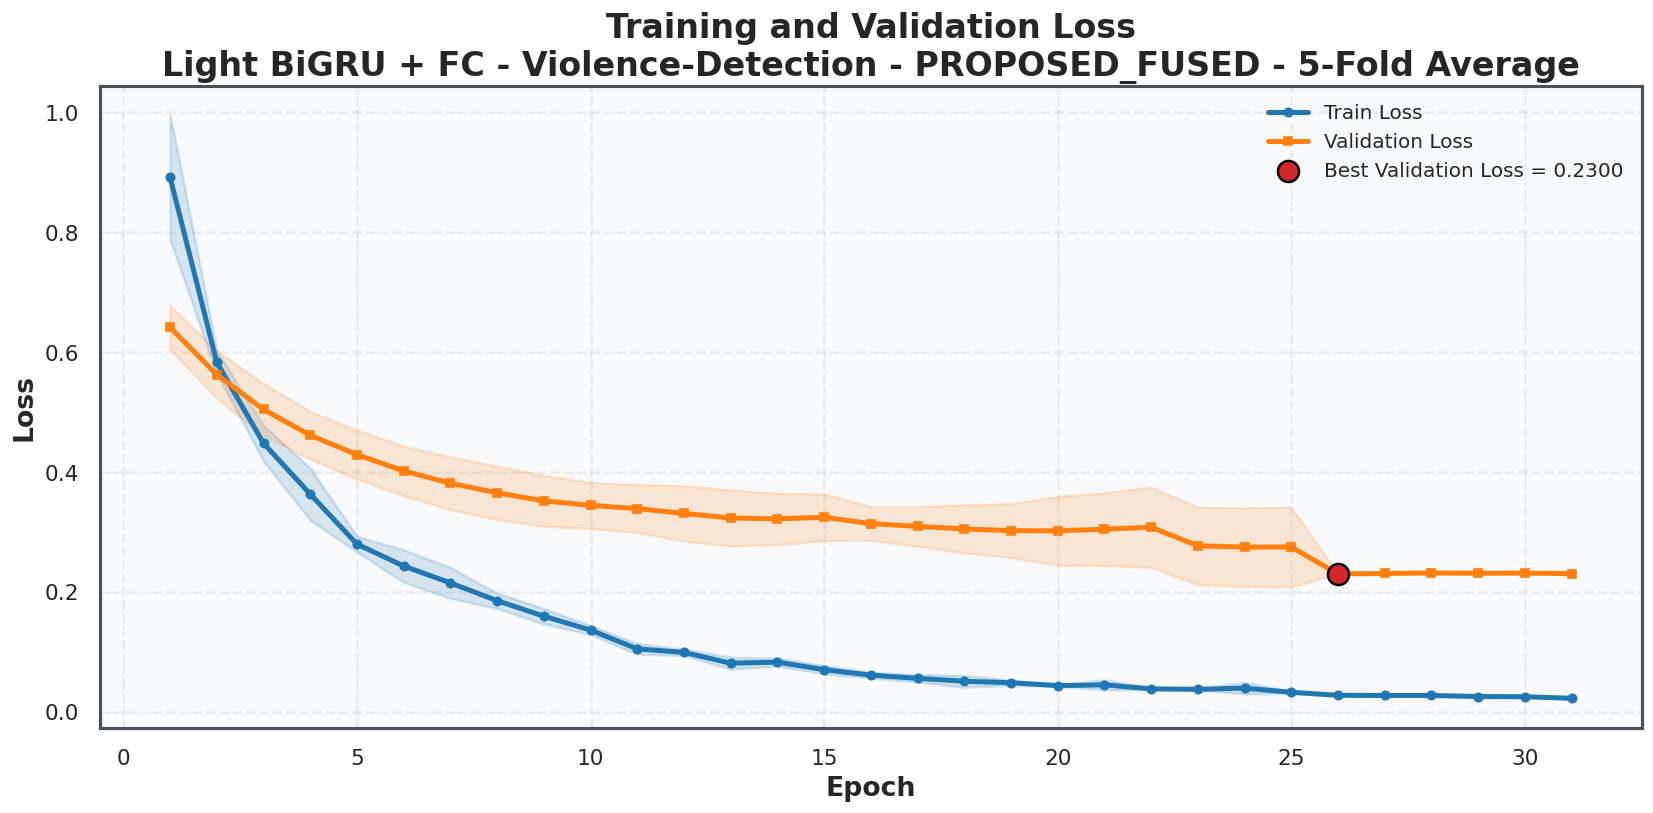

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f1_loss.png


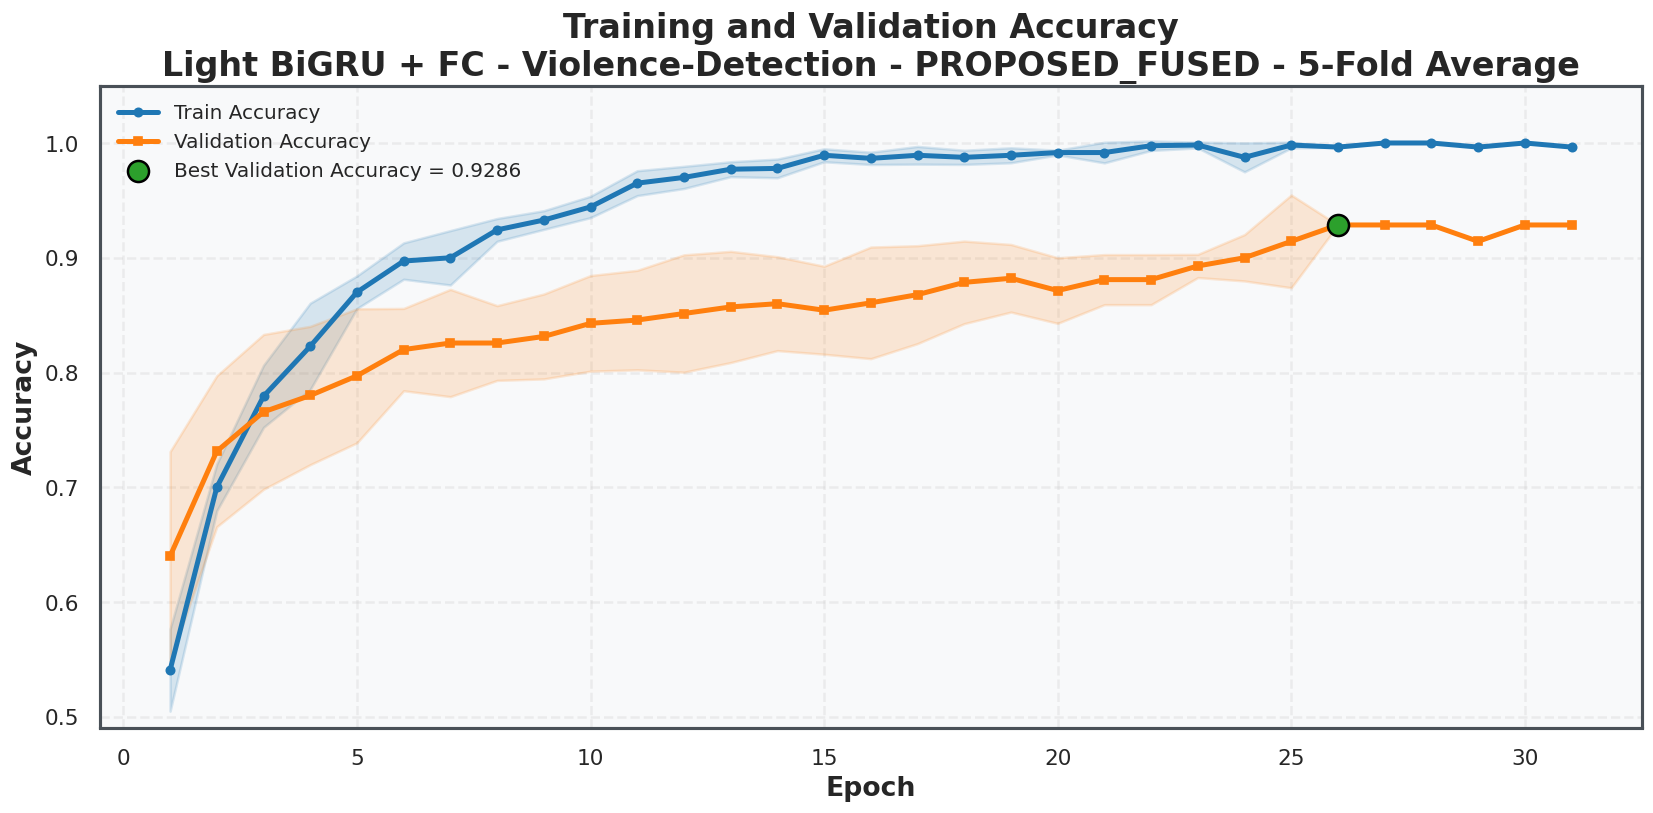

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f2_acc.png


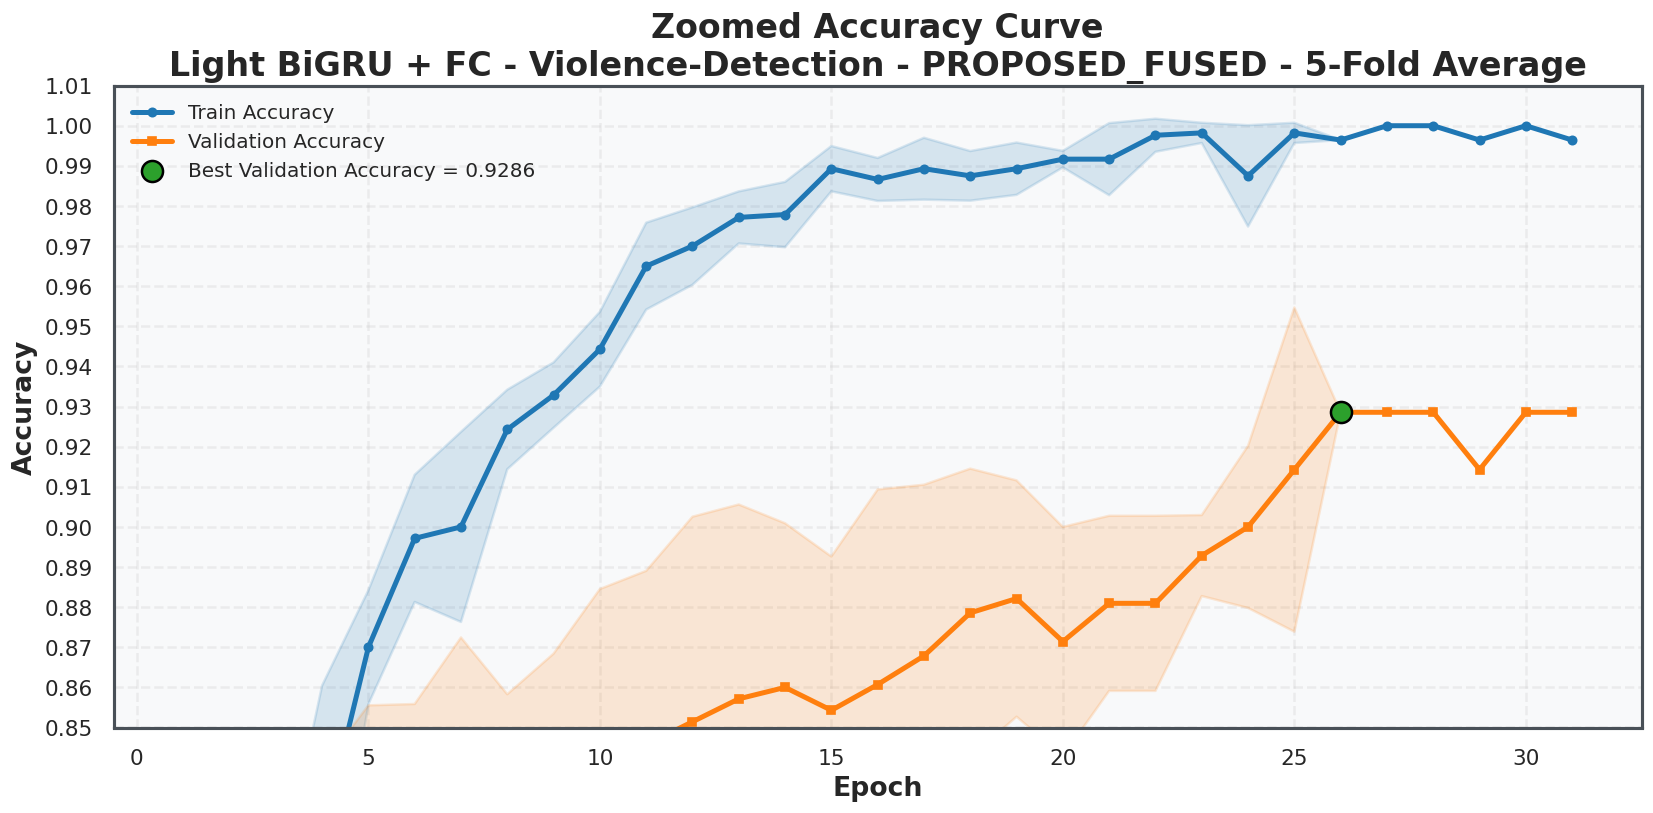

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f3_acc_zoom.png


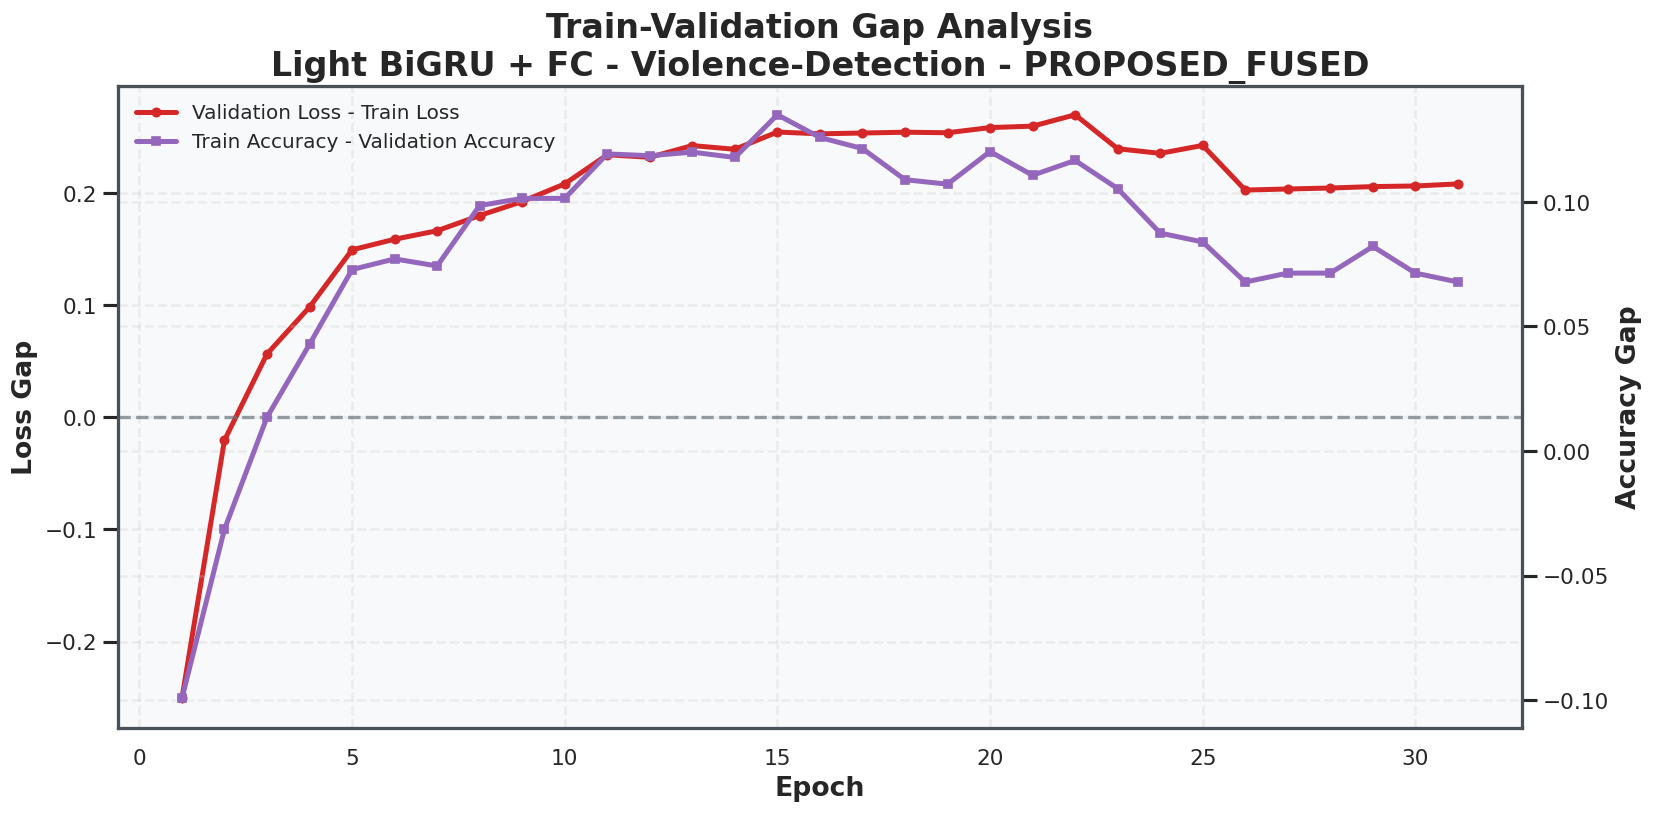

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f4_gap.png


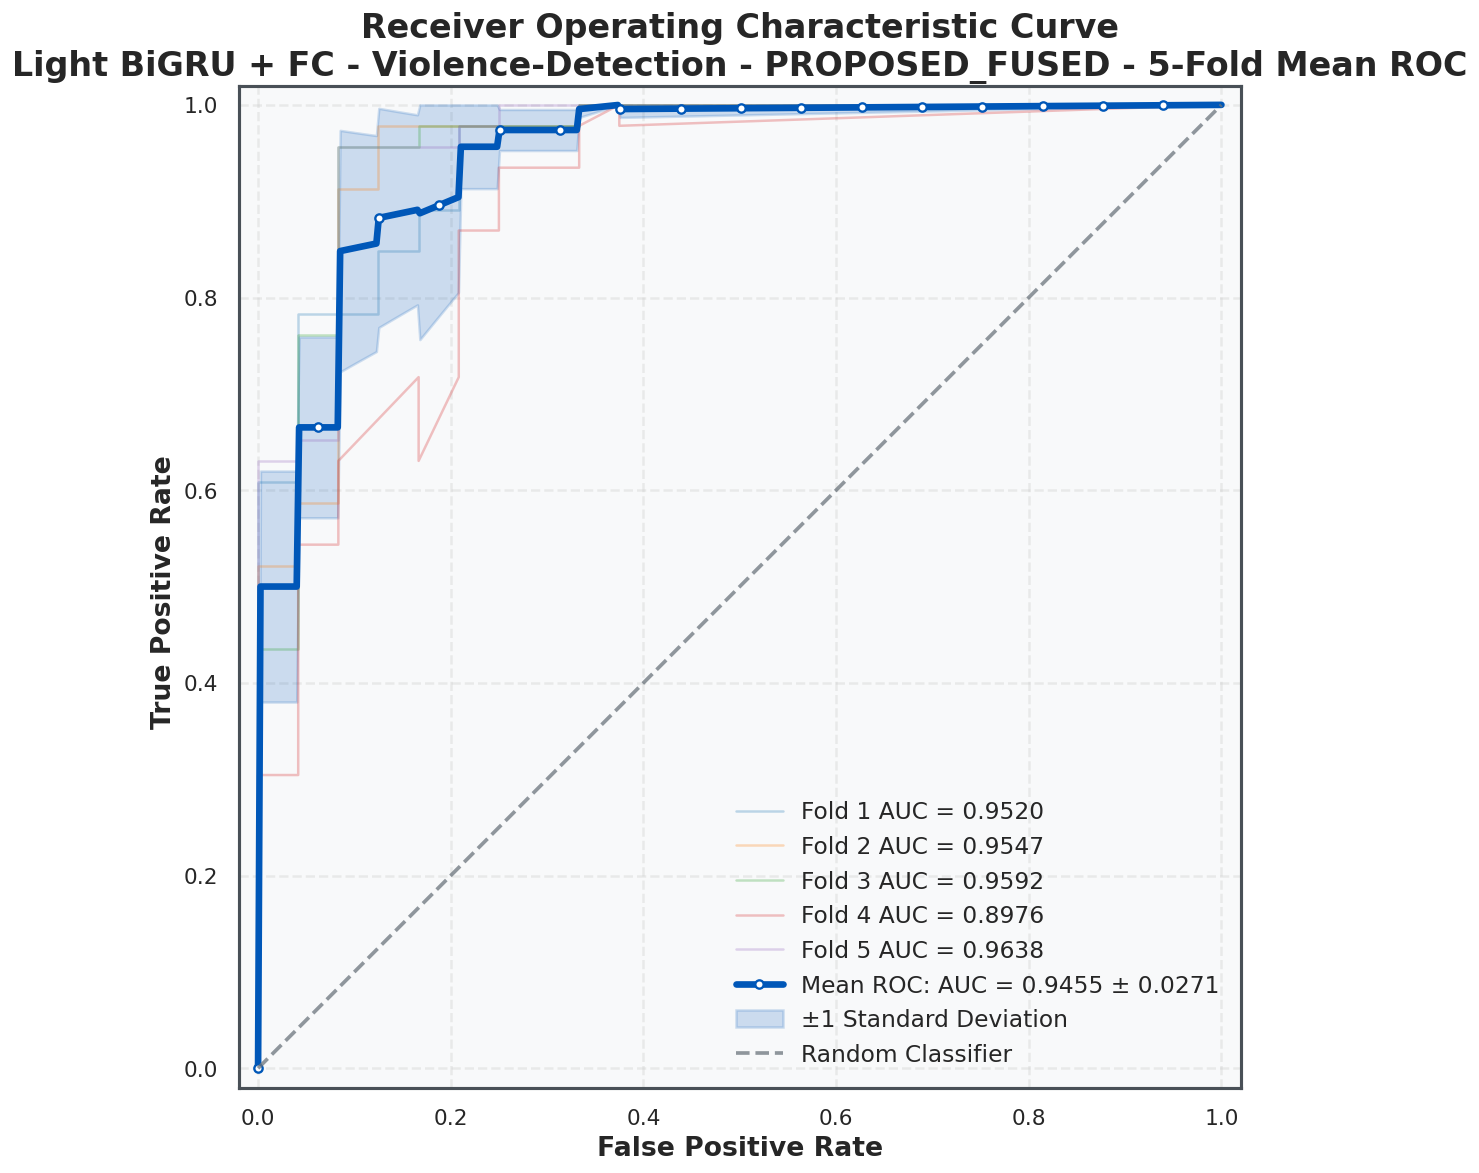

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f5_roc.png


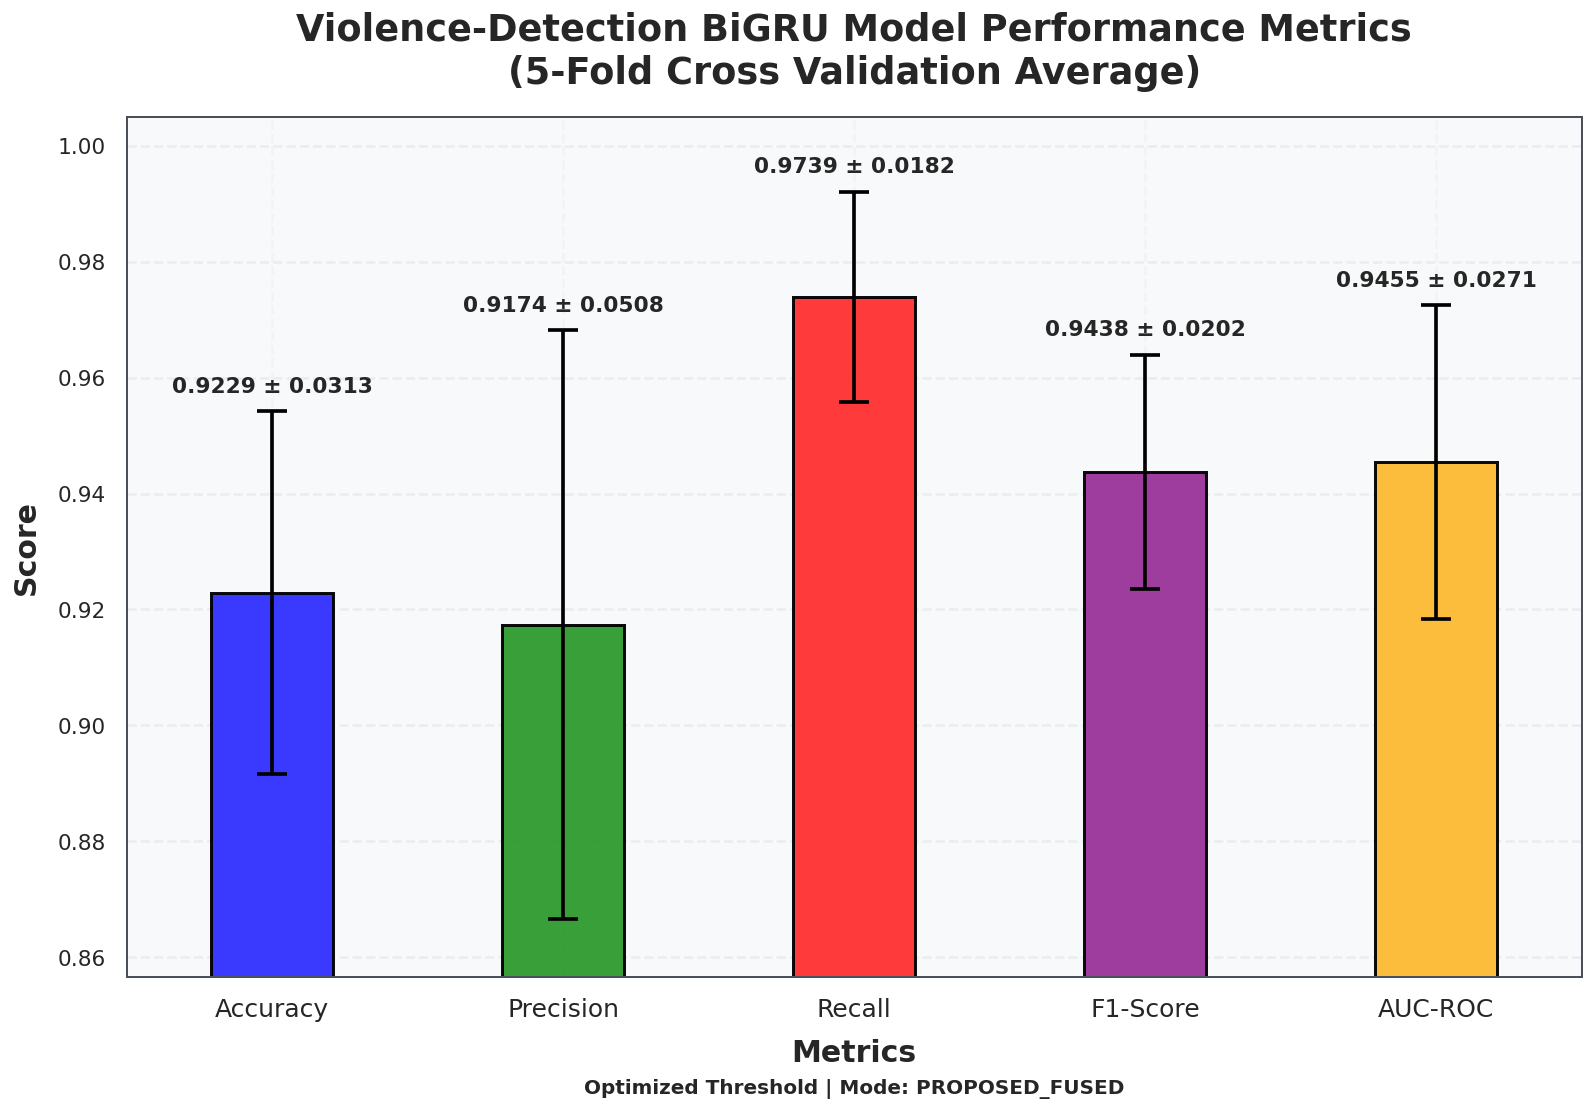

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f6_metrics_bar.png


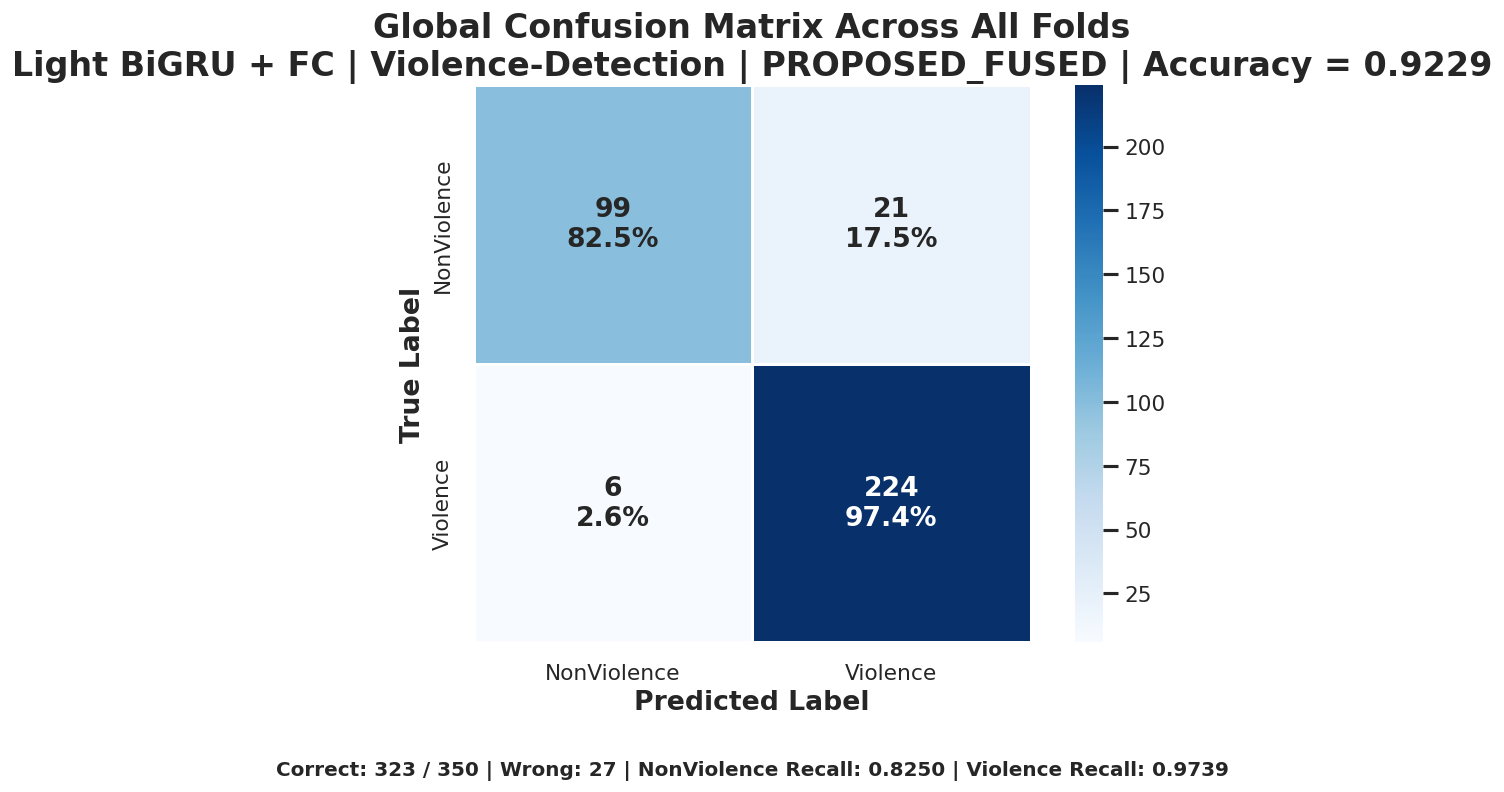

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f7_global_cm.png


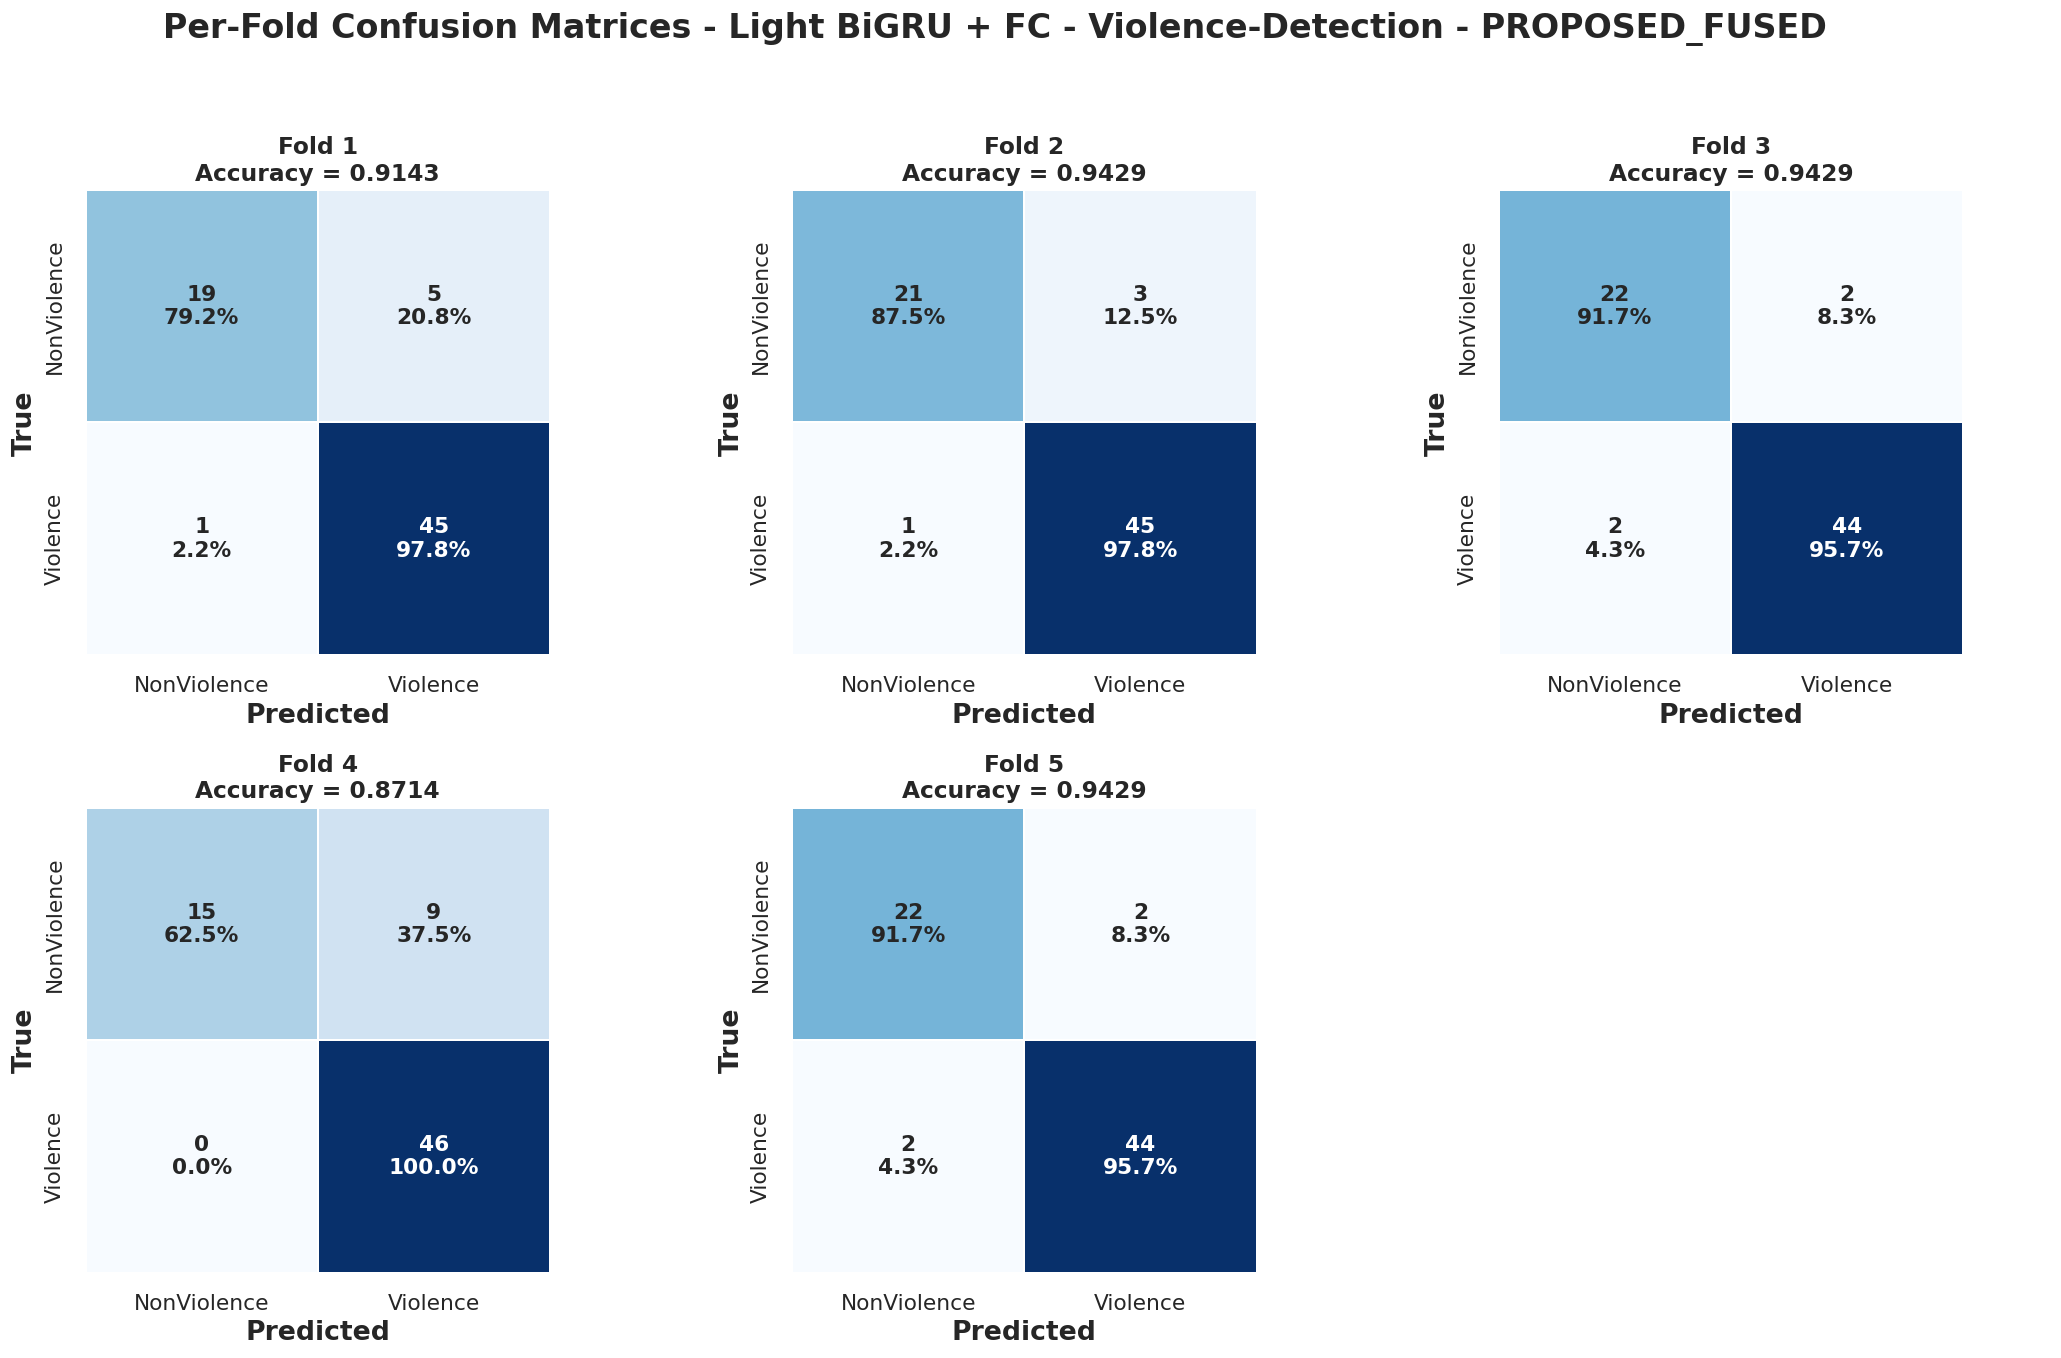

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f8_cm_folds.png


C:\Users\LOQ\AppData\Local\Temp\ipykernel_26048\2536992509.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


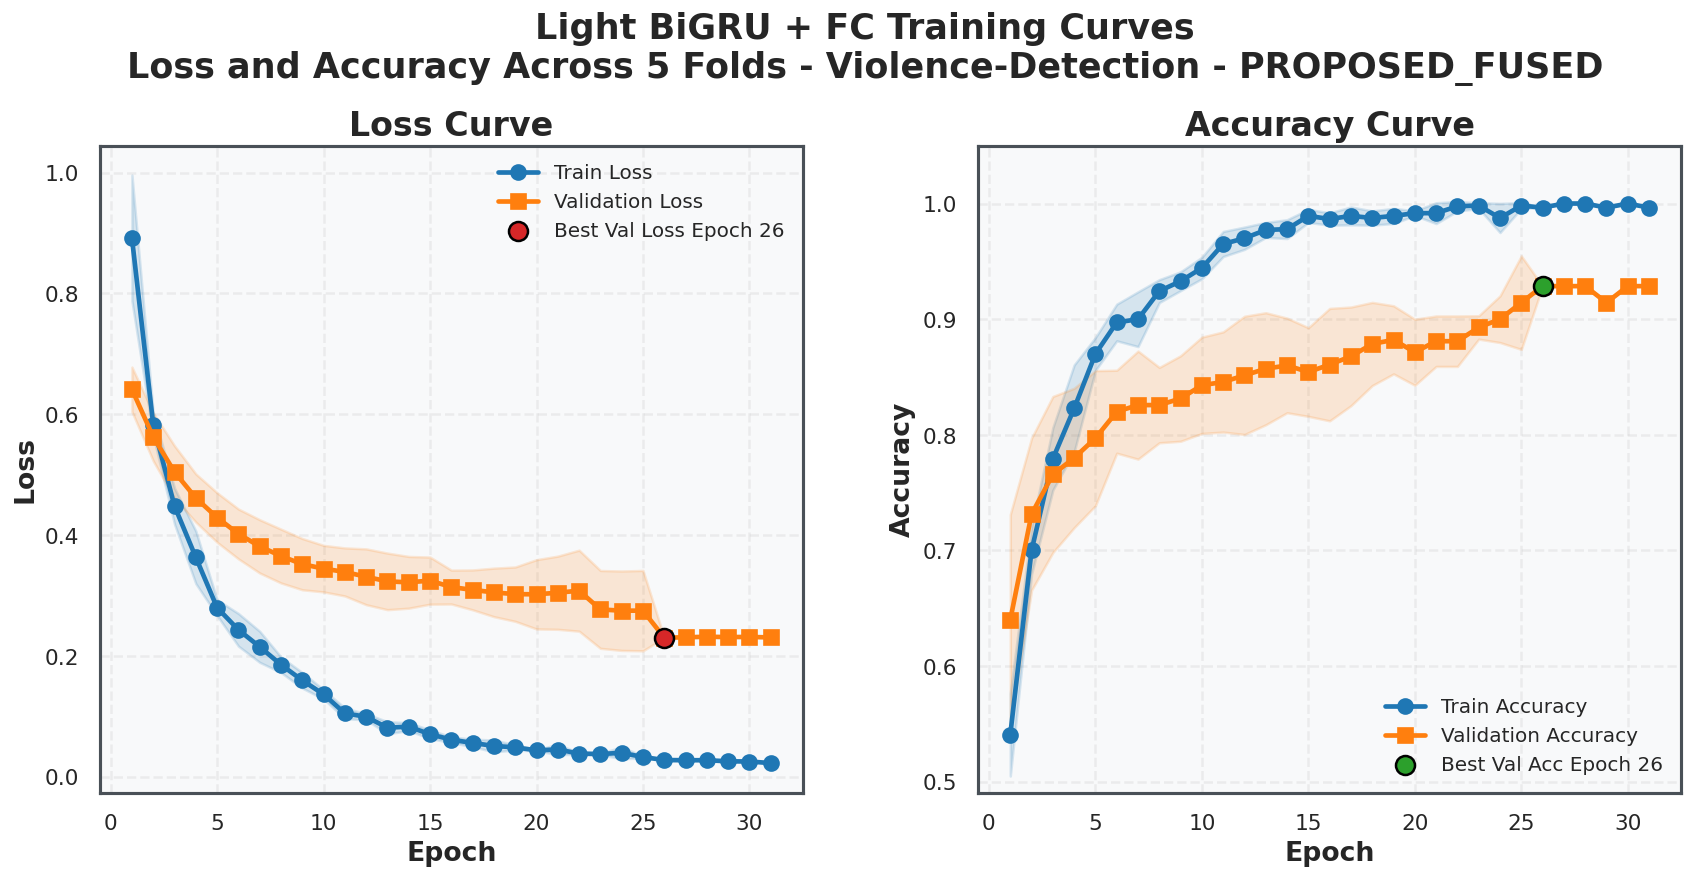

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f9_loss_acc_dash.png


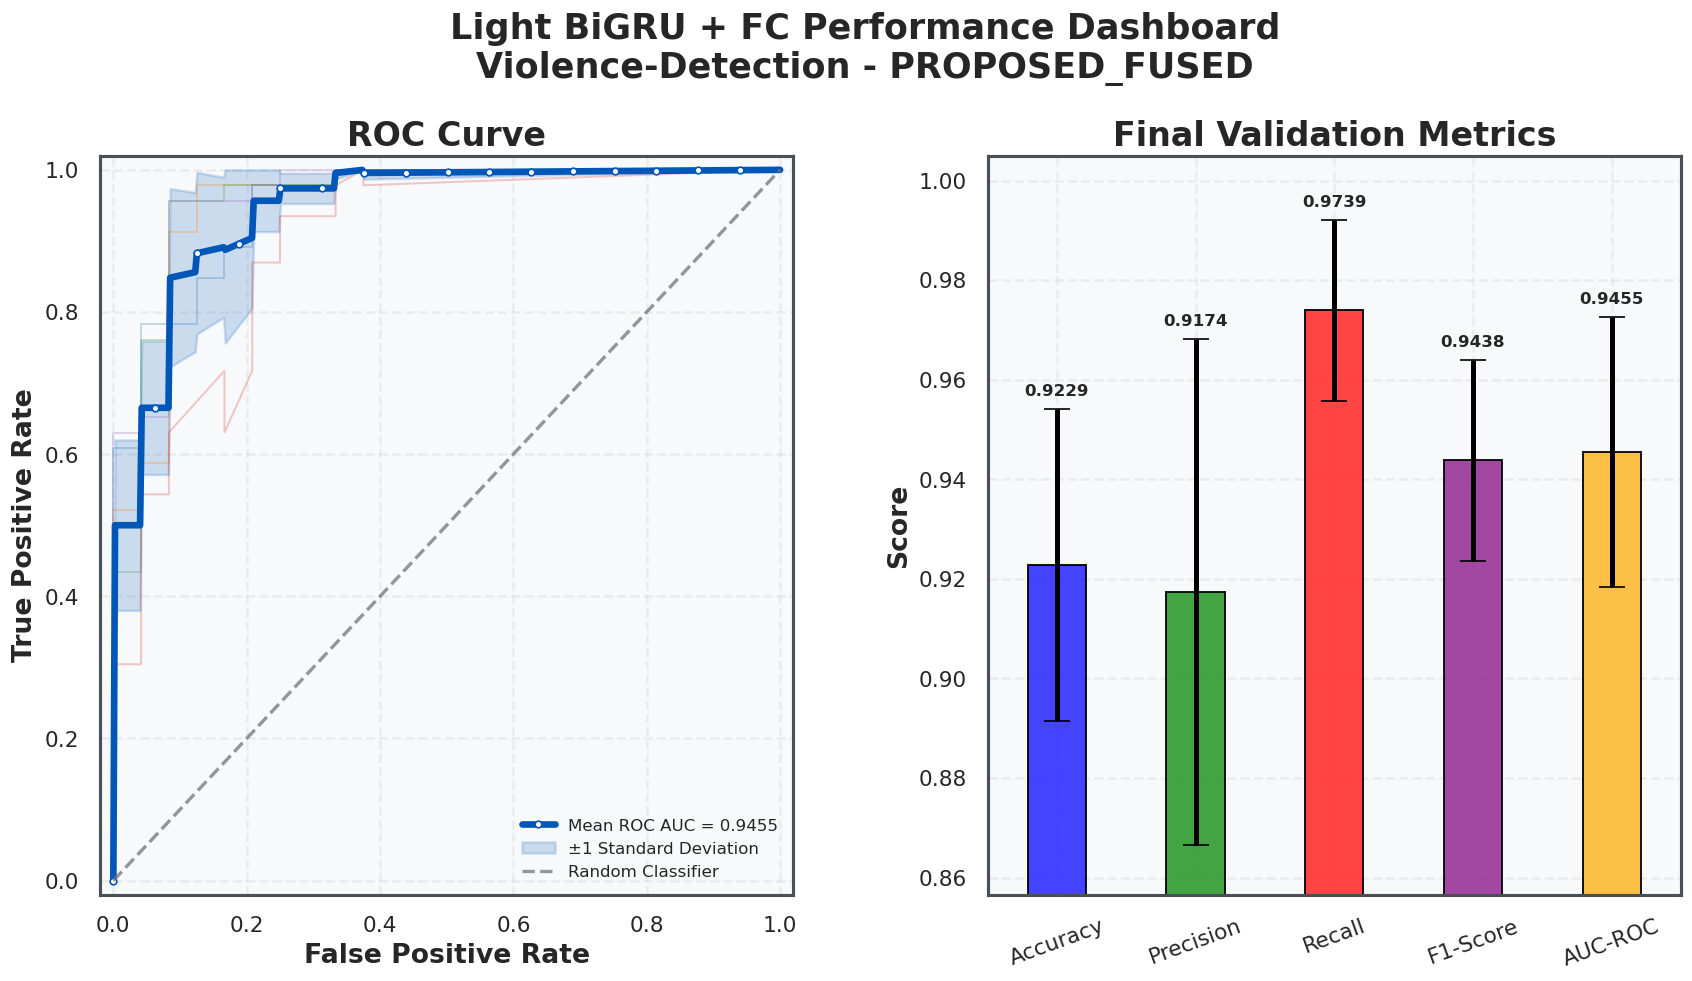

Saved: VD_BiGRU_Plots\PROPOSED_FUSED\f10_roc_metrics_dash.png

VIOLENCE-DETECTION LIGHT BiGRU + FULLY CONNECTED VISUALIZATION SUMMARY
WINDOWS-SAFE SHORT PATH VERSION
Result folder : violence-detectionBiGRUKerasResults\BiGRU_FC_PROPOSED_FUSED_LIGHT_NATURAL_EARLYSTOP_EPOCH50
Plot folder   : E:\codes\codefinalGRU_Article3new\VD_BiGRU_Plots\PROPOSED_FUSED
Mode          : PROPOSED_FUSED
Metrics mode  : optimized
Threshold info: Optimized Threshold

Curve Summary:
---------------------------------------------------------------------------
Best Validation Loss Epoch     : 26
Best Validation Loss           : 0.230034
Best Validation Accuracy Epoch : 26
Best Validation Accuracy       : 0.928571

Paper-Style Metrics:
---------------------------------------------------------------------------
Accuracy       : 0.9229 ± 0.0313
Precision      : 0.9174 ± 0.0508
Recall         : 0.9739 ± 0.0182
F1-Score       : 0.9438 ± 0.0202
AUC-ROC        : 0.9455 ± 0.0271
------------------------------------------

In [7]:
# ============================================================
# CELL 2 - COMPLETE VISUALIZATION CELL
# VIOLENCE-DETECTION LIGHT BiGRU + FULLY CONNECTED KERAS VERSION
# WINDOWS-SAFE SHORT PATH VERSION
#
# Compatible with:
#   violence-detectionBiGRUKerasResults/
#   BiGRU_FC_{MODE}_LIGHT_NATURAL_EARLYSTOP_EPOCH50
#
# Fixed:
#   - Windows FileNotFoundError caused by very long save paths
#   - Short output folder
#   - Short figure filenames
#   - save_and_show() always recreates the folder before saving
#
# Figures:
#   1) Loss Curve
#   2) Accuracy Curve
#   3) Zoomed Accuracy Curve
#   4) Train-Val Gap Curve
#   5) ROC Curve
#   6) Paper-Style Final Metrics Bar Chart
#   7) Global Confusion Matrix
#   8) Per-Fold Confusion Matrices
#   9) Loss + Accuracy Dashboard
#   10) ROC + Metrics Dashboard
# ============================================================


# ============================================================
# Imports
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    roc_curve,
    confusion_matrix
)


# ============================================================
# User Settings
# ============================================================

MODE = "PROPOSED_FUSED"

# MODE = "PROPOSED_FUSED"
# MODE = "PROPOSED_SPATIAL_ONLY"
# MODE = "PROPOSED_TEMPORAL_ONLY"

RESULT_NAME = f"BiGRU_FC_{MODE}_LIGHT_NATURAL_EARLYSTOP_EPOCH50"

RESULTS_BASE_ROOT = Path("violence-detectionBiGRUKerasResults")
results_root = RESULTS_BASE_ROOT / RESULT_NAME

CANDIDATE_RESULT_FOLDERS = [
    RESULTS_BASE_ROOT / "BiGRU_FC_PROPOSED_FUSED_LIGHT_NATURAL_EARLYSTOP_EPOCH50",
    RESULTS_BASE_ROOT / "BiGRU_FC_PROPOSED_SPATIAL_ONLY_LIGHT_NATURAL_EARLYSTOP_EPOCH50",
    RESULTS_BASE_ROOT / "BiGRU_FC_PROPOSED_TEMPORAL_ONLY_LIGHT_NATURAL_EARLYSTOP_EPOCH50",
]

SAVE_PLOTS = True
SHOW_PLOTS = True

CLASS_NAMES = ["NonViolence", "Violence"]

PROBABILITY_COLUMN = "violence_probability"

FIXED_DECISION_THRESHOLD = 0.5


# ============================================================
# Threshold Metrics Mode
#
# Options:
#   "fixed"      -> uses threshold = 0.5
#   "optimized"  -> finds best threshold per fold
# ============================================================

METRICS_MODE_FOR_BAR = "optimized"

THRESHOLD_OPTIMIZATION_OBJECTIVE = "f1"
# THRESHOLD_OPTIMIZATION_OBJECTIVE = "accuracy"
# THRESHOLD_OPTIMIZATION_OBJECTIVE = "mcc"

THRESHOLD_GRID = np.linspace(0.05, 0.95, 901)


# ============================================================
# Accuracy Axis Settings
# ============================================================

USE_ZOOMED_ACCURACY_AXIS = True

ACCURACY_Y_MIN = 0.85
ACCURACY_Y_MAX = 1.00
ACCURACY_Y_TICK_STEP = 0.01


# ============================================================
# Paper-Style Metrics Bar Settings
# ============================================================

PAPER_BAR_TITLE = "Violence-Detection BiGRU Model Performance Metrics\n(5-Fold Cross Validation Average)"

PAPER_BAR_Y_MIN = 0.94
PAPER_BAR_Y_MAX = 1.005

FORCE_PAPER_BAR_YLIM = True

PAPER_BAR_METRICS = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC",
]

PAPER_BAR_COLORS = [
    "#3030FF",
    "#2E9B2E",
    "#FF3030",
    "#993399",
    "#FDBA32",
]

PAPER_BAR_FIGSIZE = (13.5, 9.5)
PAPER_BAR_WIDTH = 0.42
PAPER_BAR_TEXT_OFFSET = 0.0025
PAPER_BAR_VALUE_FONTSIZE = 13
PAPER_BAR_XLABEL_FONTSIZE = 15
PAPER_BAR_TITLE_FONTSIZE = 22


# ============================================================
# Auto Detect Result Folder
# ============================================================

if not results_root.exists():
    found = False

    for candidate in CANDIDATE_RESULT_FOLDERS:
        if candidate.exists():
            results_root = candidate
            RESULT_NAME = candidate.name
            found = True

            if "PROPOSED_FUSED" in candidate.name:
                MODE = "PROPOSED_FUSED"
            elif "PROPOSED_SPATIAL_ONLY" in candidate.name:
                MODE = "PROPOSED_SPATIAL_ONLY"
            elif "PROPOSED_TEMPORAL_ONLY" in candidate.name:
                MODE = "PROPOSED_TEMPORAL_ONLY"

            break

    if not found:
        all_dirs = sorted(RESULTS_BASE_ROOT.glob("*")) if RESULTS_BASE_ROOT.exists() else []

        print("Available result folders:")
        for d in all_dirs:
            print(" -", d)

        raise FileNotFoundError(
            f"Result folder not found:\n{results_root}\n\n"
            f"First run the VIOLENCE-DETECTION LIGHT BiGRU + FC training cell."
        )


# ============================================================
# Windows-Safe Short Output Folder
# ============================================================

plot_output_dir = Path("VD_BiGRU_Plots") / MODE
plot_output_dir.mkdir(parents=True, exist_ok=True)

print("=" * 110)
print("Using result folder:")
print(results_root)
print("Detected mode:", MODE)
print("Windows-safe plot output folder:")
print(plot_output_dir.resolve())
print("=" * 110)


# ============================================================
# Load CSV Files
# ============================================================

summary_csv = results_root / "all_folds_summary.csv"
epoch_metrics_csv = results_root / "all_folds_epoch_metrics.csv"
predictions_csv = results_root / "all_folds_predictions.csv"
final_metrics_csv = results_root / "final_metrics_mean_std.csv"

if not summary_csv.exists():
    raise FileNotFoundError(f"Missing summary CSV: {summary_csv}")

if not epoch_metrics_csv.exists():
    raise FileNotFoundError(f"Missing epoch metrics CSV: {epoch_metrics_csv}")

if not predictions_csv.exists():
    raise FileNotFoundError(f"Missing predictions CSV: {predictions_csv}")

fold_summary_df = pd.read_csv(summary_csv)
epoch_df = pd.read_csv(epoch_metrics_csv)
predictions_df = pd.read_csv(predictions_csv)

if final_metrics_csv.exists():
    final_metrics_df_original = pd.read_csv(final_metrics_csv)
else:
    final_metrics_df_original = pd.DataFrame()

if PROBABILITY_COLUMN not in predictions_df.columns:
    raise ValueError(
        f"Required probability column not found: {PROBABILITY_COLUMN}\n"
        f"Available columns:\n{list(predictions_df.columns)}\n\n"
        f"For violence-detection training, predictions CSV must contain:\n"
        f"    violence_probability"
    )

required_prediction_cols = ["fold", "true_label", PROBABILITY_COLUMN]

for col in required_prediction_cols:
    if col not in predictions_df.columns:
        raise ValueError(
            f"Required prediction column not found: {col}\n"
            f"Available columns:\n{list(predictions_df.columns)}"
        )

print("\nLoaded data:")
print("Fold summary shape :", fold_summary_df.shape)
print("Epoch metrics shape:", epoch_df.shape)
print("Predictions shape  :", predictions_df.shape)
print("Original final metrics shape:", final_metrics_df_original.shape)


# ============================================================
# Plot Style
# ============================================================

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("default")

sns.set_style("whitegrid")
sns.set_context("talk")

plt.rcParams.update({
    "font.size": 14,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.framealpha": 0.95,
    "lines.linewidth": 3,
    "figure.figsize": (14, 7),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.facecolor": "#F8F9FA",
    "figure.facecolor": "white",
    "axes.edgecolor": "#495057",
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.linestyle": "--",
})

COLOR_TRAIN = "#1F77B4"
COLOR_VAL = "#FF7F0E"
COLOR_ROC_MEAN = "#0057B8"
COLOR_RANDOM = "#6C757D"
COLOR_BEST = "#2CA02C"
COLOR_ERROR = "#D62728"
COLOR_GAP = "#9467BD"


# ============================================================
# Helper Functions
# ============================================================

def save_and_show(filename):
    plot_output_dir.mkdir(parents=True, exist_ok=True)

    safe_filename = Path(filename).name
    path = plot_output_dir / safe_filename

    plt.tight_layout()

    if SAVE_PLOTS:
        plt.savefig(
            path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

    if SHOW_PLOTS:
        plt.show()

    plt.close()

    print("Saved:", path)


def make_cm_array(tn, fp, fn, tp):
    return np.array([
        [tn, fp],
        [fn, tp]
    ], dtype=int)


def normalize_cm_rows(cm):
    cm = cm.astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return cm / row_sum


def annotate_confusion_matrix(cm, normalize=True):
    if not normalize:
        return cm.astype(str)

    cm_norm = normalize_cm_rows(cm)
    annot = np.empty_like(cm).astype(object)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_norm[i, j] * 100:.1f}%"

    return annot


def apply_zoomed_accuracy_axis(ax):
    if USE_ZOOMED_ACCURACY_AXIS:
        ax.set_ylim(ACCURACY_Y_MIN, ACCURACY_Y_MAX)

        ticks = np.arange(
            ACCURACY_Y_MIN,
            ACCURACY_Y_MAX + ACCURACY_Y_TICK_STEP,
            ACCURACY_Y_TICK_STEP
        )

        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{t:.2f}" for t in ticks])
        ax.grid(True, which="major", axis="y", alpha=0.35, linestyle="--")
    else:
        ax.set_ylim(0.0, 1.05)


def compute_metrics_from_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    if len(np.unique(y_true)) >= 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "Accuracy": float(acc),
        "Precision": float(pre),
        "Recall": float(rec),
        "F1-Score": float(f1),
        "AUC-ROC": float(auc) if not np.isnan(auc) else np.nan,
        "MCC": float(mcc) if not np.isnan(mcc) else np.nan,
        "Sensitivity": float(sensitivity),
        "Specificity": float(specificity),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def find_best_threshold(y_true, y_prob, objective="f1"):
    best_threshold = 0.5
    best_score = -np.inf
    best_metrics = None

    for threshold in THRESHOLD_GRID:
        metrics = compute_metrics_from_threshold(
            y_true=y_true,
            y_prob=y_prob,
            threshold=threshold
        )

        if objective == "accuracy":
            score = metrics["Accuracy"]
        elif objective == "mcc":
            score = metrics["MCC"]
        else:
            score = metrics["F1-Score"]

        if np.isnan(score):
            score = -np.inf

        if score > best_score:
            best_score = score
            best_threshold = threshold
            best_metrics = metrics

    return best_threshold, best_metrics


def build_final_metrics_mean_std(metrics_per_fold_df, metrics_for_summary):
    rows = []

    for metric in metrics_for_summary:
        rows.append({
            "mode": MODE,
            "metric": metric,
            "mean": float(metrics_per_fold_df[metric].mean()),
            "std": float(metrics_per_fold_df[metric].std(ddof=1)),
        })

    return pd.DataFrame(rows)


# ============================================================
# Prepare Epoch Curves
# ============================================================

required_cols = [
    "epoch",
    "loss",
    "val_loss",
    "accuracy",
    "val_accuracy"
]

for col in required_cols:
    if col not in epoch_df.columns:
        raise ValueError(
            f"Required column not found: {col}\n"
            f"Available columns:\n{list(epoch_df.columns)}"
        )

epoch_df = epoch_df.copy()
epoch_df["epoch"] = epoch_df["epoch"].astype(int)

grouped = epoch_df.groupby("epoch")

epochs = grouped["epoch"].mean().index.values.astype(int)

train_loss_mean = grouped["loss"].mean()
train_loss_std = grouped["loss"].std().fillna(0)

val_loss_mean = grouped["val_loss"].mean()
val_loss_std = grouped["val_loss"].std().fillna(0)

train_acc_mean = grouped["accuracy"].mean()
train_acc_std = grouped["accuracy"].std().fillna(0)

val_acc_mean = grouped["val_accuracy"].mean()
val_acc_std = grouped["val_accuracy"].std().fillna(0)

loss_gap_mean = val_loss_mean - train_loss_mean
acc_gap_mean = train_acc_mean - val_acc_mean


# ============================================================
# Threshold Optimization From Predictions
# ============================================================

fixed_rows = []
optimized_rows = []
optimized_prediction_rows = []

for fold in sorted(predictions_df["fold"].unique()):
    sub = predictions_df[predictions_df["fold"] == fold].copy()

    y_true = sub["true_label"].astype(int).values
    y_prob = sub[PROBABILITY_COLUMN].astype(float).values

    fixed_metrics = compute_metrics_from_threshold(
        y_true=y_true,
        y_prob=y_prob,
        threshold=FIXED_DECISION_THRESHOLD
    )

    fixed_metrics["fold"] = int(fold)
    fixed_metrics["mode"] = MODE
    fixed_rows.append(fixed_metrics)

    best_threshold, best_metrics = find_best_threshold(
        y_true=y_true,
        y_prob=y_prob,
        objective=THRESHOLD_OPTIMIZATION_OBJECTIVE
    )

    best_metrics["fold"] = int(fold)
    best_metrics["mode"] = MODE
    best_metrics["optimization_objective"] = THRESHOLD_OPTIMIZATION_OBJECTIVE
    optimized_rows.append(best_metrics)

    sub["optimized_threshold"] = best_threshold
    sub["optimized_pred_label"] = (
        sub[PROBABILITY_COLUMN].astype(float).values >= best_threshold
    ).astype(int)

    sub["optimized_pred_class"] = sub["optimized_pred_label"].map({
        0: "NonViolence",
        1: "Violence"
    })

    optimized_prediction_rows.append(sub)

fixed_metrics_per_fold_df = pd.DataFrame(fixed_rows)
optimized_metrics_per_fold_df = pd.DataFrame(optimized_rows)
optimized_predictions_df = pd.concat(optimized_prediction_rows, ignore_index=True)

all_metrics_for_summary = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC",
    "MCC",
    "Sensitivity",
    "Specificity",
]

fixed_final_metrics_df = build_final_metrics_mean_std(
    fixed_metrics_per_fold_df,
    all_metrics_for_summary
)

optimized_final_metrics_df = build_final_metrics_mean_std(
    optimized_metrics_per_fold_df,
    all_metrics_for_summary
)

fixed_metrics_per_fold_df.to_csv(
    plot_output_dir / "fixed_metrics_folds.csv",
    index=False
)

optimized_metrics_per_fold_df.to_csv(
    plot_output_dir / "opt_metrics_folds.csv",
    index=False
)

fixed_final_metrics_df.to_csv(
    plot_output_dir / "fixed_metrics_mean_std.csv",
    index=False
)

optimized_final_metrics_df.to_csv(
    plot_output_dir / "opt_metrics_mean_std.csv",
    index=False
)

optimized_predictions_df.to_csv(
    plot_output_dir / "opt_predictions.csv",
    index=False
)

if METRICS_MODE_FOR_BAR == "optimized":
    final_metrics_df = optimized_final_metrics_df.copy()
    metrics_per_fold_for_cm_df = optimized_metrics_per_fold_df.copy()
    predictions_for_cm_df = optimized_predictions_df.copy()
    threshold_label = "Optimized Threshold"
else:
    final_metrics_df = fixed_final_metrics_df.copy()
    metrics_per_fold_for_cm_df = fixed_metrics_per_fold_df.copy()
    predictions_for_cm_df = predictions_df.copy()
    threshold_label = "Fixed Threshold = 0.5"

print("\nThreshold optimization summary:")
print("-" * 100)
print("Metrics mode for bar:", METRICS_MODE_FOR_BAR)
print("Optimization objective:", THRESHOLD_OPTIMIZATION_OBJECTIVE)
print("\nFixed threshold metrics:")
print(fixed_final_metrics_df)
print("\nOptimized threshold metrics:")
print(optimized_final_metrics_df)
print("-" * 100)


# ============================================================
# Figure 1: Loss Curve
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    epochs,
    train_loss_mean.values,
    marker="o",
    markersize=5,
    color=COLOR_TRAIN,
    label="Train Loss"
)

ax.fill_between(
    epochs,
    train_loss_mean.values - train_loss_std.values,
    train_loss_mean.values + train_loss_std.values,
    alpha=0.16,
    color=COLOR_TRAIN
)

ax.plot(
    epochs,
    val_loss_mean.values,
    marker="s",
    markersize=5,
    color=COLOR_VAL,
    label="Validation Loss"
)

ax.fill_between(
    epochs,
    val_loss_mean.values - val_loss_std.values,
    val_loss_mean.values + val_loss_std.values,
    alpha=0.16,
    color=COLOR_VAL
)

best_val_loss_epoch = int(val_loss_mean.idxmin())
best_val_loss = float(val_loss_mean.min())

ax.scatter(
    [best_val_loss_epoch],
    [best_val_loss],
    s=160,
    color=COLOR_ERROR,
    edgecolor="black",
    zorder=5,
    label=f"Best Validation Loss = {best_val_loss:.4f}"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(
    f"Training and Validation Loss\n"
    f"Light BiGRU + FC - Violence-Detection - {MODE} - 5-Fold Average"
)

ax.legend()
ax.grid(True, alpha=0.3)

save_and_show("f1_loss.png")


# ============================================================
# Figure 2: Accuracy Curve
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    epochs,
    train_acc_mean.values,
    marker="o",
    markersize=5,
    color=COLOR_TRAIN,
    label="Train Accuracy"
)

ax.fill_between(
    epochs,
    train_acc_mean.values - train_acc_std.values,
    train_acc_mean.values + train_acc_std.values,
    alpha=0.16,
    color=COLOR_TRAIN
)

ax.plot(
    epochs,
    val_acc_mean.values,
    marker="s",
    markersize=5,
    color=COLOR_VAL,
    label="Validation Accuracy"
)

ax.fill_between(
    epochs,
    val_acc_mean.values - val_acc_std.values,
    val_acc_mean.values + val_acc_std.values,
    alpha=0.16,
    color=COLOR_VAL
)

best_val_acc_epoch = int(val_acc_mean.idxmax())
best_val_acc = float(val_acc_mean.max())

ax.scatter(
    [best_val_acc_epoch],
    [best_val_acc],
    s=160,
    color=COLOR_BEST,
    edgecolor="black",
    zorder=5,
    label=f"Best Validation Accuracy = {best_val_acc:.4f}"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title(
    f"Training and Validation Accuracy\n"
    f"Light BiGRU + FC - Violence-Detection - {MODE} - 5-Fold Average"
)

ax.set_ylim(
    max(0.0, min(train_acc_mean.min(), val_acc_mean.min()) - 0.05),
    min(1.05, max(train_acc_mean.max(), val_acc_mean.max()) + 0.05)
)

ax.legend()
ax.grid(True, alpha=0.3)

save_and_show("f2_acc.png")


# ============================================================
# Figure 3: Zoomed Accuracy Curve
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    epochs,
    train_acc_mean.values,
    marker="o",
    markersize=5,
    color=COLOR_TRAIN,
    label="Train Accuracy"
)

ax.fill_between(
    epochs,
    train_acc_mean.values - train_acc_std.values,
    train_acc_mean.values + train_acc_std.values,
    alpha=0.16,
    color=COLOR_TRAIN
)

ax.plot(
    epochs,
    val_acc_mean.values,
    marker="s",
    markersize=5,
    color=COLOR_VAL,
    label="Validation Accuracy"
)

ax.fill_between(
    epochs,
    val_acc_mean.values - val_acc_std.values,
    val_acc_mean.values + val_acc_std.values,
    alpha=0.16,
    color=COLOR_VAL
)

ax.scatter(
    [best_val_acc_epoch],
    [best_val_acc],
    s=160,
    color=COLOR_BEST,
    edgecolor="black",
    zorder=5,
    label=f"Best Validation Accuracy = {best_val_acc:.4f}"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title(
    f"Zoomed Accuracy Curve\n"
    f"Light BiGRU + FC - Violence-Detection - {MODE} - 5-Fold Average"
)

apply_zoomed_accuracy_axis(ax)

ax.legend()
ax.grid(True, alpha=0.3)

save_and_show("f3_acc_zoom.png")


# ============================================================
# Figure 4: Train-Val Gap Curve
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(
    epochs,
    loss_gap_mean.values,
    marker="o",
    markersize=5,
    color=COLOR_ERROR,
    label="Validation Loss - Train Loss"
)

ax1.axhline(
    0,
    color=COLOR_RANDOM,
    linestyle="--",
    linewidth=2,
    alpha=0.7
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss Gap")
ax1.set_title(
    f"Train-Validation Gap Analysis\n"
    f"Light BiGRU + FC - Violence-Detection - {MODE}"
)

ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    epochs,
    acc_gap_mean.values,
    marker="s",
    markersize=5,
    color=COLOR_GAP,
    label="Train Accuracy - Validation Accuracy"
)

ax2.set_ylabel("Accuracy Gap")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

save_and_show("f4_gap.png")


# ============================================================
# Figure 5: ROC Curve
# ============================================================

roc_rows = []

for fold in sorted(predictions_df["fold"].unique()):
    sub = predictions_df[predictions_df["fold"] == fold].copy()

    y_true = sub["true_label"].astype(int).values
    y_prob = sub[PROBABILITY_COLUMN].astype(float).values

    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_prob,
        pos_label=1
    )

    fold_auc = roc_auc_score(y_true, y_prob)

    temp = pd.DataFrame({
        "fold": fold,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
        "auc": fold_auc
    })

    roc_rows.append(temp)

if len(roc_rows) == 0:
    raise ValueError("No valid ROC data found. Each fold must contain both classes.")

roc_df = pd.concat(roc_rows, ignore_index=True)
roc_df.to_csv(plot_output_dir / "roc_points.csv", index=False)

mean_fpr = np.linspace(0, 1, 400)

fold_tprs = []
fold_aucs = []

fig, ax = plt.subplots(figsize=(10, 10))

for fold in sorted(roc_df["fold"].unique()):
    sub = roc_df[roc_df["fold"] == fold].copy()
    sub = sub.sort_values("fpr")

    fpr = sub["fpr"].values.astype(float)
    tpr = sub["tpr"].values.astype(float)
    fold_auc = float(sub["auc"].iloc[0])

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    interp_tpr[-1] = 1.0

    fold_tprs.append(interp_tpr)
    fold_aucs.append(fold_auc)

    ax.plot(
        fpr,
        tpr,
        linewidth=1.5,
        alpha=0.28,
        label=f"Fold {int(fold)} AUC = {fold_auc:.4f}"
    )

fold_tprs = np.asarray(fold_tprs)

mean_tpr = fold_tprs.mean(axis=0)
std_tpr = fold_tprs.std(axis=0)

mean_tpr[0] = 0.0
mean_tpr[-1] = 1.0

mean_auc = float(np.mean(fold_aucs))
std_auc = float(np.std(fold_aucs, ddof=1)) if len(fold_aucs) > 1 else 0.0

lower_tpr = np.maximum(mean_tpr - std_tpr, 0)
upper_tpr = np.minimum(mean_tpr + std_tpr, 1)

ax.plot(
    mean_fpr,
    mean_tpr,
    color=COLOR_ROC_MEAN,
    linewidth=4,
    marker="o",
    markevery=25,
    markersize=5,
    markerfacecolor="white",
    markeredgecolor=COLOR_ROC_MEAN,
    markeredgewidth=1.4,
    label=f"Mean ROC: AUC = {mean_auc:.4f} ± {std_auc:.4f}"
)

ax.fill_between(
    mean_fpr,
    lower_tpr,
    upper_tpr,
    color=COLOR_ROC_MEAN,
    alpha=0.18,
    label="±1 Standard Deviation"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2.2,
    color=COLOR_RANDOM,
    alpha=0.75,
    label="Random Classifier"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate ")
ax.set_title(
    f"Receiver Operating Characteristic Curve\n"
    f"Light BiGRU + FC - Violence-Detection - {MODE} - 5-Fold Mean ROC"
)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="lower right", fontsize=14)

save_and_show("f5_roc.png")


# ============================================================
# Figure 6: Paper-Style Final Metrics Bar Chart
# ============================================================

selected_metrics_df = final_metrics_df[
    final_metrics_df["metric"].isin(PAPER_BAR_METRICS)
].copy()

selected_metrics_df["metric"] = pd.Categorical(
    selected_metrics_df["metric"],
    categories=PAPER_BAR_METRICS,
    ordered=True
)

selected_metrics_df = selected_metrics_df.sort_values("metric")

bar_metrics = selected_metrics_df["metric"].astype(str).tolist()
bar_values = selected_metrics_df["mean"].values.astype(float)
bar_std = selected_metrics_df["std"].fillna(0).values.astype(float)

fig, ax = plt.subplots(figsize=PAPER_BAR_FIGSIZE)

x_pos = np.arange(len(bar_metrics))

bars = ax.bar(
    x_pos,
    bar_values,
    yerr=bar_std,
    capsize=9,
    color=PAPER_BAR_COLORS[:len(bar_metrics)],
    edgecolor="black",
    linewidth=1.8,
    alpha=0.95,
    width=PAPER_BAR_WIDTH,
    error_kw={
        "elinewidth": 2.2,
        "ecolor": "black",
        "capthick": 2.2,
        "capsize": 9
    }
)

for bar, val, err in zip(bars, bar_values, bar_std):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        val + err + PAPER_BAR_TEXT_OFFSET,
        f"{val:.4f} ± {err:.4f}",
        ha="center",
        va="bottom",
        fontsize=PAPER_BAR_VALUE_FONTSIZE,
        fontweight="bold"
    )

ax.set_xlabel("Metrics", fontsize=18, fontweight="bold", labelpad=10)
ax.set_ylabel("Score", fontsize=18, fontweight="bold", labelpad=10)

ax.set_title(
    PAPER_BAR_TITLE,
    fontsize=PAPER_BAR_TITLE_FONTSIZE,
    fontweight="bold",
    pad=20
)

ax.set_xticks(x_pos)
ax.set_xticklabels(bar_metrics, fontsize=PAPER_BAR_XLABEL_FONTSIZE)

if FORCE_PAPER_BAR_YLIM:
    safe_y_min = min(PAPER_BAR_Y_MIN, float(np.min(bar_values - bar_std)) - 0.01)
    safe_y_max = max(PAPER_BAR_Y_MAX, float(np.max(bar_values + bar_std)) + 0.01)
    safe_y_min = max(0.0, safe_y_min)
    safe_y_max = min(1.05, safe_y_max)
    ax.set_ylim(safe_y_min, safe_y_max)
else:
    y_min_auto = max(0.0, min(bar_values - bar_std) - 0.025)
    y_max_auto = min(1.02, max(bar_values + bar_std) + 0.025)
    ax.set_ylim(y_min_auto, y_max_auto)

ax.set_xlim(-0.5, len(bar_metrics) - 0.5)

ax.grid(True, axis="y", linestyle="--", alpha=0.28)
ax.grid(True, axis="x", linestyle="--", alpha=0.12)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("#495057")

ax.text(
    0.5,
    -0.13,
    f"{threshold_label} | Mode: {MODE}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

save_and_show("f6_metrics_bar.png")


# ============================================================
# Confusion Matrix Data
# ============================================================

cm_rows = []

for fold in sorted(predictions_for_cm_df["fold"].unique()):
    sub = predictions_for_cm_df[predictions_for_cm_df["fold"] == fold].copy()

    y_true = sub["true_label"].astype(int).values

    if METRICS_MODE_FOR_BAR == "optimized" and "optimized_pred_label" in sub.columns:
        y_pred = sub["optimized_pred_label"].astype(int).values
    else:
        if "pred_label" in sub.columns:
            y_pred = sub["pred_label"].astype(int).values
        else:
            y_prob = sub[PROBABILITY_COLUMN].astype(float).values
            y_pred = (y_prob >= FIXED_DECISION_THRESHOLD).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "fold": int(fold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

cm_folds_df = pd.DataFrame(cm_rows)
cm_folds_df.to_csv(plot_output_dir / "cm_folds.csv", index=False)

total_tn = int(cm_folds_df["tn"].sum())
total_fp = int(cm_folds_df["fp"].sum())
total_fn = int(cm_folds_df["fn"].sum())
total_tp = int(cm_folds_df["tp"].sum())

global_cm = make_cm_array(
    total_tn,
    total_fp,
    total_fn,
    total_tp
)

total_samples = int(global_cm.sum())
total_correct = int(total_tn + total_tp)
total_wrong = int(total_fp + total_fn)

global_accuracy = total_correct / max(total_samples, 1)

violence_recall = total_tp / max(total_tp + total_fn, 1)
nonviolence_recall = total_tn / max(total_tn + total_fp, 1)

precision_violence = total_tp / max(total_tp + total_fp, 1)
precision_nonviolence = total_tn / max(total_tn + total_fn, 1)


# ============================================================
# Figure 7: Global Confusion Matrix
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

annot = annotate_confusion_matrix(
    global_cm,
    normalize=True
)

sns.heatmap(
    global_cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=1.5,
    linecolor="white",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={
        "size": 16,
        "weight": "bold"
    },
    ax=ax
)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(
    f"Global Confusion Matrix Across All Folds\n"
    f"Light BiGRU + FC | Violence-Detection | {MODE} | Accuracy = {global_accuracy:.4f}"
)

ax.text(
    0.5,
    -0.23,
    f"Correct: {total_correct} / {total_samples} | "
    f"Wrong: {total_wrong} | "
    f"NonViolence Recall: {nonviolence_recall:.4f} | "
    f"Violence Recall: {violence_recall:.4f}",
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold"
)

save_and_show("f7_global_cm.png")


# ============================================================
# Figure 8: Per-Fold Confusion Matrices
# ============================================================

n_folds = len(cm_folds_df)
n_cols = min(3, n_folds)
n_rows = int(np.ceil(n_folds / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 5.5 * n_rows)
)

if n_folds == 1:
    axes = np.array([axes])
else:
    axes = np.asarray(axes).reshape(-1)

for idx, (_, row) in enumerate(cm_folds_df.iterrows()):
    ax = axes[idx]

    fold = int(row["fold"])

    cm = make_cm_array(
        int(row["tn"]),
        int(row["fp"]),
        int(row["fn"]),
        int(row["tp"])
    )

    fold_acc = (cm[0, 0] + cm[1, 1]) / max(cm.sum(), 1)

    annot = annotate_confusion_matrix(
        cm,
        normalize=True
    )

    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=1.2,
        linecolor="white",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot_kws={
            "size": 13,
            "weight": "bold"
        },
        ax=ax
    )

    ax.set_title(
        f"Fold {fold}\nAccuracy = {fold_acc:.4f}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for idx in range(n_folds, len(axes)):
    axes[idx].axis("off")

fig.suptitle(
    f"Per-Fold Confusion Matrices - Light BiGRU + FC - Violence-Detection - {MODE}",
    fontsize=20,
    fontweight="bold",
    y=1.03
)

save_and_show("f8_cm_folds.png")


# ============================================================
# Figure 9: Loss + Accuracy Dashboard
# ============================================================

fig = plt.figure(figsize=(17, 7))
gs = fig.add_gridspec(1, 2, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])

ax1.plot(
    epochs,
    train_loss_mean.values,
    marker="o",
    linewidth=2.8,
    color=COLOR_TRAIN,
    label="Train Loss"
)

ax1.plot(
    epochs,
    val_loss_mean.values,
    marker="s",
    linewidth=2.8,
    color=COLOR_VAL,
    label="Validation Loss"
)

ax1.fill_between(
    epochs,
    train_loss_mean.values - train_loss_std.values,
    train_loss_mean.values + train_loss_std.values,
    color=COLOR_TRAIN,
    alpha=0.16
)

ax1.fill_between(
    epochs,
    val_loss_mean.values - val_loss_std.values,
    val_loss_mean.values + val_loss_std.values,
    color=COLOR_VAL,
    alpha=0.16
)

ax1.scatter(
    [best_val_loss_epoch],
    [best_val_loss],
    s=130,
    color=COLOR_ERROR,
    edgecolor="black",
    zorder=5,
    label=f"Best Val Loss Epoch {best_val_loss_epoch}"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curve", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])

ax2.plot(
    epochs,
    train_acc_mean.values,
    marker="o",
    linewidth=2.8,
    color=COLOR_TRAIN,
    label="Train Accuracy"
)

ax2.plot(
    epochs,
    val_acc_mean.values,
    marker="s",
    linewidth=2.8,
    color=COLOR_VAL,
    label="Validation Accuracy"
)

ax2.fill_between(
    epochs,
    train_acc_mean.values - train_acc_std.values,
    train_acc_mean.values + train_acc_std.values,
    color=COLOR_TRAIN,
    alpha=0.16
)

ax2.fill_between(
    epochs,
    val_acc_mean.values - val_acc_std.values,
    val_acc_mean.values + val_acc_std.values,
    color=COLOR_VAL,
    alpha=0.16
)

ax2.scatter(
    [best_val_acc_epoch],
    [best_val_acc],
    s=130,
    color=COLOR_BEST,
    edgecolor="black",
    zorder=5,
    label=f"Best Val Acc Epoch {best_val_acc_epoch}"
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curve", fontweight="bold")

ax2.set_ylim(
    max(0.0, min(train_acc_mean.min(), val_acc_mean.min()) - 0.05),
    min(1.05, max(train_acc_mean.max(), val_acc_mean.max()) + 0.05)
)

ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"Light BiGRU + FC Training Curves\n"
    f"Loss and Accuracy Across 5 Folds - Violence-Detection - {MODE}",
    fontsize=21,
    fontweight="bold",
    y=1.04
)

save_and_show("f9_loss_acc_dash.png")


# ============================================================
# Figure 10: ROC + Metrics Dashboard
# ============================================================

fig = plt.figure(figsize=(17, 8))
gs = fig.add_gridspec(1, 2, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])

for fold in sorted(roc_df["fold"].unique()):
    sub = roc_df[roc_df["fold"] == fold].copy()
    sub = sub.sort_values("fpr")

    ax1.plot(
        sub["fpr"],
        sub["tpr"],
        linewidth=1.2,
        alpha=0.25
    )

ax1.plot(
    mean_fpr,
    mean_tpr,
    color=COLOR_ROC_MEAN,
    linewidth=4,
    marker="o",
    markevery=25,
    markersize=4,
    markerfacecolor="white",
    markeredgecolor=COLOR_ROC_MEAN,
    label=f"Mean ROC AUC = {mean_auc:.4f}"
)

ax1.fill_between(
    mean_fpr,
    lower_tpr,
    upper_tpr,
    color=COLOR_ROC_MEAN,
    alpha=0.18,
    label="±1 Standard Deviation"
)

ax1.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=COLOR_RANDOM,
    linewidth=2,
    alpha=0.75,
    label="Random Classifier"
)

ax1.set_title("ROC Curve", fontweight="bold")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])

bars = ax2.bar(
    bar_metrics,
    bar_values,
    yerr=bar_std,
    capsize=8,
    color=PAPER_BAR_COLORS[:len(bar_metrics)],
    alpha=0.90,
    edgecolor="black",
    linewidth=1.2,
    width=PAPER_BAR_WIDTH
)

for bar, val, err in zip(bars, bar_values, bar_std):
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        val + err + 0.002,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax2.set_title("Final Validation Metrics", fontweight="bold")
ax2.set_ylabel("Score")

if FORCE_PAPER_BAR_YLIM:
    safe_y_min = min(PAPER_BAR_Y_MIN, float(np.min(bar_values - bar_std)) - 0.01)
    safe_y_max = max(PAPER_BAR_Y_MAX, float(np.max(bar_values + bar_std)) + 0.01)
    safe_y_min = max(0.0, safe_y_min)
    safe_y_max = min(1.05, safe_y_max)
    ax2.set_ylim(safe_y_min, safe_y_max)
else:
    ax2.set_ylim(
        max(0.0, min(bar_values - bar_std) - 0.025),
        min(1.02, max(bar_values + bar_std) + 0.025)
    )

ax2.set_xlim(-0.5, len(bar_metrics) - 0.5)
ax2.tick_params(axis="x", rotation=20)
ax2.grid(True, alpha=0.3, axis="y")

fig.suptitle(
    f"Light BiGRU + FC Performance Dashboard\nViolence-Detection - {MODE}",
    fontsize=21,
    fontweight="bold",
    y=1.03
)

save_and_show("f10_roc_metrics_dash.png")


# ============================================================
# Print Final Summary
# ============================================================

print("\n" + "=" * 110)
print("VIOLENCE-DETECTION LIGHT BiGRU + FULLY CONNECTED VISUALIZATION SUMMARY")
print("WINDOWS-SAFE SHORT PATH VERSION")
print("=" * 110)

print(f"Result folder : {results_root}")
print(f"Plot folder   : {plot_output_dir.resolve()}")
print(f"Mode          : {MODE}")
print(f"Metrics mode  : {METRICS_MODE_FOR_BAR}")
print(f"Threshold info: {threshold_label}")

print("\nCurve Summary:")
print("-" * 75)
print(f"Best Validation Loss Epoch     : {best_val_loss_epoch}")
print(f"Best Validation Loss           : {best_val_loss:.6f}")
print(f"Best Validation Accuracy Epoch : {best_val_acc_epoch}")
print(f"Best Validation Accuracy       : {best_val_acc:.6f}")

print("\nPaper-Style Metrics:")
print("-" * 75)

for _, row in selected_metrics_df.iterrows():
    print(f"{str(row['metric']):15s}: {row['mean']:.4f} ± {row['std']:.4f}")

print("-" * 75)

print(f"Mean ROC AUC: {mean_auc:.4f} ± {std_auc:.4f}")

print("\nGlobal Confusion Matrix:")
print(f"TN: {total_tn}")
print(f"FP: {total_fp}")
print(f"FN: {total_fn}")
print(f"TP: {total_tp}")

print("\nConfusion Matrix Summary:")
print(f"Total samples        : {total_samples}")
print(f"Correct samples      : {total_correct}")
print(f"Wrong samples        : {total_wrong}")
print(f"Global accuracy      : {global_accuracy:.4f}")
print(f"NonViolence recall   : {nonviolence_recall:.4f}")
print(f"Violence recall      : {violence_recall:.4f}")
print(f"NonViolence precision: {precision_nonviolence:.4f}")
print(f"Violence precision   : {precision_violence:.4f}")

print("\nOverfitting Gap Summary:")
print("-" * 75)
print(f"Final Loss Gap     val_loss - train_loss : {float(loss_gap_mean.iloc[-1]):.6f}")
print(f"Final Accuracy Gap train_acc - val_acc   : {float(acc_gap_mean.iloc[-1]):.6f}")
print(f"Max Loss Gap       val_loss - train_loss : {float(loss_gap_mean.max()):.6f}")
print(f"Max Accuracy Gap   train_acc - val_acc   : {float(acc_gap_mean.max()):.6f}")

if "epochs_trained" in fold_summary_df.columns:
    print("\nEarly Stopping Summary:")
    print("-" * 75)
    print(f"Mean epochs trained: {fold_summary_df['epochs_trained'].mean():.2f}")
    print(f"Std epochs trained : {fold_summary_df['epochs_trained'].std(ddof=1):.2f}")
    print(f"Min epochs trained : {fold_summary_df['epochs_trained'].min()}")
    print(f"Max epochs trained : {fold_summary_df['epochs_trained'].max()}")

if METRICS_MODE_FOR_BAR == "optimized":
    print("\nOptimized Threshold Per Fold:")
    print("-" * 75)
    print(
        optimized_metrics_per_fold_df[
            [
                "fold",
                "threshold",
                "Accuracy",
                "Precision",
                "Recall",
                "F1-Score",
                "AUC-ROC",
                "MCC"
            ]
        ]
    )

print("\nSaved plots folder:")
print(plot_output_dir.resolve())

print("=" * 110)

In [10]:
# ============================================================
# CELL - VIOLENCE-DETECTION LIGHT BiLSTM + FULLY CONNECTED CLASSIFIER
# KERAS / TENSORFLOW VERSION
# SINGLE-MODE VERSION
#
# GOAL:
#   - BiLSTM version similar to Light BiGRU
#   - Natural loss curve
#   - Early stopping based on validation loss
#   - AdamW regularization
#   - Variable-length sequence input
#   - Zero-padding + masking
#
# Input:
#   violence-detectionFeatures/{MODE}/fold_i/{train|val}/{Violence|NonViolence}/*.npy
#
# Each feature file shape:
#   [T, 1280]
#
# Output:
#   violence-detectionBiLSTMKerasResults/BiLSTM_FC_{MODE}_LIGHT_NATURAL_EARLYSTOP_EPOCH50
#
# Available modes:
#   MODE = "PROPOSED_FUSED"
#   MODE = "PROPOSED_SPATIAL_ONLY"
#   MODE = "PROPOSED_TEMPORAL_ONLY"
#   MODE = "UNIFORM_STRIDE_STEP_4"
#   MODE = "UNIFORM_FIXED_16"
#   MODE = "UNIFORM_FIXED_32"
# ============================================================


# ============================================================
# Imports
# ============================================================

import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd

from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


# ============================================================
# GPU Memory Growth
# ============================================================

try:
    gpus = tf.config.list_physical_devices("GPU")

    if len(gpus) > 0:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU devices found:")
        for gpu in gpus:
            print(" -", gpu)
    else:
        print("No GPU found. Running on CPU.")

except Exception as e:
    print("Could not set GPU memory growth:", e)


# ============================================================
# Paths
# ============================================================

FEATURE_ROOT = Path("violence-detectionFeatures")
RESULTS_ROOT = Path("violence-detectionBiLSTMKerasResults")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# Single Mode Selection
# ============================================================
# Change ONLY this line.
# ============================================================

MODE = "PROPOSED_FUSED"

# MODE = "PROPOSED_FUSED"
# MODE = "PROPOSED_SPATIAL_ONLY"
# MODE = "PROPOSED_TEMPORAL_ONLY"
# MODE = "UNIFORM_STRIDE_STEP_4"
# MODE = "UNIFORM_FIXED_16"
# MODE = "UNIFORM_FIXED_32"


if not FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nFeature root folder not found:\n"
        f"    {FEATURE_ROOT}\n\n"
        f"First extract features, then run this BiLSTM training cell."
    )

available_feature_dirs = sorted([
    p.name for p in FEATURE_ROOT.glob("*") if p.is_dir()
])

print("\nAvailable feature folders inside violence-detectionFeatures:")
for d in available_feature_dirs:
    print(" -", d)

MODE_FEATURE_ROOT = FEATURE_ROOT / MODE

if not MODE_FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nSelected feature folder not found:\n"
        f"    {MODE_FEATURE_ROOT}\n\n"
        f"You selected MODE:\n"
        f"    {MODE}\n\n"
        f"But available folders inside violence-detectionFeatures are:\n"
        f"    {available_feature_dirs}\n\n"
        f"Use one of the available folders above, or first extract features for this mode."
    )

MODES_TO_RUN = [MODE]

print("=" * 110)
print("SINGLE-MODE BiLSTM TRAINING ENABLED")
print("Selected MODE :", MODE)
print("Feature folder:", MODE_FEATURE_ROOT)
print("Only this mode will run.")
print("=" * 110)


# ============================================================
# Dataset Settings
# ============================================================

RUN_FOLDS = [1, 2, 3, 4, 5]

CLASSES = ["Violence", "NonViolence"]

CLASS_TO_LABEL = {
    "NonViolence": 0,
    "Violence": 1
}

LABEL_TO_CLASS = {
    0: "NonViolence",
    1: "Violence"
}

FEATURE_DIM = 1280
DECISION_THRESHOLD = 0.5


# ============================================================
# Training Settings
# ============================================================

BATCH_SIZE = 32
EPOCHS = 50

USE_TRAIN_ONLY_NORMALIZATION = True
USE_CLASS_WEIGHT = True

MODEL_MONITOR = "val_loss"
MODEL_MONITOR_MODE = "min"

USE_EARLY_STOPPING = True
PATIENCE = 6
MIN_DELTA = 1e-4


# ============================================================
# Learning Rate Settings
# ============================================================

INITIAL_LR = 3e-4

USE_REDUCE_LR_ON_PLATEAU = True

REDUCE_LR_MONITOR = "val_loss"
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_PATIENCE = 3
REDUCE_LR_MIN_LR = 1e-7


# ============================================================
# Lightweight BiLSTM Model Settings
# ============================================================

BILSTM_UNITS = 128

BILSTM_DROPOUT = 0.25

# Keep 0.0 for faster GPU training.
BILSTM_RECURRENT_DROPOUT = 0.0

SPATIAL_DROPOUT_RATE = 0.10

DENSE_DROPOUT = 0.35

# Keep zero for natural BCE loss values.
L2_WEIGHT = 0.00

# Keep zero for natural BCE loss values.
LABEL_SMOOTHING = 0.00

# AdamW prevents overfitting without adding L2 into displayed loss.
WEIGHT_DECAY = 1e-4

GRADIENT_CLIP_NORM = 1.0


# ============================================================
# Utility Functions
# ============================================================

def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def safe_load_feature(path):
    arr = np.load(path)

    if arr.ndim != 2:
        raise ValueError(
            f"Expected feature shape [T, 1280], got {arr.shape} in {path}"
        )

    if arr.shape[0] == 0:
        raise ValueError(f"Empty feature sequence: {path}")

    if arr.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Feature dimension mismatch in {path}. "
            f"Expected {FEATURE_DIM}, got {arr.shape[1]}"
        )

    return arr.astype(np.float32)


def collect_files_for_fold(mode, fold_idx):
    train_files = []
    train_labels = []
    val_files = []
    val_labels = []

    mode_root = FEATURE_ROOT / mode

    for cls in CLASSES:
        label = CLASS_TO_LABEL[cls]

        train_dir = mode_root / f"fold_{fold_idx}" / "train" / cls
        val_dir = mode_root / f"fold_{fold_idx}" / "val" / cls

        if train_dir.exists():
            files = sorted(train_dir.glob("*.npy"))
            train_files.extend(files)
            train_labels.extend([label] * len(files))
        else:
            print(f"Missing train folder: {train_dir}")

        if val_dir.exists():
            files = sorted(val_dir.glob("*.npy"))
            val_files.extend(files)
            val_labels.extend([label] * len(files))
        else:
            print(f"Missing val folder: {val_dir}")

    return train_files, np.array(train_labels), val_files, np.array(val_labels)


def describe_lengths(files):
    lengths = []

    for f in files:
        arr = safe_load_feature(f)
        lengths.append(arr.shape[0])

    lengths = np.array(lengths, dtype=np.int64)

    return {
        "min": int(lengths.min()) if len(lengths) > 0 else 0,
        "max": int(lengths.max()) if len(lengths) > 0 else 0,
        "mean": float(lengths.mean()) if len(lengths) > 0 else 0.0,
        "median": float(np.median(lengths)) if len(lengths) > 0 else 0.0,
        "std": float(lengths.std()) if len(lengths) > 0 else 0.0,
    }


def compute_train_mean_std(train_files):
    total_count = 0
    total_sum = np.zeros(FEATURE_DIM, dtype=np.float64)
    total_sq_sum = np.zeros(FEATURE_DIM, dtype=np.float64)

    for f in train_files:
        arr = safe_load_feature(f)

        total_sum += arr.sum(axis=0)
        total_sq_sum += np.square(arr).sum(axis=0)
        total_count += arr.shape[0]

    mean = total_sum / max(total_count, 1)
    var = total_sq_sum / max(total_count, 1) - np.square(mean)
    var = np.maximum(var, 1e-8)
    std = np.sqrt(var)

    return mean.astype(np.float32), std.astype(np.float32)


def load_and_pad_sequences(files, mean=None, std=None):
    sequences = []
    lengths = []

    for f in files:
        arr = safe_load_feature(f)

        if USE_TRAIN_ONLY_NORMALIZATION and mean is not None and std is not None:
            arr = (arr - mean) / std

        sequences.append(arr.astype(np.float32))
        lengths.append(arr.shape[0])

    max_len = max(lengths)

    x = np.zeros(
        (len(sequences), max_len, FEATURE_DIM),
        dtype=np.float32
    )

    for i, seq in enumerate(sequences):
        t = seq.shape[0]
        x[i, :t, :] = seq

    return x, np.array(lengths, dtype=np.int64)


def compute_class_weight_dict(labels):
    labels = np.asarray(labels).astype(int)
    counts = np.bincount(labels, minlength=2).astype(np.float32)
    total = counts.sum()

    weights = total / np.maximum(2.0 * counts, 1.0)

    return {
        0: float(weights[0]),
        1: float(weights[1]),
    }


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    if len(np.unique(y_true)) >= 2:
        auc_value = roc_auc_score(y_true, y_prob)
    else:
        auc_value = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "auc": float(auc_value) if not np.isnan(auc_value) else np.nan,
        "mcc": float(mcc) if not np.isnan(mcc) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# ============================================================
# Pretty Epoch Logger
# ============================================================

class PrettyEpochLogger(callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_loss = logs.get("loss", np.nan)
        train_acc = logs.get("accuracy", np.nan)
        val_loss = logs.get("val_loss", np.nan)
        val_acc = logs.get("val_accuracy", np.nan)

        print(
            f"Epoch {epoch + 1}/{self.total_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )


# ============================================================
# Build Lightweight BiLSTM + Fully Connected Model
# ============================================================

def build_bilstm_fc_model(input_dim=1280):
    if L2_WEIGHT > 0:
        reg = regularizers.l2(L2_WEIGHT)
    else:
        reg = None

    inputs = layers.Input(
        shape=(None, input_dim),
        name="efficientnet_sequence_features"
    )

    x = layers.Masking(
        mask_value=0.0,
        name="padding_mask"
    )(inputs)

    x = layers.SpatialDropout1D(
        SPATIAL_DROPOUT_RATE,
        name="spatial_dropout_features"
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            BILSTM_UNITS,
            return_sequences=False,
            dropout=BILSTM_DROPOUT,
            recurrent_dropout=BILSTM_RECURRENT_DROPOUT,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
            name="lstm_core"
        ),
        merge_mode="concat",
        name="bilstm"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_128"
    )(x)
    x = layers.BatchNormalization(name="bn_128")(x)
    x = layers.Dropout(DENSE_DROPOUT, name="dropout_128")(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_64"
    )(x)
    x = layers.BatchNormalization(name="bn_64")(x)
    x = layers.Dropout(DENSE_DROPOUT * 0.75, name="dropout_64")(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="binary_output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Light_BiLSTM_FC_NaturalLoss_EarlyStop"
    )

    loss_fn = tf.keras.losses.BinaryCrossentropy(
        label_smoothing=LABEL_SMOOTHING,
        name="binary_crossentropy"
    )

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=INITIAL_LR,
            weight_decay=WEIGHT_DECAY,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "AdamW"
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=INITIAL_LR,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "Adam"

    model.compile(
        loss=loss_fn,
        optimizer=optimizer,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Precision(
                name="precision",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Recall(
                name="recall",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ]
    )

    model.optimizer_name_for_config = optimizer_name

    return model


# ============================================================
# Main Training Loop
# ============================================================

global_start = time.perf_counter()
global_summary_rows = []

print("\n" + "=" * 110)
print("VIOLENCE-DETECTION LIGHT BiLSTM + FULLY CONNECTED TRAINING")
print("SINGLE-MODE VERSION")
print("NATURAL LOSS + EARLY STOPPING + ANTI OVERFITTING")
print("=" * 110)
print("Feature root      :", FEATURE_ROOT)
print("Results root      :", RESULTS_ROOT)
print("Selected mode     :", MODE)
print("Modes to run      :", MODES_TO_RUN)
print("Epochs            :", EPOCHS)
print("Batch size        :", BATCH_SIZE)
print("Monitor           :", MODEL_MONITOR)
print("Patience          :", PATIENCE)
print("Initial LR        :", INITIAL_LR)
print("Weight decay      :", WEIGHT_DECAY)
print("L2 inside loss    :", L2_WEIGHT)
print("Label smoothing   :", LABEL_SMOOTHING)
print("BiLSTM units      :", BILSTM_UNITS)
print("BiLSTM dropout    :", BILSTM_DROPOUT)
print("Dense dropout     :", DENSE_DROPOUT)
print("=" * 110)

for mode in MODES_TO_RUN:
    mode_start = time.perf_counter()

    print("\n" + "#" * 110)
    print(f"STARTING MODE: {mode}")
    print("#" * 110)

    mode_feature_root = FEATURE_ROOT / mode

    if not mode_feature_root.exists():
        print(f"Skipping mode because feature folder not found: {mode_feature_root}")
        continue

    mode_result_root = RESULTS_ROOT / f"BiLSTM_FC_{mode}_LIGHT_NATURAL_EARLYSTOP_EPOCH50"
    mode_result_root.mkdir(parents=True, exist_ok=True)

    mode_epoch_rows = []
    mode_fold_rows = []
    mode_prediction_rows = []

    config = {
        "dataset": "violence-detection Dataset",
        "mode": mode,
        "feature_root": str(mode_feature_root),
        "result_root": str(mode_result_root),

        "model": "Light BiLSTM + Fully Connected + Sigmoid",
        "version": "Single Mode + Natural Loss + EarlyStopping + AdamW Anti-Overfit",
        "loss": "BinaryCrossentropy without label smoothing",
        "optimizer": "AdamW if available, otherwise Adam",

        "feature_dim": FEATURE_DIM,
        "variable_length": True,
        "padding": True,
        "masking": True,

        "bilstm_units": BILSTM_UNITS,
        "bilstm_dropout": BILSTM_DROPOUT,
        "bilstm_recurrent_dropout": BILSTM_RECURRENT_DROPOUT,
        "spatial_dropout_rate": SPATIAL_DROPOUT_RATE,
        "dense_dropout": DENSE_DROPOUT,

        "l2_weight_inside_loss": L2_WEIGHT,
        "label_smoothing": LABEL_SMOOTHING,
        "weight_decay": WEIGHT_DECAY,

        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "initial_lr": INITIAL_LR,
        "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "decision_threshold": DECISION_THRESHOLD,

        "use_reduce_lr_on_plateau": USE_REDUCE_LR_ON_PLATEAU,
        "reduce_lr_monitor": REDUCE_LR_MONITOR,
        "reduce_lr_factor": REDUCE_LR_FACTOR,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "reduce_lr_min_lr": REDUCE_LR_MIN_LR,

        "use_train_only_normalization": USE_TRAIN_ONLY_NORMALIZATION,
        "use_class_weight": USE_CLASS_WEIGHT,

        "monitor": MODEL_MONITOR,
        "monitor_mode": MODEL_MONITOR_MODE,
        "early_stopping": USE_EARLY_STOPPING,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,

        "run_folds": RUN_FOLDS,
        "classes": CLASSES,
        "class_to_label": CLASS_TO_LABEL,
        "label_to_class": LABEL_TO_CLASS,
        "seed": SEED,
    }

    with open(mode_result_root / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4, ensure_ascii=False)

    for fold_idx in RUN_FOLDS:
        fold_start = time.perf_counter()

        print("\n" + "=" * 110)
        print(f"BiLSTM Fold {fold_idx}")
        print(f"MODE: {mode}")
        print("=" * 110)

        train_files, train_labels, val_files, val_labels = collect_files_for_fold(
            mode=mode,
            fold_idx=fold_idx
        )

        print(f"Train files: {len(train_files)}")
        print(f"Val files  : {len(val_files)}")

        if len(train_files) == 0 or len(val_files) == 0:
            print("Skipping fold because train or validation files are empty.")
            continue

        print("\nTrain class distribution:")
        print(pd.Series(train_labels).map(LABEL_TO_CLASS).value_counts())

        print("\nValidation class distribution:")
        print(pd.Series(val_labels).map(LABEL_TO_CLASS).value_counts())

        train_len_stats = describe_lengths(train_files)
        val_len_stats = describe_lengths(val_files)

        print("\nTrain sequence length stats:", train_len_stats)
        print("Val sequence length stats  :", val_len_stats)

        if USE_TRAIN_ONLY_NORMALIZATION:
            print("\nComputing train-only mean/std normalization...")
            train_mean, train_std = compute_train_mean_std(train_files)
        else:
            train_mean, train_std = None, None

        print("Loading and padding train sequences...")
        x_train, train_lengths = load_and_pad_sequences(
            files=train_files,
            mean=train_mean,
            std=train_std
        )

        print("Loading and padding validation sequences...")
        x_val, val_lengths = load_and_pad_sequences(
            files=val_files,
            mean=train_mean,
            std=train_std
        )

        y_train = train_labels.astype(np.float32).reshape(-1, 1)
        y_val = val_labels.astype(np.float32).reshape(-1, 1)

        print("\nLoaded arrays:")
        print("x_train:", x_train.shape, x_train.dtype)
        print("y_train:", y_train.shape, y_train.dtype)
        print("x_val  :", x_val.shape, x_val.dtype)
        print("y_val  :", y_val.shape, y_val.dtype)

        tf.keras.backend.clear_session()
        model = build_bilstm_fc_model(input_dim=FEATURE_DIM)

        if fold_idx == RUN_FOLDS[0]:
            model.summary()

        class_weight = compute_class_weight_dict(train_labels) if USE_CLASS_WEIGHT else None

        if class_weight is not None:
            print("\nClass weight:", class_weight)

        best_model_path = mode_result_root / f"fold_{fold_idx}_best_light_bilstm_model.keras"

        fold_callbacks = [
            PrettyEpochLogger(total_epochs=EPOCHS),

            callbacks.ModelCheckpoint(
                filepath=str(best_model_path),
                monitor=MODEL_MONITOR,
                mode=MODEL_MONITOR_MODE,
                save_best_only=True,
                save_weights_only=False,
                verbose=0
            ),

            callbacks.TerminateOnNaN()
        ]

        if USE_EARLY_STOPPING:
            fold_callbacks.append(
                callbacks.EarlyStopping(
                    monitor=MODEL_MONITOR,
                    mode=MODEL_MONITOR_MODE,
                    patience=PATIENCE,
                    min_delta=MIN_DELTA,
                    restore_best_weights=True,
                    verbose=1
                )
            )

        if USE_REDUCE_LR_ON_PLATEAU:
            fold_callbacks.append(
                callbacks.ReduceLROnPlateau(
                    monitor=REDUCE_LR_MONITOR,
                    mode="min",
                    factor=REDUCE_LR_FACTOR,
                    patience=REDUCE_LR_PATIENCE,
                    min_lr=REDUCE_LR_MIN_LR,
                    verbose=1
                )
            )

        print("\nStarting training...")

        history = model.fit(
            x=x_train,
            y=y_train,
            validation_data=(x_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            class_weight=class_weight,
            callbacks=fold_callbacks,
            verbose=0
        )

        history_df = pd.DataFrame(history.history)
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
        history_df.insert(0, "fold", fold_idx)
        history_df.insert(0, "mode", mode)

        fold_history_csv = mode_result_root / f"fold_{fold_idx}_epoch_metrics.csv"
        history_df.to_csv(fold_history_csv, index=False)

        mode_epoch_rows.extend(history_df.to_dict("records"))

        if best_model_path.exists():
            best_model = tf.keras.models.load_model(best_model_path)
        else:
            best_model = model

        val_probs = best_model.predict(
            x_val,
            batch_size=BATCH_SIZE,
            verbose=0
        ).reshape(-1)

        y_val_flat = y_val.reshape(-1)

        val_metrics = compute_binary_metrics(
            y_true=y_val_flat,
            y_prob=val_probs,
            threshold=DECISION_THRESHOLD
        )

        val_preds = (val_probs >= DECISION_THRESHOLD).astype(int)

        prediction_rows = []

        for file, true_label, prob, pred in zip(
            val_files,
            y_val_flat,
            val_probs,
            val_preds
        ):
            row = {
                "mode": mode,
                "fold": fold_idx,
                "video_id": file.stem,

                "true_label": int(true_label),
                "true_class": LABEL_TO_CLASS[int(true_label)],

                "violence_probability": float(prob),
                "decision_threshold": DECISION_THRESHOLD,

                "pred_label": int(pred),
                "pred_class": LABEL_TO_CLASS[int(pred)],
            }

            prediction_rows.append(row)
            mode_prediction_rows.append(row)

        fold_predictions_df = pd.DataFrame(prediction_rows)
        fold_predictions_csv = mode_result_root / f"fold_{fold_idx}_predictions.csv"
        fold_predictions_df.to_csv(fold_predictions_csv, index=False)

        if MODEL_MONITOR in history.history:
            best_epoch = int(np.argmin(history.history[MODEL_MONITOR]) + 1)
            best_monitor_value = float(np.min(history.history[MODEL_MONITOR]))
        else:
            best_epoch = len(history.history["loss"])
            best_monitor_value = float(history.history["val_loss"][-1])

        final_train_loss = float(history.history["loss"][-1])
        final_val_loss = float(history.history["val_loss"][-1])

        best_train_loss = float(np.min(history.history["loss"]))
        best_val_loss = float(np.min(history.history["val_loss"]))

        final_train_acc = float(history.history["accuracy"][-1])
        final_val_acc = float(history.history["val_accuracy"][-1])

        fold_time = time.perf_counter() - fold_start

        fold_summary = {
            "mode": mode,
            "fold": fold_idx,

            "model": "Light_BiLSTM_FC_binary_sigmoid",
            "loss": "binary_crossentropy_no_label_smoothing",
            "optimizer": getattr(model, "optimizer_name_for_config", "AdamW_or_Adam"),

            "train_videos": len(train_files),
            "val_videos": len(val_files),

            "train_min_keyframes": train_len_stats["min"],
            "train_max_keyframes": train_len_stats["max"],
            "train_mean_keyframes": train_len_stats["mean"],

            "val_min_keyframes": val_len_stats["min"],
            "val_max_keyframes": val_len_stats["max"],
            "val_mean_keyframes": val_len_stats["mean"],

            "best_epoch": best_epoch,
            "best_monitor": MODEL_MONITOR,
            "best_monitor_value": best_monitor_value,

            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,

            "final_train_accuracy": final_train_acc,
            "final_val_accuracy": final_val_acc,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_mcc": val_metrics["mcc"],

            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "decision_threshold": DECISION_THRESHOLD,

            "bilstm_units": BILSTM_UNITS,
            "bilstm_dropout": BILSTM_DROPOUT,
            "bilstm_recurrent_dropout": BILSTM_RECURRENT_DROPOUT,
            "spatial_dropout_rate": SPATIAL_DROPOUT_RATE,
            "dense_dropout": DENSE_DROPOUT,
            "l2_weight_inside_loss": L2_WEIGHT,
            "label_smoothing": LABEL_SMOOTHING,
            "weight_decay": WEIGHT_DECAY,
            "initial_lr": INITIAL_LR,

            "batch_size": BATCH_SIZE,
            "epochs_requested": EPOCHS,
            "epochs_trained": len(history.history["loss"]),

            "best_model_path": str(best_model_path),
            "epoch_metrics_csv": str(fold_history_csv),
            "predictions_csv": str(fold_predictions_csv),

            "fold_time_sec": fold_time,
            "fold_time_hms": format_seconds(fold_time),
        }

        mode_fold_rows.append(fold_summary)

        print("\n" + "-" * 110)
        print(f"FOLD {fold_idx} SUMMARY | MODE: {mode}")
        print("-" * 110)
        print(f"Best epoch              : {best_epoch}")
        print(f"Best val_loss           : {best_val_loss:.6f}")
        print(f"Final train loss        : {final_train_loss:.6f}")
        print(f"Final val loss          : {final_val_loss:.6f}")
        print(f"Final train accuracy    : {final_train_acc:.4f}")
        print(f"Final val accuracy      : {final_val_acc:.4f}")
        print(f"Evaluation accuracy     : {val_metrics['accuracy']:.4f}")
        print(f"Precision               : {val_metrics['precision']:.4f}")
        print(f"Recall                  : {val_metrics['recall']:.4f}")
        print(f"F1-score                : {val_metrics['f1']:.4f}")
        print(f"AUC                     : {val_metrics['auc']:.4f}")
        print(f"MCC                     : {val_metrics['mcc']:.4f}")
        print(
            f"CM                      : "
            f"TN={val_metrics['tn']} | "
            f"FP={val_metrics['fp']} | "
            f"FN={val_metrics['fn']} | "
            f"TP={val_metrics['tp']}"
        )
        print(f"Epochs trained          : {len(history.history['loss'])}")
        print(f"Fold time               : {format_seconds(fold_time)}")
        print("-" * 110)

        del model
        del best_model
        del x_train
        del x_val
        del y_train
        del y_val

        gc.collect()
        tf.keras.backend.clear_session()

    mode_time = time.perf_counter() - mode_start

    mode_epoch_df = pd.DataFrame(mode_epoch_rows)
    mode_fold_df = pd.DataFrame(mode_fold_rows)
    mode_prediction_df = pd.DataFrame(mode_prediction_rows)

    mode_epoch_csv = mode_result_root / "all_folds_epoch_metrics.csv"
    mode_summary_csv = mode_result_root / "all_folds_summary.csv"
    mode_predictions_csv = mode_result_root / "all_folds_predictions.csv"

    mode_epoch_df.to_csv(mode_epoch_csv, index=False)
    mode_fold_df.to_csv(mode_summary_csv, index=False)
    mode_prediction_df.to_csv(mode_predictions_csv, index=False)

    if len(mode_fold_df) > 0:
        metric_cols = {
            "Accuracy": "val_accuracy",
            "Precision": "val_precision",
            "Recall": "val_recall",
            "F1-Score": "val_f1",
            "AUC-ROC": "val_auc",
            "MCC": "val_mcc",
            "Sensitivity": "val_sensitivity",
            "Specificity": "val_specificity",
        }

        final_metric_rows = []

        for metric_name, col in metric_cols.items():
            final_metric_rows.append({
                "mode": mode,
                "metric": metric_name,
                "mean": float(mode_fold_df[col].mean()),
                "std": float(mode_fold_df[col].std(ddof=1)),
            })

        final_metrics_df = pd.DataFrame(final_metric_rows)

        final_metrics_csv = mode_result_root / "final_metrics_mean_std.csv"
        final_metrics_df.to_csv(final_metrics_csv, index=False)

        final_summary = {
            "mode": mode,
            "model": "Light BiLSTM + Fully Connected + Sigmoid",
            "version": "Single Mode + Natural Loss + EarlyStopping + AdamW Anti-Overfit",
            "loss": "BinaryCrossentropy without label smoothing",
            "optimizer": "AdamW if available",

            "folds_completed": int(len(mode_fold_df)),

            "mean_best_val_loss": float(mode_fold_df["best_val_loss"].mean()),
            "std_best_val_loss": float(mode_fold_df["best_val_loss"].std(ddof=1)),

            "mean_final_train_loss": float(mode_fold_df["final_train_loss"].mean()),
            "std_final_train_loss": float(mode_fold_df["final_train_loss"].std(ddof=1)),

            "mean_final_val_loss": float(mode_fold_df["final_val_loss"].mean()),
            "std_final_val_loss": float(mode_fold_df["final_val_loss"].std(ddof=1)),

            "mean_val_accuracy": float(mode_fold_df["val_accuracy"].mean()),
            "std_val_accuracy": float(mode_fold_df["val_accuracy"].std(ddof=1)),

            "mean_val_precision": float(mode_fold_df["val_precision"].mean()),
            "std_val_precision": float(mode_fold_df["val_precision"].std(ddof=1)),

            "mean_val_recall": float(mode_fold_df["val_recall"].mean()),
            "std_val_recall": float(mode_fold_df["val_recall"].std(ddof=1)),

            "mean_val_f1": float(mode_fold_df["val_f1"].mean()),
            "std_val_f1": float(mode_fold_df["val_f1"].std(ddof=1)),

            "mean_val_auc": float(mode_fold_df["val_auc"].mean()),
            "std_val_auc": float(mode_fold_df["val_auc"].std(ddof=1)),

            "mean_val_mcc": float(mode_fold_df["val_mcc"].mean()),
            "std_val_mcc": float(mode_fold_df["val_mcc"].std(ddof=1)),

            "mean_epochs_trained": float(mode_fold_df["epochs_trained"].mean()),
            "std_epochs_trained": float(mode_fold_df["epochs_trained"].std(ddof=1)),

            "mode_time_sec": mode_time,
            "mode_time_hms": format_seconds(mode_time),

            "all_folds_summary_csv": str(mode_summary_csv),
            "all_folds_epoch_metrics_csv": str(mode_epoch_csv),
            "all_folds_predictions_csv": str(mode_predictions_csv),
            "final_metrics_mean_std_csv": str(final_metrics_csv),
        }

        final_summary_df = pd.DataFrame([final_summary])

        final_summary_csv = mode_result_root / "final_summary.csv"
        final_summary_df.to_csv(final_summary_csv, index=False)

        global_summary_rows.append(final_summary)

        print("\n" + "#" * 110)
        print(f"MODE COMPLETED: {mode}")
        print("#" * 110)
        print(f"Best Val Loss Mean : {final_summary['mean_best_val_loss']:.6f} ± {final_summary['std_best_val_loss']:.6f}")
        print(f"Final Train Loss   : {final_summary['mean_final_train_loss']:.6f} ± {final_summary['std_final_train_loss']:.6f}")
        print(f"Final Val Loss     : {final_summary['mean_final_val_loss']:.6f} ± {final_summary['std_final_val_loss']:.6f}")
        print(f"Accuracy           : {final_summary['mean_val_accuracy']:.4f} ± {final_summary['std_val_accuracy']:.4f}")
        print(f"Precision          : {final_summary['mean_val_precision']:.4f} ± {final_summary['std_val_precision']:.4f}")
        print(f"Recall             : {final_summary['mean_val_recall']:.4f} ± {final_summary['std_val_recall']:.4f}")
        print(f"F1-score           : {final_summary['mean_val_f1']:.4f} ± {final_summary['std_val_f1']:.4f}")
        print(f"AUC                : {final_summary['mean_val_auc']:.4f} ± {final_summary['std_val_auc']:.4f}")
        print(f"MCC                : {final_summary['mean_val_mcc']:.4f} ± {final_summary['std_val_mcc']:.4f}")
        print(f"Mean epochs trained: {final_summary['mean_epochs_trained']:.2f} ± {final_summary['std_epochs_trained']:.2f}")
        print(f"Mode time          : {format_seconds(mode_time)}")
        print("#" * 110)

    else:
        print(f"No fold completed for mode: {mode}")


# ============================================================
# Global Summary
# ============================================================

global_time = time.perf_counter() - global_start

global_summary_df = pd.DataFrame(global_summary_rows)

global_summary_csv = RESULTS_ROOT / f"global_bilstm_fc_light_natural_earlystop_summary_{MODE}.csv"
global_summary_df.to_csv(global_summary_csv, index=False)

print("\n" + "=" * 110)
print("SINGLE-MODE LIGHT BiLSTM + FC TRAINING COMPLETED")
print("=" * 110)

print(global_summary_df)

print("\nGlobal summary CSV:", global_summary_csv)
print("Total time:", format_seconds(global_time))
print("=" * 110)

No GPU found. Running on CPU.

Available feature folders inside violence-detectionFeatures:
 - PROPOSED_FUSED
SINGLE-MODE BiLSTM TRAINING ENABLED
Selected MODE : PROPOSED_FUSED
Feature folder: violence-detectionFeatures\PROPOSED_FUSED
Only this mode will run.

VIOLENCE-DETECTION LIGHT BiLSTM + FULLY CONNECTED TRAINING
SINGLE-MODE VERSION
NATURAL LOSS + EARLY STOPPING + ANTI OVERFITTING
Feature root      : violence-detectionFeatures
Results root      : violence-detectionBiLSTMKerasResults
Selected mode     : PROPOSED_FUSED
Modes to run      : ['PROPOSED_FUSED']
Epochs            : 50
Batch size        : 32
Monitor           : val_loss
Patience          : 6
Initial LR        : 0.0003
Weight decay      : 0.0001
L2 inside loss    : 0.0
Label smoothing   : 0.0
BiLSTM units      : 128
BiLSTM dropout    : 0.25
Dense dropout     : 0.35

##############################################################################################################
STARTING MODE: PROPOSED_FUSED
##################

Model: "Light_BiLSTM_FC_NaturalLoss_EarlyStop"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ efficientnet_sequence_featur… │ (None, None, 1280)        │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (Masking)        │ (None, None, 1280)        │               0 │ efficientnet_sequence_fea… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, None, 1280)        │               0 │ efficientnet_sequence_fea… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout_features      │ (None, None, 1280)        │               0 │ padding_mask[0][0]         │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any (Any)                     │ (None, None)              │               0 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm (Bidirectional)        │ (None, 256)               │       1,442,816 │ spatial_dropout_features[… │
│                               │                           │                 │ any[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc_128 (Dense)                │ (None, 128)               │          32,896 │ bilstm[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_128 (BatchNormalization)   │ (None, 128)               │             512 │ fc_128[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_128 (Dropout)         │ (None, 128)               │               0 │ bn_128[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fc_64 (Dense)                 │ (None, 64)                │           8,256 │ dropout_128[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_64 (BatchNormalization)    │ (None, 64)                │             256 │ fc_64[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_64 (Dropout)          │ (None, 64)                │               0 │ bn_64[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ binary_output (Dense)         │ (None, 1)                 │              65 │ dropout_64[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,484,801 (5.66 MB)

 Trainable params: 1,484,417 (5.66 MB)

 Non-trainable params: 384 (1.50 KB)


Class weight: {0: 1.4583333730697632, 1: 0.760869562625885}

Starting training...
Epoch 1/50 | Train Loss: 0.9101 | Train Acc: 0.5071 | Val Loss: 0.6914 | Val Acc: 0.6000
Epoch 2/50 | Train Loss: 0.6837 | Train Acc: 0.6464 | Val Loss: 0.6587 | Val Acc: 0.6000
Epoch 3/50 | Train Loss: 0.5348 | Train Acc: 0.7071 | Val Loss: 0.6270 | Val Acc: 0.6571
Epoch 4/50 | Train Loss: 0.4308 | Train Acc: 0.7857 | Val Loss: 0.5971 | Val Acc: 0.6857
Epoch 5/50 | Train Loss: 0.3906 | Train Acc: 0.8107 | Val Loss: 0.5687 | Val Acc: 0.6714
Epoch 6/50 | Train Loss: 0.3192 | Train Acc: 0.8607 | Val Loss: 0.5369 | Val Acc: 0.7000
Epoch 7/50 | Train Loss: 0.2801 | Train Acc: 0.8607 | Val Loss: 0.5068 | Val Acc: 0.7286
Epoch 8/50 | Train Loss: 0.2180 | Train Acc: 0.9143 | Val Loss: 0.4767 | Val Acc: 0.7857
Epoch 9/50 | Train Loss: 0.1821 | Train Acc: 0.9250 | Val Loss: 0.4456 | Val Acc: 0.8143
Epoch 10/50 | Train Loss: 0.1604 | Train Acc: 0.9393 | Val Loss: 0.4260 | Val Acc: 0.8143
Epoch 11/50 | Train Loss: 

In [8]:
# ============================================================
# CELL - VIOLENCE-DETECTION PROPOSED SINGLE-FEATURE FC BASELINE
# KERAS / TENSORFLOW VERSION
# SINGLE-MODE VERSION
#
# Dataset:
#   violence-detection
#
# Default mode:
#   PROPOSED_FUSED
#
# Input:
#   violence-detectionFeatures/{MODE}/fold_i/{train|val}/{Violence|NonViolence}/*.npy
#
# Each feature file shape:
#   [T, 1280]
#
# Output:
#   violence-detectionSingleFeatureFCKerasResults/
#   FC_SINGLE_FEATURE_{MODE}_HEAD32_16_EPOCH50
#
# Main idea:
#   - Use only ONE selected 1280-dimensional feature vector from each video
#   - No temporal modeling
#   - FC classifier only
#   - Useful as a fair baseline against GRU / BiGRU / BiLSTM
# ============================================================


# ============================================================
# Imports
# ============================================================

import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd

from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef
)


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


# ============================================================
# GPU Memory Growth
# ============================================================

try:
    gpus = tf.config.list_physical_devices("GPU")

    if len(gpus) > 0:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU devices found:")
        for gpu in gpus:
            print(" -", gpu)
    else:
        print("No GPU found. Running on CPU.")

except Exception as e:
    print("Could not set GPU memory growth:", e)


# ============================================================
# Paths
# ============================================================

FEATURE_ROOT = Path("violence-detectionFeatures")
RESULTS_ROOT = Path("violence-detectionSingleFeatureFCKerasResults")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# Single Mode Selection
# ============================================================
# For violence-detection-Proposed, keep this as PROPOSED_FUSED.
# ============================================================

MODE = "PROPOSED_FUSED"

# MODE = "PROPOSED_FUSED"
# MODE = "PROPOSED_SPATIAL_ONLY"
# MODE = "PROPOSED_TEMPORAL_ONLY"


VALID_MODES = [
    "PROPOSED_FUSED",
    "PROPOSED_SPATIAL_ONLY",
    "PROPOSED_TEMPORAL_ONLY",
]

if MODE not in VALID_MODES:
    raise ValueError(
        f"\nInvalid MODE: {MODE}\n"
        f"Valid modes are:\n"
        f"    {VALID_MODES}\n"
    )


if not FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nFeature root folder not found:\n"
        f"    {FEATURE_ROOT}\n\n"
        f"First extract EfficientNet-B0 features, then run this FC baseline cell."
    )

available_feature_dirs = sorted([
    p.name for p in FEATURE_ROOT.glob("*") if p.is_dir()
])

print("\nAvailable feature folders inside violence-detectionFeatures:")
for d in available_feature_dirs:
    print(" -", d)

MODE_FEATURE_ROOT = FEATURE_ROOT / MODE

if not MODE_FEATURE_ROOT.exists():
    raise FileNotFoundError(
        f"\nSelected feature folder not found:\n"
        f"    {MODE_FEATURE_ROOT}\n\n"
        f"You selected MODE:\n"
        f"    {MODE}\n\n"
        f"Available folders inside violence-detectionFeatures are:\n"
        f"    {available_feature_dirs}\n\n"
        f"Use one of the available folders above, or first extract features for this mode."
    )

MODES_TO_RUN = [MODE]

print("=" * 110)
print("VIOLENCE-DETECTION PROPOSED SINGLE-FEATURE FC BASELINE ENABLED")
print("Selected MODE :", MODE)
print("Feature folder:", MODE_FEATURE_ROOT)
print("=" * 110)


# ============================================================
# Dataset Settings
# ============================================================

RUN_FOLDS = [1, 2, 3, 4, 5]

CLASSES = ["Violence", "NonViolence"]

CLASS_TO_LABEL = {
    "NonViolence": 0,
    "Violence": 1
}

LABEL_TO_CLASS = {
    0: "NonViolence",
    1: "Violence"
}

FEATURE_DIM = 1280
INPUT_VECTOR_DIM = 1280

DECISION_THRESHOLD = 0.5

# Options:
#   "middle"
#   "first"
#   "last"
SINGLE_FEATURE_STRATEGY = "middle"


# ============================================================
# Training Settings
# ============================================================

BATCH_SIZE = 32
EPOCHS = 50

USE_TRAIN_ONLY_NORMALIZATION = True
USE_CLASS_WEIGHT = True

MODEL_MONITOR = "val_loss"
MODEL_MONITOR_MODE = "min"

USE_EARLY_STOPPING = True
PATIENCE = 6
MIN_DELTA = 1e-4


# ============================================================
# Learning Rate Settings
# ============================================================

INITIAL_LR = 2e-4

USE_REDUCE_LR_ON_PLATEAU = True

REDUCE_LR_MONITOR = "val_loss"
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_PATIENCE = 3
REDUCE_LR_MIN_LR = 1e-7


# ============================================================
# FC Baseline Model Settings
# ============================================================

DENSE_UNITS_1 = 32
DENSE_UNITS_2 = 16

DROPOUT_1 = 0.45
DROPOUT_2 = 0.35

L2_WEIGHT = 0.00
LABEL_SMOOTHING = 0.00
WEIGHT_DECAY = 1e-4

GRADIENT_CLIP_NORM = 1.0


# ============================================================
# Utility Functions
# ============================================================

def format_seconds(seconds):
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:05.2f}"


def safe_load_feature(path):
    arr = np.load(path)

    if arr.ndim != 2:
        raise ValueError(
            f"Expected feature shape [T, 1280], got {arr.shape} in {path}"
        )

    if arr.shape[0] == 0:
        raise ValueError(f"Empty feature sequence: {path}")

    if arr.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Feature dimension mismatch in {path}. "
            f"Expected {FEATURE_DIM}, got {arr.shape[1]}"
        )

    return arr.astype(np.float32)


def collect_files_for_fold(mode, fold_idx):
    train_files = []
    train_labels = []
    val_files = []
    val_labels = []

    mode_root = FEATURE_ROOT / mode

    for cls in CLASSES:
        label = CLASS_TO_LABEL[cls]

        train_dir = mode_root / f"fold_{fold_idx}" / "train" / cls
        val_dir = mode_root / f"fold_{fold_idx}" / "val" / cls

        if train_dir.exists():
            files = sorted(train_dir.glob("*.npy"))
            train_files.extend(files)
            train_labels.extend([label] * len(files))
        else:
            print(f"Missing train folder: {train_dir}")

        if val_dir.exists():
            files = sorted(val_dir.glob("*.npy"))
            val_files.extend(files)
            val_labels.extend([label] * len(files))
        else:
            print(f"Missing val folder: {val_dir}")

    return train_files, np.array(train_labels), val_files, np.array(val_labels)


def describe_lengths(files):
    lengths = []

    for f in files:
        arr = safe_load_feature(f)
        lengths.append(arr.shape[0])

    lengths = np.array(lengths, dtype=np.int64)

    return {
        "min": int(lengths.min()) if len(lengths) > 0 else 0,
        "max": int(lengths.max()) if len(lengths) > 0 else 0,
        "mean": float(lengths.mean()) if len(lengths) > 0 else 0.0,
        "median": float(np.median(lengths)) if len(lengths) > 0 else 0.0,
        "std": float(lengths.std()) if len(lengths) > 0 else 0.0,
    }


def compute_train_mean_std(train_files):
    total_count = 0
    total_sum = np.zeros(FEATURE_DIM, dtype=np.float64)
    total_sq_sum = np.zeros(FEATURE_DIM, dtype=np.float64)

    for f in train_files:
        arr = safe_load_feature(f)

        total_sum += arr.sum(axis=0)
        total_sq_sum += np.square(arr).sum(axis=0)
        total_count += arr.shape[0]

    mean = total_sum / max(total_count, 1)
    var = total_sq_sum / max(total_count, 1) - np.square(mean)
    var = np.maximum(var, 1e-8)
    std = np.sqrt(var)

    return mean.astype(np.float32), std.astype(np.float32)


def select_single_feature_vector(arr, strategy="middle"):
    t = arr.shape[0]

    if strategy == "middle":
        idx = t // 2
    elif strategy == "first":
        idx = 0
    elif strategy == "last":
        idx = t - 1
    else:
        raise ValueError(
            f"Invalid SINGLE_FEATURE_STRATEGY: {strategy}. "
            f"Use 'middle', 'first', or 'last'."
        )

    vector = arr[idx]

    return vector.astype(np.float32), int(idx)


def load_single_feature_vectors(files, mean=None, std=None):
    vectors = []
    lengths = []
    selected_indices = []

    for f in files:
        arr = safe_load_feature(f)

        if USE_TRAIN_ONLY_NORMALIZATION and mean is not None and std is not None:
            arr = (arr - mean) / std

        vector, selected_idx = select_single_feature_vector(
            arr=arr,
            strategy=SINGLE_FEATURE_STRATEGY
        )

        vectors.append(vector)
        lengths.append(arr.shape[0])
        selected_indices.append(selected_idx)

    x = np.stack(vectors, axis=0).astype(np.float32)
    lengths = np.array(lengths, dtype=np.int64)
    selected_indices = np.array(selected_indices, dtype=np.int64)

    return x, lengths, selected_indices


def compute_class_weight_dict(labels):
    labels = np.asarray(labels).astype(int)
    counts = np.bincount(labels, minlength=2).astype(np.float32)
    total = counts.sum()

    weights = total / np.maximum(2.0 * counts, 1.0)

    return {
        0: float(weights[0]),
        1: float(weights[1]),
    }


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    if len(np.unique(y_true)) >= 2:
        auc_value = roc_auc_score(y_true, y_prob)
    else:
        auc_value = np.nan

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1),
        "auc": float(auc_value) if not np.isnan(auc_value) else np.nan,
        "mcc": float(mcc) if not np.isnan(mcc) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# ============================================================
# Pretty Epoch Logger
# ============================================================

class PrettyEpochLogger(callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_loss = logs.get("loss", np.nan)
        train_acc = logs.get("accuracy", np.nan)
        val_loss = logs.get("val_loss", np.nan)
        val_acc = logs.get("val_accuracy", np.nan)

        print(
            f"Epoch {epoch + 1}/{self.total_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )


# ============================================================
# Build Single-Feature FC Model
# ============================================================

def build_single_feature_fc_model(input_dim=INPUT_VECTOR_DIM):
    if L2_WEIGHT > 0:
        reg = regularizers.l2(L2_WEIGHT)
    else:
        reg = None

    inputs = layers.Input(
        shape=(input_dim,),
        name="single_1280_feature"
    )

    x = layers.Dense(
        DENSE_UNITS_1,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_32"
    )(inputs)

    x = layers.BatchNormalization(
        name="bn_32"
    )(x)

    x = layers.Dropout(
        DROPOUT_1,
        name="dropout_32"
    )(x)

    x = layers.Dense(
        DENSE_UNITS_2,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg,
        name="fc_16"
    )(x)

    x = layers.BatchNormalization(
        name="bn_16"
    )(x)

    x = layers.Dropout(
        DROPOUT_2,
        name="dropout_16"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="binary_output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Single_Feature_FC_Classifier"
    )

    loss_fn = tf.keras.losses.BinaryCrossentropy(
        label_smoothing=LABEL_SMOOTHING,
        name="binary_crossentropy"
    )

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=INITIAL_LR,
            weight_decay=WEIGHT_DECAY,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "AdamW"
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=INITIAL_LR,
            clipnorm=GRADIENT_CLIP_NORM
        )
        optimizer_name = "Adam"

    model.compile(
        loss=loss_fn,
        optimizer=optimizer,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Precision(
                name="precision",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.Recall(
                name="recall",
                thresholds=DECISION_THRESHOLD
            ),
            tf.keras.metrics.AUC(
                name="auc"
            ),
        ]
    )

    model.optimizer_name_for_config = optimizer_name

    return model


# ============================================================
# Main Training Loop
# ============================================================

global_start = time.perf_counter()
global_summary_rows = []

print("\n" + "=" * 110)
print("VIOLENCE-DETECTION PROPOSED SINGLE-FEATURE FULLY CONNECTED TRAINING")
print("=" * 110)
print("Feature root           :", FEATURE_ROOT)
print("Results root           :", RESULTS_ROOT)
print("Selected mode          :", MODE)
print("Modes to run           :", MODES_TO_RUN)
print("Epochs                 :", EPOCHS)
print("Batch size             :", BATCH_SIZE)
print("Monitor                :", MODEL_MONITOR)
print("Patience               :", PATIENCE)
print("Initial LR             :", INITIAL_LR)
print("Weight decay           :", WEIGHT_DECAY)
print("Input vector dim       :", INPUT_VECTOR_DIM)
print("Selected feature       :", SINGLE_FEATURE_STRATEGY)
print("=" * 110)

for mode in MODES_TO_RUN:
    mode_start = time.perf_counter()

    print("\n" + "#" * 110)
    print(f"STARTING MODE: {mode}")
    print("#" * 110)

    mode_feature_root = FEATURE_ROOT / mode

    if not mode_feature_root.exists():
        print(f"Skipping mode because feature folder not found: {mode_feature_root}")
        continue

    mode_result_root = RESULTS_ROOT / f"FC_SINGLE_FEATURE_{mode}_HEAD32_16_EPOCH50"
    mode_result_root.mkdir(parents=True, exist_ok=True)

    mode_epoch_rows = []
    mode_fold_rows = []
    mode_prediction_rows = []

    config = {
        "dataset": "violence-detection Proposed Dataset",
        "mode": mode,
        "feature_root": str(mode_feature_root),
        "result_root": str(mode_result_root),

        "model": "Single-Feature Fully Connected Classifier",
        "version": "Single 1280 feature + FC(32,16) + EarlyStopping + AdamW",

        "original_feature_shape": "[T, 1280]",
        "input_vector_shape": "[1280]",
        "single_feature_strategy": SINGLE_FEATURE_STRATEGY,

        "feature_dim": FEATURE_DIM,
        "input_vector_dim": INPUT_VECTOR_DIM,

        "dense_units_1": DENSE_UNITS_1,
        "dense_units_2": DENSE_UNITS_2,
        "dropout_1": DROPOUT_1,
        "dropout_2": DROPOUT_2,

        "l2_weight_inside_loss": L2_WEIGHT,
        "label_smoothing": LABEL_SMOOTHING,
        "weight_decay": WEIGHT_DECAY,

        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "initial_lr": INITIAL_LR,
        "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "decision_threshold": DECISION_THRESHOLD,

        "use_reduce_lr_on_plateau": USE_REDUCE_LR_ON_PLATEAU,
        "reduce_lr_monitor": REDUCE_LR_MONITOR,
        "reduce_lr_factor": REDUCE_LR_FACTOR,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "reduce_lr_min_lr": REDUCE_LR_MIN_LR,

        "use_train_only_normalization": USE_TRAIN_ONLY_NORMALIZATION,
        "use_class_weight": USE_CLASS_WEIGHT,

        "monitor": MODEL_MONITOR,
        "monitor_mode": MODEL_MONITOR_MODE,
        "early_stopping": USE_EARLY_STOPPING,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,

        "run_folds": RUN_FOLDS,
        "classes": CLASSES,
        "class_to_label": CLASS_TO_LABEL,
        "label_to_class": LABEL_TO_CLASS,
        "seed": SEED,
    }

    with open(mode_result_root / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4, ensure_ascii=False)

    for fold_idx in RUN_FOLDS:
        fold_start = time.perf_counter()

        print("\n" + "=" * 110)
        print(f"SINGLE-FEATURE FC Fold {fold_idx}")
        print(f"MODE: {mode}")
        print("=" * 110)

        train_files, train_labels, val_files, val_labels = collect_files_for_fold(
            mode=mode,
            fold_idx=fold_idx
        )

        print(f"Train files: {len(train_files)}")
        print(f"Val files  : {len(val_files)}")

        if len(train_files) == 0 or len(val_files) == 0:
            print("Skipping fold because train or validation files are empty.")
            continue

        print("\nTrain class distribution:")
        print(pd.Series(train_labels).map(LABEL_TO_CLASS).value_counts())

        print("\nValidation class distribution:")
        print(pd.Series(val_labels).map(LABEL_TO_CLASS).value_counts())

        train_len_stats = describe_lengths(train_files)
        val_len_stats = describe_lengths(val_files)

        print("\nTrain feature sequence length stats:", train_len_stats)
        print("Val feature sequence length stats  :", val_len_stats)

        if USE_TRAIN_ONLY_NORMALIZATION:
            print("\nComputing train-only normalization...")
            train_mean, train_std = compute_train_mean_std(train_files)
        else:
            train_mean, train_std = None, None

        print("Loading train single-feature vectors...")
        x_train, train_lengths, train_selected_indices = load_single_feature_vectors(
            files=train_files,
            mean=train_mean,
            std=train_std
        )

        print("Loading validation single-feature vectors...")
        x_val, val_lengths, val_selected_indices = load_single_feature_vectors(
            files=val_files,
            mean=train_mean,
            std=train_std
        )

        y_train = train_labels.astype(np.float32).reshape(-1, 1)
        y_val = val_labels.astype(np.float32).reshape(-1, 1)

        print("\nLoaded arrays:")
        print("x_train:", x_train.shape, x_train.dtype)
        print("y_train:", y_train.shape, y_train.dtype)
        print("x_val  :", x_val.shape, x_val.dtype)
        print("y_val  :", y_val.shape, y_val.dtype)

        tf.keras.backend.clear_session()
        model = build_single_feature_fc_model(input_dim=INPUT_VECTOR_DIM)

        if fold_idx == RUN_FOLDS[0]:
            model.summary()

        class_weight = compute_class_weight_dict(train_labels) if USE_CLASS_WEIGHT else None

        if class_weight is not None:
            print("\nClass weight:", class_weight)
        else:
            print("\nClass weight: None")

        best_model_path = mode_result_root / f"fold_{fold_idx}_best_single_feature_fc_model.keras"

        fold_callbacks = [
            PrettyEpochLogger(total_epochs=EPOCHS),

            callbacks.ModelCheckpoint(
                filepath=str(best_model_path),
                monitor=MODEL_MONITOR,
                mode=MODEL_MONITOR_MODE,
                save_best_only=True,
                save_weights_only=False,
                verbose=0
            ),

            callbacks.TerminateOnNaN()
        ]

        if USE_EARLY_STOPPING:
            fold_callbacks.append(
                callbacks.EarlyStopping(
                    monitor=MODEL_MONITOR,
                    mode=MODEL_MONITOR_MODE,
                    patience=PATIENCE,
                    min_delta=MIN_DELTA,
                    restore_best_weights=True,
                    verbose=1
                )
            )

        if USE_REDUCE_LR_ON_PLATEAU:
            fold_callbacks.append(
                callbacks.ReduceLROnPlateau(
                    monitor=REDUCE_LR_MONITOR,
                    mode="min",
                    factor=REDUCE_LR_FACTOR,
                    patience=REDUCE_LR_PATIENCE,
                    min_lr=REDUCE_LR_MIN_LR,
                    verbose=1
                )
            )

        print("\nStarting training...")

        history = model.fit(
            x=x_train,
            y=y_train,
            validation_data=(x_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=True,
            class_weight=class_weight,
            callbacks=fold_callbacks,
            verbose=0
        )

        history_df = pd.DataFrame(history.history)
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
        history_df.insert(0, "fold", fold_idx)
        history_df.insert(0, "mode", mode)

        fold_history_csv = mode_result_root / f"fold_{fold_idx}_epoch_metrics.csv"
        history_df.to_csv(fold_history_csv, index=False)

        mode_epoch_rows.extend(history_df.to_dict("records"))

        if best_model_path.exists():
            best_model = tf.keras.models.load_model(best_model_path)
        else:
            best_model = model

        val_probs = best_model.predict(
            x_val,
            batch_size=BATCH_SIZE,
            verbose=0
        ).reshape(-1)

        y_val_flat = y_val.reshape(-1)

        val_metrics = compute_binary_metrics(
            y_true=y_val_flat,
            y_prob=val_probs,
            threshold=DECISION_THRESHOLD
        )

        val_preds = (val_probs >= DECISION_THRESHOLD).astype(int)

        prediction_rows = []

        for file, true_label, prob, pred, length, selected_idx in zip(
            val_files,
            y_val_flat,
            val_probs,
            val_preds,
            val_lengths,
            val_selected_indices
        ):
            row = {
                "mode": mode,
                "fold": fold_idx,
                "video_id": file.stem,

                "true_label": int(true_label),
                "true_class": LABEL_TO_CLASS[int(true_label)],

                "violence_probability": float(prob),
                "decision_threshold": DECISION_THRESHOLD,

                "pred_label": int(pred),
                "pred_class": LABEL_TO_CLASS[int(pred)],

                "num_feature_vectors": int(length),
                "selected_feature_index": int(selected_idx),
                "single_feature_strategy": SINGLE_FEATURE_STRATEGY,
            }

            prediction_rows.append(row)
            mode_prediction_rows.append(row)

        fold_predictions_df = pd.DataFrame(prediction_rows)
        fold_predictions_csv = mode_result_root / f"fold_{fold_idx}_predictions.csv"
        fold_predictions_df.to_csv(fold_predictions_csv, index=False)

        if MODEL_MONITOR in history.history:
            best_epoch = int(np.argmin(history.history[MODEL_MONITOR]) + 1)
            best_monitor_value = float(np.min(history.history[MODEL_MONITOR]))
        else:
            best_epoch = len(history.history["loss"])
            best_monitor_value = float(history.history["val_loss"][-1])

        final_train_loss = float(history.history["loss"][-1])
        final_val_loss = float(history.history["val_loss"][-1])

        best_train_loss = float(np.min(history.history["loss"]))
        best_val_loss = float(np.min(history.history["val_loss"]))

        final_train_acc = float(history.history["accuracy"][-1])
        final_val_acc = float(history.history["val_accuracy"][-1])

        fold_time = time.perf_counter() - fold_start

        fold_summary = {
            "mode": mode,
            "fold": fold_idx,

            "model": "Single_Feature_FC_binary_sigmoid",
            "loss": "binary_crossentropy_no_label_smoothing",
            "optimizer": getattr(model, "optimizer_name_for_config", "AdamW_or_Adam"),

            "input_vector_shape": "[1280]",
            "single_feature_strategy": SINGLE_FEATURE_STRATEGY,

            "train_videos": len(train_files),
            "val_videos": len(val_files),

            "train_min_feature_vectors": train_len_stats["min"],
            "train_max_feature_vectors": train_len_stats["max"],
            "train_mean_feature_vectors": train_len_stats["mean"],

            "val_min_feature_vectors": val_len_stats["min"],
            "val_max_feature_vectors": val_len_stats["max"],
            "val_mean_feature_vectors": val_len_stats["mean"],

            "best_epoch": best_epoch,
            "best_monitor": MODEL_MONITOR,
            "best_monitor_value": best_monitor_value,

            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,

            "final_train_accuracy": final_train_acc,
            "final_val_accuracy": final_val_acc,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_mcc": val_metrics["mcc"],

            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "decision_threshold": DECISION_THRESHOLD,

            "dense_units_1": DENSE_UNITS_1,
            "dense_units_2": DENSE_UNITS_2,
            "dropout_1": DROPOUT_1,
            "dropout_2": DROPOUT_2,

            "l2_weight_inside_loss": L2_WEIGHT,
            "label_smoothing": LABEL_SMOOTHING,
            "weight_decay": WEIGHT_DECAY,
            "initial_lr": INITIAL_LR,

            "batch_size": BATCH_SIZE,
            "epochs_requested": EPOCHS,
            "epochs_trained": len(history.history["loss"]),

            "best_model_path": str(best_model_path),
            "epoch_metrics_csv": str(fold_history_csv),
            "predictions_csv": str(fold_predictions_csv),

            "fold_time_sec": fold_time,
            "fold_time_hms": format_seconds(fold_time),
        }

        mode_fold_rows.append(fold_summary)

        print("\n" + "-" * 110)
        print(f"FOLD {fold_idx} SUMMARY | MODE: {mode}")
        print("-" * 110)
        print("Model type              : Single-feature FC")
        print(f"Best epoch              : {best_epoch}")
        print(f"Best val_loss           : {best_val_loss:.6f}")
        print(f"Final train loss        : {final_train_loss:.6f}")
        print(f"Final val loss          : {final_val_loss:.6f}")
        print(f"Final train accuracy    : {final_train_acc:.4f}")
        print(f"Final val accuracy      : {final_val_acc:.4f}")
        print(f"Evaluation accuracy     : {val_metrics['accuracy']:.4f}")
        print(f"Precision               : {val_metrics['precision']:.4f}")
        print(f"Recall                  : {val_metrics['recall']:.4f}")
        print(f"F1-score                : {val_metrics['f1']:.4f}")
        print(f"AUC                     : {val_metrics['auc']:.4f}")
        print(f"MCC                     : {val_metrics['mcc']:.4f}")
        print(
            f"CM                      : "
            f"TN={val_metrics['tn']} | "
            f"FP={val_metrics['fp']} | "
            f"FN={val_metrics['fn']} | "
            f"TP={val_metrics['tp']}"
        )
        print(f"Epochs trained          : {len(history.history['loss'])}")
        print(f"Fold time               : {format_seconds(fold_time)}")
        print("-" * 110)

        del model
        del best_model
        del x_train
        del x_val
        del y_train
        del y_val

        gc.collect()
        tf.keras.backend.clear_session()

    mode_time = time.perf_counter() - mode_start

    mode_epoch_df = pd.DataFrame(mode_epoch_rows)
    mode_fold_df = pd.DataFrame(mode_fold_rows)
    mode_prediction_df = pd.DataFrame(mode_prediction_rows)

    mode_epoch_csv = mode_result_root / "all_folds_epoch_metrics.csv"
    mode_summary_csv = mode_result_root / "all_folds_summary.csv"
    mode_predictions_csv = mode_result_root / "all_folds_predictions.csv"

    mode_epoch_df.to_csv(mode_epoch_csv, index=False)
    mode_fold_df.to_csv(mode_summary_csv, index=False)
    mode_prediction_df.to_csv(mode_predictions_csv, index=False)

    if len(mode_fold_df) > 0:
        metric_cols = {
            "Accuracy": "val_accuracy",
            "Precision": "val_precision",
            "Recall": "val_recall",
            "F1-Score": "val_f1",
            "AUC-ROC": "val_auc",
            "MCC": "val_mcc",
            "Sensitivity": "val_sensitivity",
            "Specificity": "val_specificity",
        }

        final_metric_rows = []

        for metric_name, col in metric_cols.items():
            final_metric_rows.append({
                "mode": mode,
                "metric": metric_name,
                "mean": float(mode_fold_df[col].mean()),
                "std": float(mode_fold_df[col].std(ddof=1)),
            })

        final_metrics_df = pd.DataFrame(final_metric_rows)

        final_metrics_csv = mode_result_root / "final_metrics_mean_std.csv"
        final_metrics_df.to_csv(final_metrics_csv, index=False)

        final_summary = {
            "mode": mode,
            "model": "Single-Feature Fully Connected Classifier",
            "version": "Single 1280 feature + FC(32,16) + EarlyStopping + AdamW",

            "folds_completed": int(len(mode_fold_df)),

            "mean_best_val_loss": float(mode_fold_df["best_val_loss"].mean()),
            "std_best_val_loss": float(mode_fold_df["best_val_loss"].std(ddof=1)),

            "mean_final_train_loss": float(mode_fold_df["final_train_loss"].mean()),
            "std_final_train_loss": float(mode_fold_df["final_train_loss"].std(ddof=1)),

            "mean_final_val_loss": float(mode_fold_df["final_val_loss"].mean()),
            "std_final_val_loss": float(mode_fold_df["final_val_loss"].std(ddof=1)),

            "mean_val_accuracy": float(mode_fold_df["val_accuracy"].mean()),
            "std_val_accuracy": float(mode_fold_df["val_accuracy"].std(ddof=1)),

            "mean_val_precision": float(mode_fold_df["val_precision"].mean()),
            "std_val_precision": float(mode_fold_df["val_precision"].std(ddof=1)),

            "mean_val_recall": float(mode_fold_df["val_recall"].mean()),
            "std_val_recall": float(mode_fold_df["val_recall"].std(ddof=1)),

            "mean_val_f1": float(mode_fold_df["val_f1"].mean()),
            "std_val_f1": float(mode_fold_df["val_f1"].std(ddof=1)),

            "mean_val_auc": float(mode_fold_df["val_auc"].mean()),
            "std_val_auc": float(mode_fold_df["val_auc"].std(ddof=1)),

            "mean_val_mcc": float(mode_fold_df["val_mcc"].mean()),
            "std_val_mcc": float(mode_fold_df["val_mcc"].std(ddof=1)),

            "mean_epochs_trained": float(mode_fold_df["epochs_trained"].mean()),
            "std_epochs_trained": float(mode_fold_df["epochs_trained"].std(ddof=1)),

            "mode_time_sec": mode_time,
            "mode_time_hms": format_seconds(mode_time),

            "all_folds_summary_csv": str(mode_summary_csv),
            "all_folds_epoch_metrics_csv": str(mode_epoch_csv),
            "all_folds_predictions_csv": str(mode_predictions_csv),
            "final_metrics_mean_std_csv": str(final_metrics_csv),
        }

        final_summary_df = pd.DataFrame([final_summary])

        final_summary_csv = mode_result_root / "final_summary.csv"
        final_summary_df.to_csv(final_summary_csv, index=False)

        global_summary_rows.append(final_summary)

        print("\n" + "#" * 110)
        print(f"MODE COMPLETED: {mode}")
        print("#" * 110)
        print("Model type          : Single-feature FC")
        print(f"Best Val Loss Mean  : {final_summary['mean_best_val_loss']:.6f} ± {final_summary['std_best_val_loss']:.6f}")
        print(f"Final Train Loss    : {final_summary['mean_final_train_loss']:.6f} ± {final_summary['std_final_train_loss']:.6f}")
        print(f"Final Val Loss      : {final_summary['mean_final_val_loss']:.6f} ± {final_summary['std_final_val_loss']:.6f}")
        print(f"Accuracy            : {final_summary['mean_val_accuracy']:.4f} ± {final_summary['std_val_accuracy']:.4f}")
        print(f"Precision           : {final_summary['mean_val_precision']:.4f} ± {final_summary['std_val_precision']:.4f}")
        print(f"Recall              : {final_summary['mean_val_recall']:.4f} ± {final_summary['std_val_recall']:.4f}")
        print(f"F1-score            : {final_summary['mean_val_f1']:.4f} ± {final_summary['std_val_f1']:.4f}")
        print(f"AUC                 : {final_summary['mean_val_auc']:.4f} ± {final_summary['std_val_auc']:.4f}")
        print(f"MCC                 : {final_summary['mean_val_mcc']:.4f} ± {final_summary['std_val_mcc']:.4f}")
        print(f"Mean epochs trained : {final_summary['mean_epochs_trained']:.2f} ± {final_summary['std_epochs_trained']:.2f}")
        print(f"Mode time           : {format_seconds(mode_time)}")
        print("#" * 110)

    else:
        print(f"No fold completed for mode: {mode}")


# ============================================================
# Global Summary
# ============================================================

global_time = time.perf_counter() - global_start

global_summary_df = pd.DataFrame(global_summary_rows)

global_summary_csv = RESULTS_ROOT / f"global_single_feature_fc_summary_{MODE}.csv"
global_summary_df.to_csv(global_summary_csv, index=False)

print("\n" + "=" * 110)
print("VIOLENCE-DETECTION PROPOSED SINGLE-FEATURE FC TRAINING COMPLETED")
print("=" * 110)

print(global_summary_df)

print("\nGlobal summary CSV:", global_summary_csv)
print("Total time:", format_seconds(global_time))
print("=" * 110)

No GPU found. Running on CPU.

Available feature folders inside violence-detectionFeatures:
 - PROPOSED_FUSED
VIOLENCE-DETECTION PROPOSED SINGLE-FEATURE FC BASELINE ENABLED
Selected MODE : PROPOSED_FUSED
Feature folder: violence-detectionFeatures\PROPOSED_FUSED

VIOLENCE-DETECTION PROPOSED SINGLE-FEATURE FULLY CONNECTED TRAINING
Feature root           : violence-detectionFeatures
Results root           : violence-detectionSingleFeatureFCKerasResults
Selected mode          : PROPOSED_FUSED
Modes to run           : ['PROPOSED_FUSED']
Epochs                 : 50
Batch size             : 32
Monitor                : val_loss
Patience               : 6
Initial LR             : 0.0002
Weight decay           : 0.0001
Input vector dim       : 1280
Selected feature       : middle

##############################################################################################################
STARTING MODE: PROPOSED_FUSED
#############################################################################

Model: "Single_Feature_FC_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ single_1280_feature (InputLayer)     │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc_32 (Dense)                        │ (None, 32)                  │          40,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_32 (BatchNormalization)           │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc_16 (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_16 (BatchNormalization)           │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ binary_output (Dense)                │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,729 (163.00 KB)

 Trainable params: 41,633 (162.63 KB)

 Non-trainable params: 96 (384.00 B)


Class weight: {0: 1.4583333730697632, 1: 0.760869562625885}

Starting training...
Epoch 1/50 | Train Loss: 1.0684 | Train Acc: 0.5321 | Val Loss: 0.7805 | Val Acc: 0.4429
Epoch 2/50 | Train Loss: 0.9495 | Train Acc: 0.5107 | Val Loss: 0.7440 | Val Acc: 0.4857
Epoch 3/50 | Train Loss: 0.8010 | Train Acc: 0.5750 | Val Loss: 0.7100 | Val Acc: 0.5000
Epoch 4/50 | Train Loss: 0.7692 | Train Acc: 0.6393 | Val Loss: 0.6742 | Val Acc: 0.5714
Epoch 5/50 | Train Loss: 0.7807 | Train Acc: 0.6250 | Val Loss: 0.6464 | Val Acc: 0.6000
Epoch 6/50 | Train Loss: 0.6855 | Train Acc: 0.6643 | Val Loss: 0.6247 | Val Acc: 0.5857
Epoch 7/50 | Train Loss: 0.6341 | Train Acc: 0.6607 | Val Loss: 0.6027 | Val Acc: 0.6286
Epoch 8/50 | Train Loss: 0.5658 | Train Acc: 0.7429 | Val Loss: 0.5816 | Val Acc: 0.6571
Epoch 9/50 | Train Loss: 0.5096 | Train Acc: 0.7321 | Val Loss: 0.5647 | Val Acc: 0.6857
Epoch 10/50 | Train Loss: 0.5233 | Train Acc: 0.7321 | Val Loss: 0.5487 | Val Acc: 0.6857
Epoch 11/50 | Train Loss: 